In [1]:
from enum import StrEnum


class RuntimeEnvironment(StrEnum):
    colab = "colab"
    local = "local"

In [2]:
RUNTIME_ENVIRONMENT = RuntimeEnvironment.local

In [3]:
if RUNTIME_ENVIRONMENT == RuntimeEnvironment.colab:
    !pip install lightning pydantic pydantic-settings optuna optuna-integration openpyxl
    !pip install aiohttp==3.9.5 gcsfs==2024.2.0 fsspec==2024.2.0

    from google.colab import drive

    # Mount google drive
    drive.mount('/content/drive', force_remount=True)

    import os

    # Change working directory to coding environment
    from google.colab import userdata

    os.chdir(userdata.get("colab_cwd"))

In [4]:
from pathlib import Path

cwd = Path.cwd()
print(cwd)

C:\Users\Lab Aktuaria-ITS\Documents\Tugas Akhir Mahasiswa\5006221055 (Arya)\Coding


In [5]:
from ta_module.config import DotEnv, Config, load_config, load_dot_env

DOT_ENV: DotEnv = load_dot_env()
CONFIG: Config = load_config(DOT_ENV.config_file)

print(f"DOT_ENV:\n{DOT_ENV}")
print(f"\nCONFIG:\n{CONFIG}")

DOT_ENV:
plots_dir=WindowsPath('plots') tuning_logs_dir=WindowsPath('logs/tuning') training_logs_dir=WindowsPath('logs/training') tuning_checkpoints_dir=WindowsPath('checkpoints/tuning') training_checkpoints_dir=WindowsPath('checkpoints/training') results_dir=WindowsPath('results') last_tune_metadata_file=WindowsPath('metadatas/last_tune_metadata.json') last_train_metadata_file=WindowsPath('metadatas/last_train_metadata.json') config_file=WindowsPath('config.yaml') mortalitas_file=WindowsPath('data/mortalitas.csv') populasi_file=WindowsPath('data/populasi.csv') bi_rate_file=WindowsPath('data/bi_rate.csv') optuna_db_url='sqlite:///optuna_study.db'

CONFIG:
mode=<ModeEnum.INFERENCE: 'inference'> seed=42 split=Split(train=0.7, validation=0.15, test=0.15) data=DataConfig(mortalitas=Mortalitas(year_col='year', date_format='%Y', age_col='age', gender_col='gender', mortality_col='mortality_rate'), bi_rate=BIRate(date_col='date', date_format='%d-%m-%y')) dataset=DatasetConfig(lookback=10, hori

In [6]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Available device: {DEVICE}")

Available device: cuda


In [7]:
from lightning import seed_everything

seed_everything(CONFIG.seed, workers=True)

Seed set to 42


42

# Analisis karakteristik data

## Load data dari penyimpanan

In [8]:
MORTALITAS_CONFIG = CONFIG.data.mortalitas

YEAR_COL = MORTALITAS_CONFIG.year_col
AGE_COL = MORTALITAS_CONFIG.age_col
GENDER_COL = MORTALITAS_CONFIG.gender_col
MORTALITY_COL = MORTALITAS_CONFIG.mortality_col

BI_RATE_CONFIG = CONFIG.data.bi_rate

In [9]:
import pandas as pd

mortalitas_df = pd.read_csv(
    DOT_ENV.mortalitas_file, parse_dates=[YEAR_COL], date_format=MORTALITAS_CONFIG.date_format
)

populasi_df = pd.read_csv(DOT_ENV.populasi_file)

bi_rate_df = pd.read_csv(
    DOT_ENV.bi_rate_file, parse_dates=[BI_RATE_CONFIG.date_col], date_format=BI_RATE_CONFIG.date_format
)

In [10]:
AGE_MIN: int = min(mortalitas_df[AGE_COL])
AGE_MAX: int = max(mortalitas_df[AGE_COL])

YEAR_MIN: int = min(mortalitas_df[YEAR_COL].dt.year)
YEAR_MAX: int = max(mortalitas_df[YEAR_COL].dt.year)

## Analisa statistika deskriptif

In [11]:
mortalitas_df.head()

,year,gender,age,mortality_rate
0,1950-01-01,Male,0,0.228515
1,1950-01-01,Female,0,0.185158
2,1950-01-01,Male,1,0.069349
3,1950-01-01,Female,1,0.063058
4,1950-01-01,Male,2,0.044724


In [12]:
mortalitas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15150 entries, 0 to 15149
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   year            15150 non-null  datetime64[us]
 1   gender          15150 non-null  str           
 2   age             15150 non-null  int64         
 3   mortality_rate  15150 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 473.6 KB


In [13]:
statdesc = ["mean", "std", "min", "median", "max"]

In [14]:
mortalitas_df.groupby([GENDER_COL])[MORTALITY_COL].aggregate(
    statdesc
)

,mean,std,min,median,max
gender,,,,,
Female,0.076002,0.130061,0.000361,0.010397,0.771266
Male,0.086588,0.143152,0.000353,0.013771,0.877427


In [15]:
mortalitas_df[MORTALITY_COL].aggregate(
    statdesc
)

mean      0.081295
std       0.136861
min       0.000353
median    0.011823
max       0.877427
Name: mortality_rate, dtype: float64

In [16]:
mortalitas_statdesc_df = mortalitas_df.groupby([GENDER_COL, AGE_COL])[MORTALITY_COL].aggregate(
    statdesc
)
mortalitas_statdesc_df.to_csv(DOT_ENV.results_dir / "mortalitas_statdesc.csv")

Berhasil tersimpan!


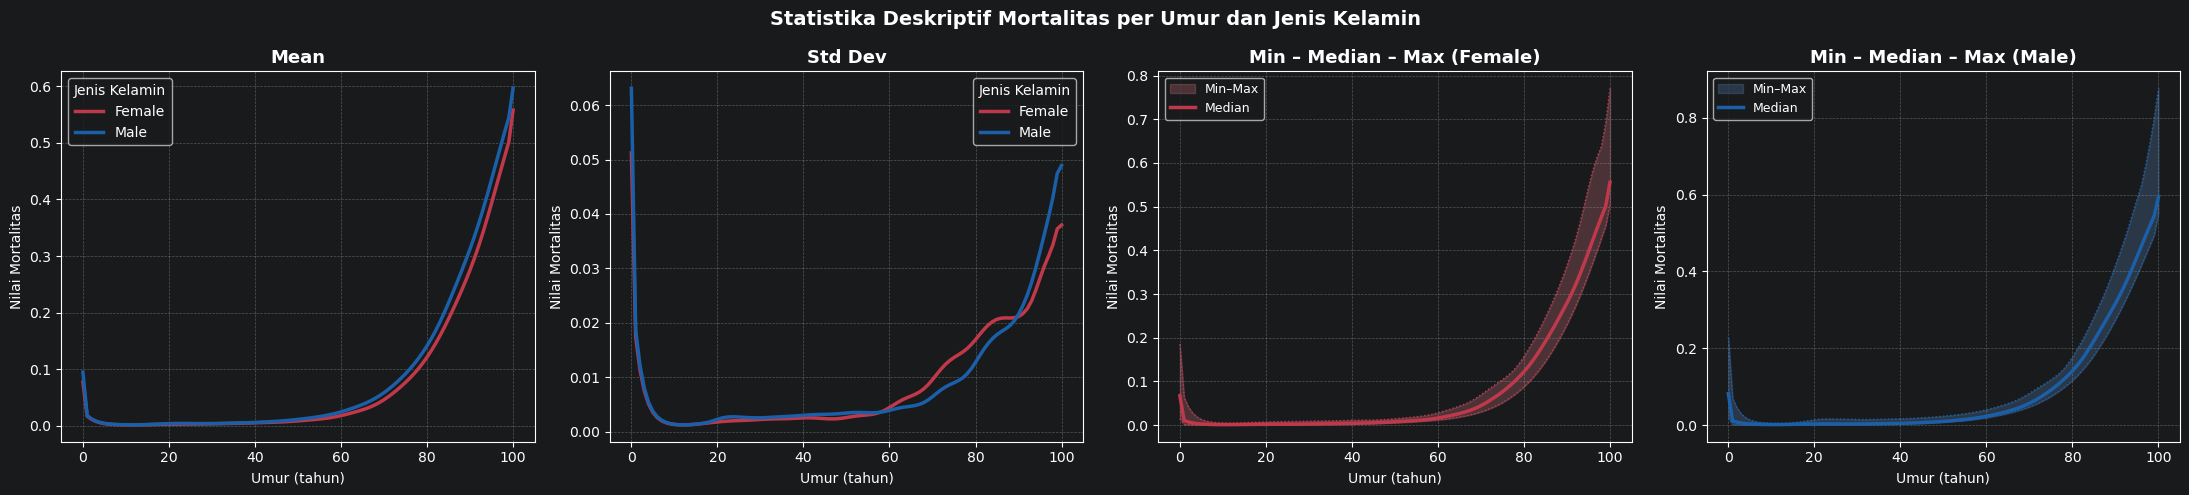

In [17]:
from ta_module.utils import plot_mortalitas_statdesc

mortalitas_statdesc_df = pd.read_csv(DOT_ENV.results_dir / "mortalitas_statdesc.csv")
plot_mortalitas_statdesc(df=mortalitas_statdesc_df, plots_dir=DOT_ENV.plots_dir)

In [18]:
populasi_df.head()

,gender,age,value
0,Male,45,2013106
1,Male,46,1965078
2,Male,47,1918556
3,Male,48,1880902
4,Male,49,1836713


In [19]:
populasi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   gender  32 non-null     str  
 1   age     32 non-null     int64
 2   value   32 non-null     int64
dtypes: int64(2), str(1)
memory usage: 900.0 bytes


In [20]:
bi_rate_df.head()

,date,bi_rate
0,2024-12-18,0.0600
1,2024-11-20,0.0600
2,2024-10-16,0.0600
3,2024-09-18,0.0600
4,2024-08-21,0.0625


In [21]:
bi_rate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     60 non-null     datetime64[us]
 1   bi_rate  60 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.1 KB


## Histogram mortalitas

In [22]:
import torch
import numpy as np

# Male mortalitas
mortalitas_df_male = mortalitas_df[mortalitas_df[GENDER_COL] == "Male"]
M_male = mortalitas_df_male.pivot(
    index=YEAR_COL,
    columns=AGE_COL,
    values=MORTALITY_COL
)
M_male = torch.from_numpy(M_male.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

# Female mortalitas
mortalitas_df_female = mortalitas_df[mortalitas_df[GENDER_COL] == "Female"]
M_female = mortalitas_df_female.pivot(
    index=YEAR_COL,
    columns=AGE_COL,
    values=MORTALITY_COL
)
M_female = torch.from_numpy(M_female.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

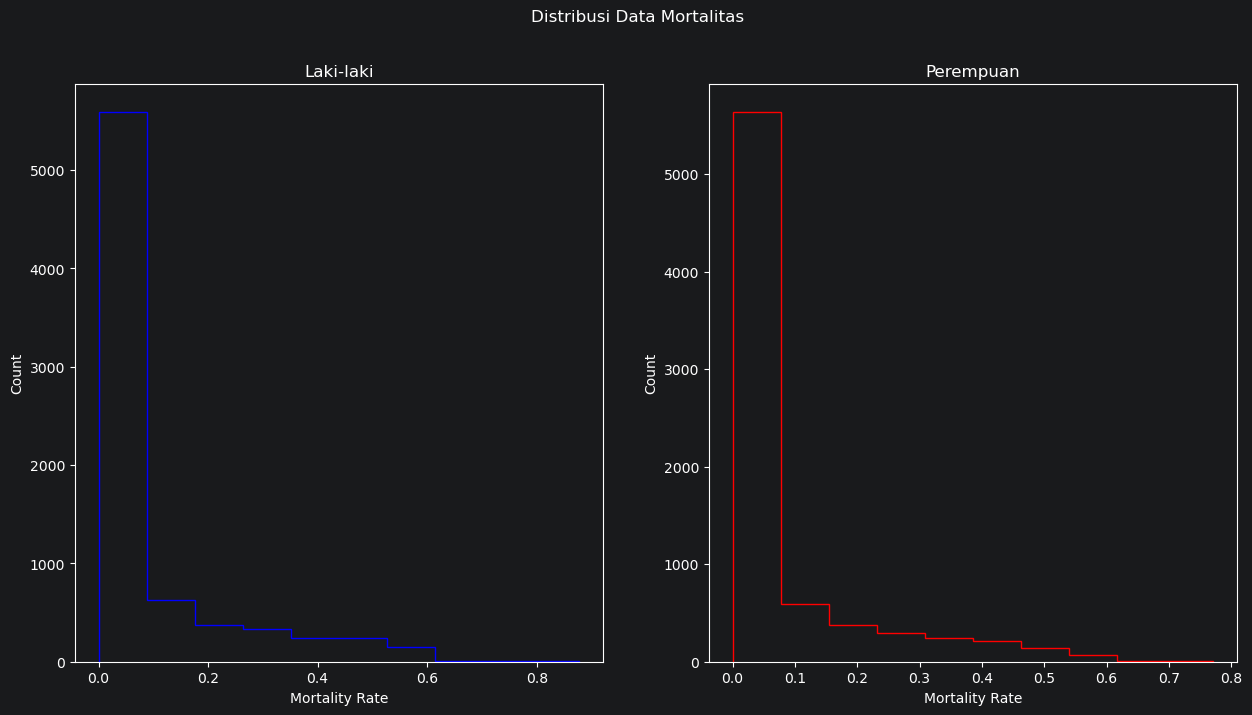

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].hist(M_male.cpu().numpy().reshape(-1), color="blue", histtype="step")
ax[0].set_title("Laki-laki")
ax[0].set_xlabel("Mortality Rate")
ax[0].set_ylabel("Count")

ax[1].hist(M_female.cpu().numpy().reshape(-1), color="red", histtype="step")
ax[1].set_title("Perempuan")
ax[1].set_xlabel("Mortality Rate")
ax[1].set_ylabel("Count")

fig.suptitle("Distribusi Data Mortalitas")
fig.savefig(DOT_ENV.plots_dir / "distribusi_data_mortalitas.png")
plt.show()

## Plot mortalitas satu usia untuk semua tahun

In [24]:
import seaborn as sns

sns.set_theme(style="whitegrid")

In [25]:
plots_dir = DOT_ENV.plots_dir

In [26]:
from ta_module.utils import plot_usia_vs_tahun


def wrapper_plot_usia_vs_tahun(age_start: int, age_end: int, factor: int):
    plot_usia_vs_tahun(
        mortalitas_df=mortalitas_df,
        age_col=AGE_COL,
        year_col=YEAR_COL,
        gender_col=GENDER_COL,
        mortality_col=MORTALITY_COL,
        start_age=age_start,
        end_age=age_end,
        factor=factor,
        plots_dir=plots_dir
    )

Plot usia vs tahun (0-100) saved to plots\usia vs tahun (0-100).png


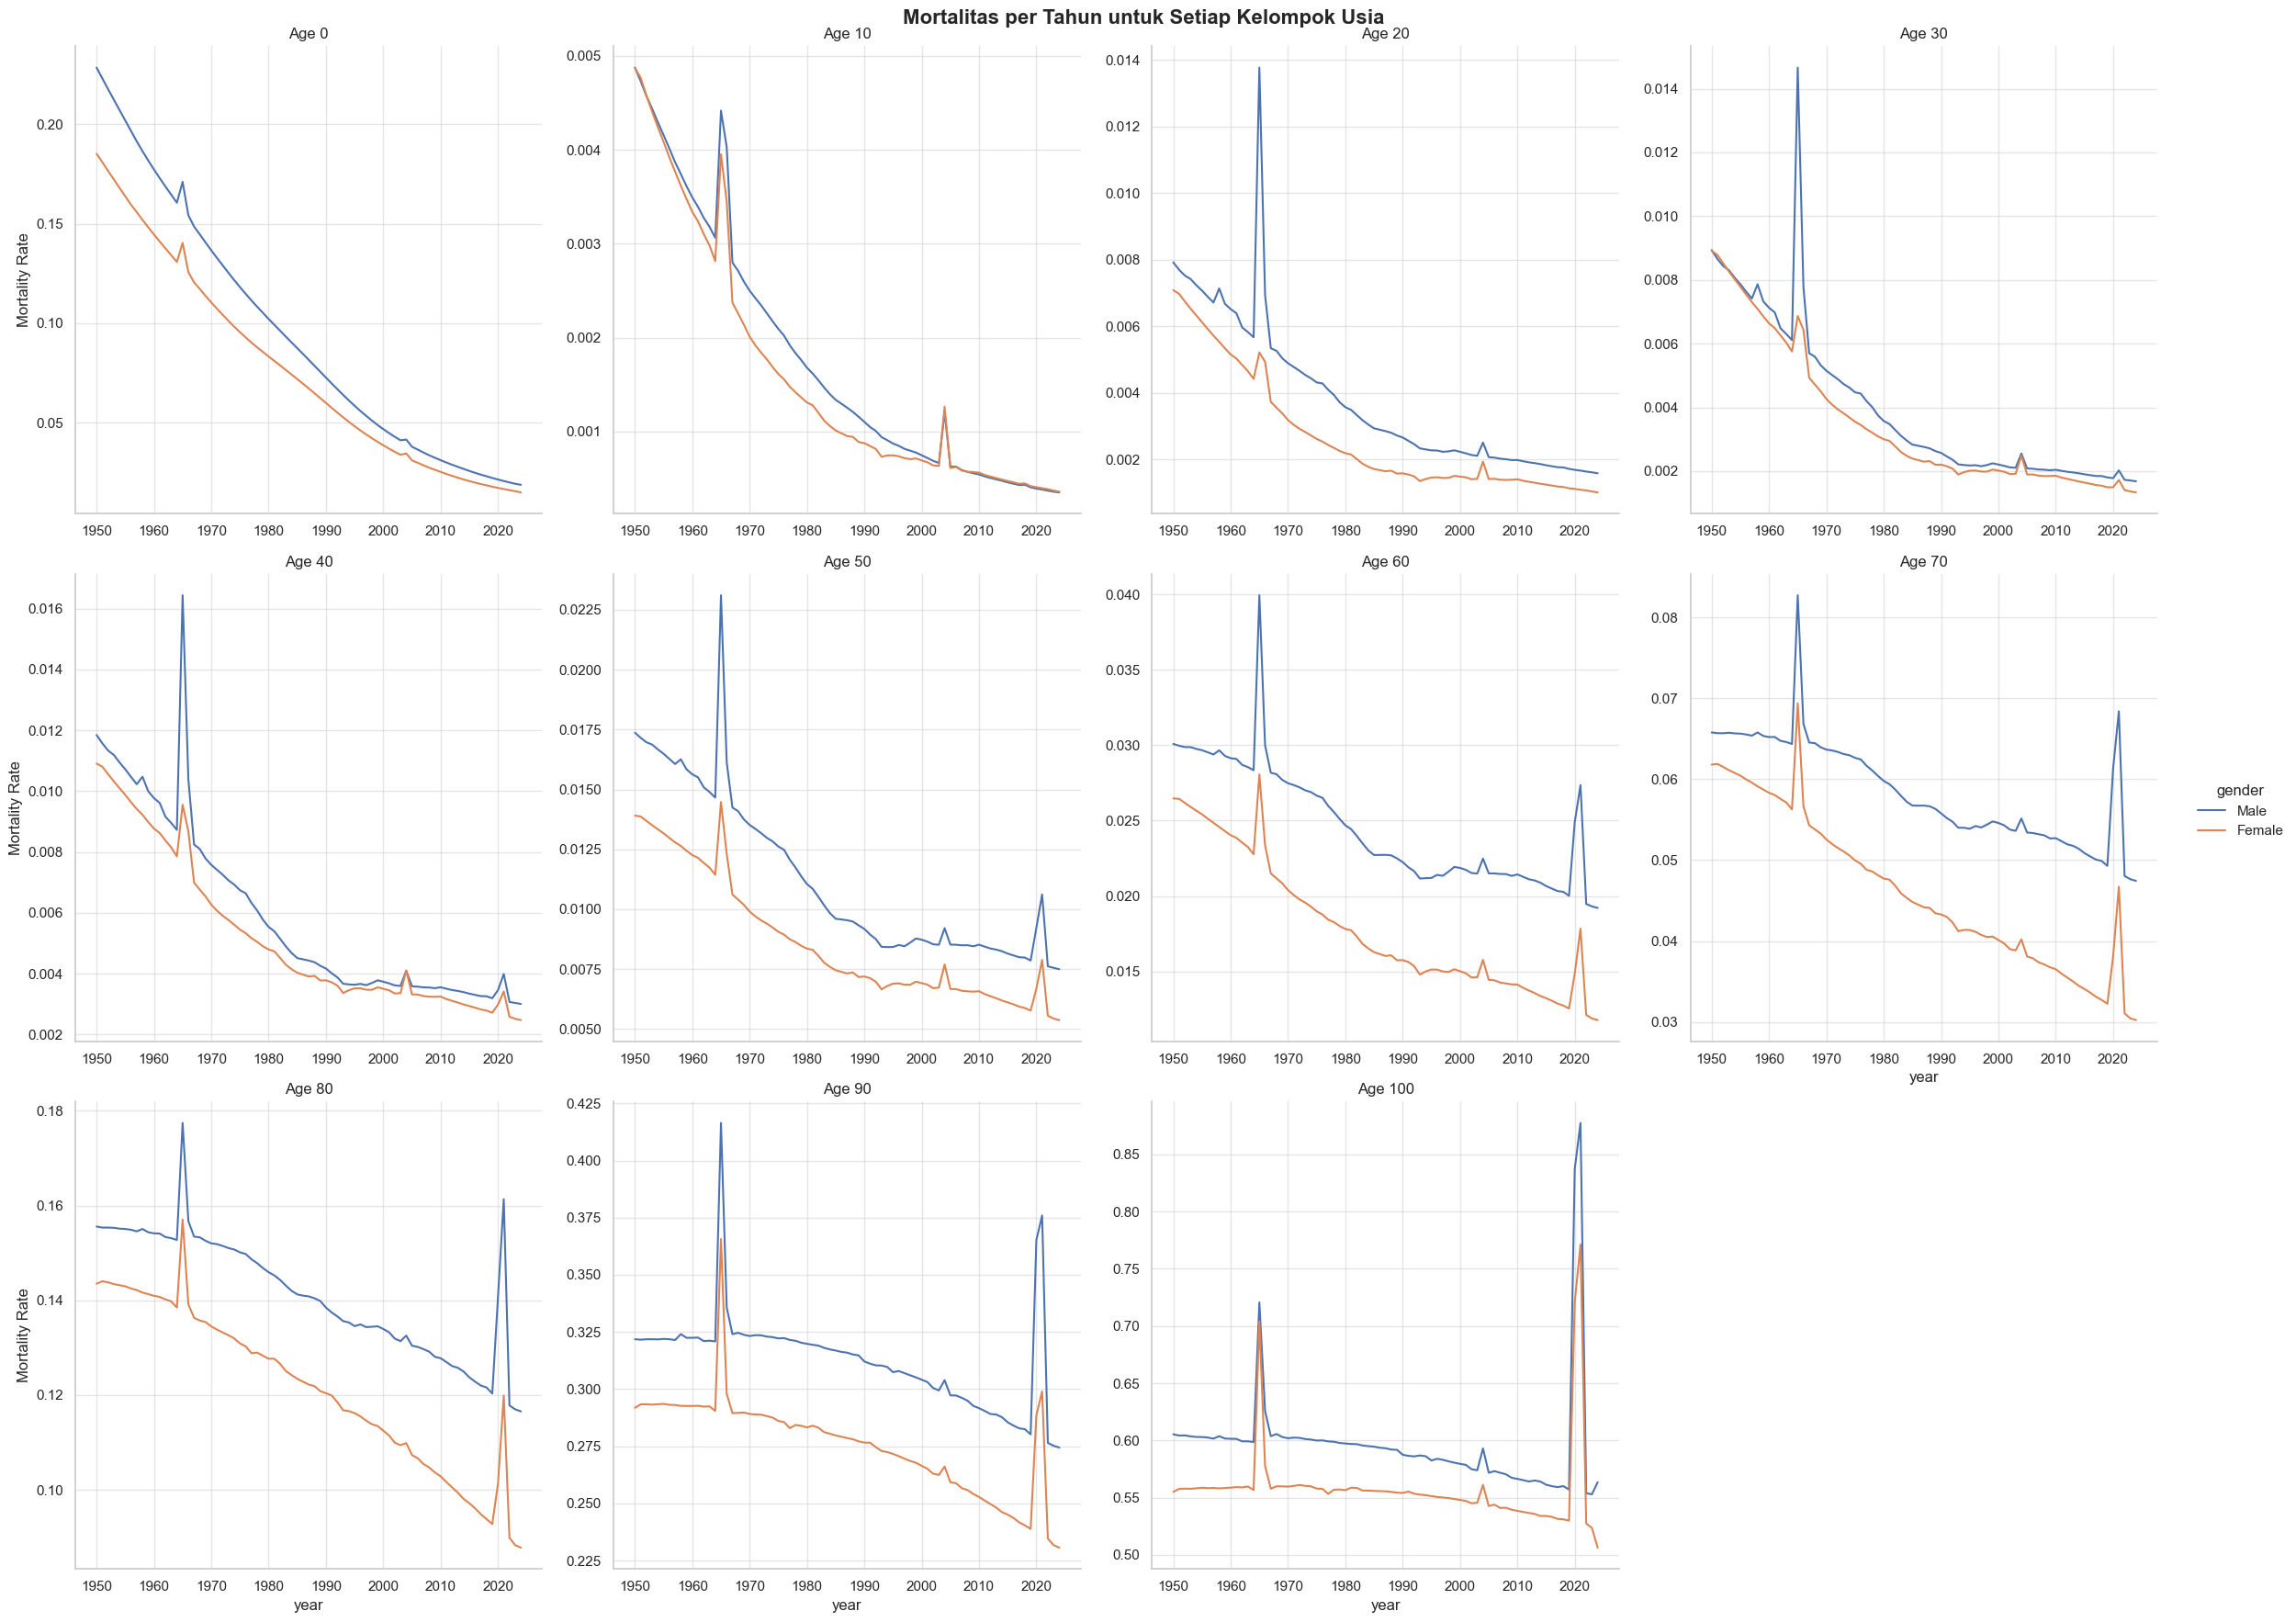

In [27]:
wrapper_plot_usia_vs_tahun(AGE_MIN, AGE_MAX, 10)

## Plot mortalitas semua usia untuk satu tahun

In [28]:
from ta_module.utils import plot_tahun_vs_usia


def wrapper_plot_tahun_vs_usia(year_start: str, year_end: str, factor: int):
    plot_tahun_vs_usia(
        mortalitas_df=mortalitas_df,
        age_col=AGE_COL,
        year_col=YEAR_COL,
        gender_col=GENDER_COL,
        mortality_col=MORTALITY_COL,
        start_year=year_start,
        end_year=year_end,
        factor=factor,
        plots_dir=plots_dir
    )

Plot tahun vs usia (1950-2024) saved to plots\tahun vs usia (1950-2024).png


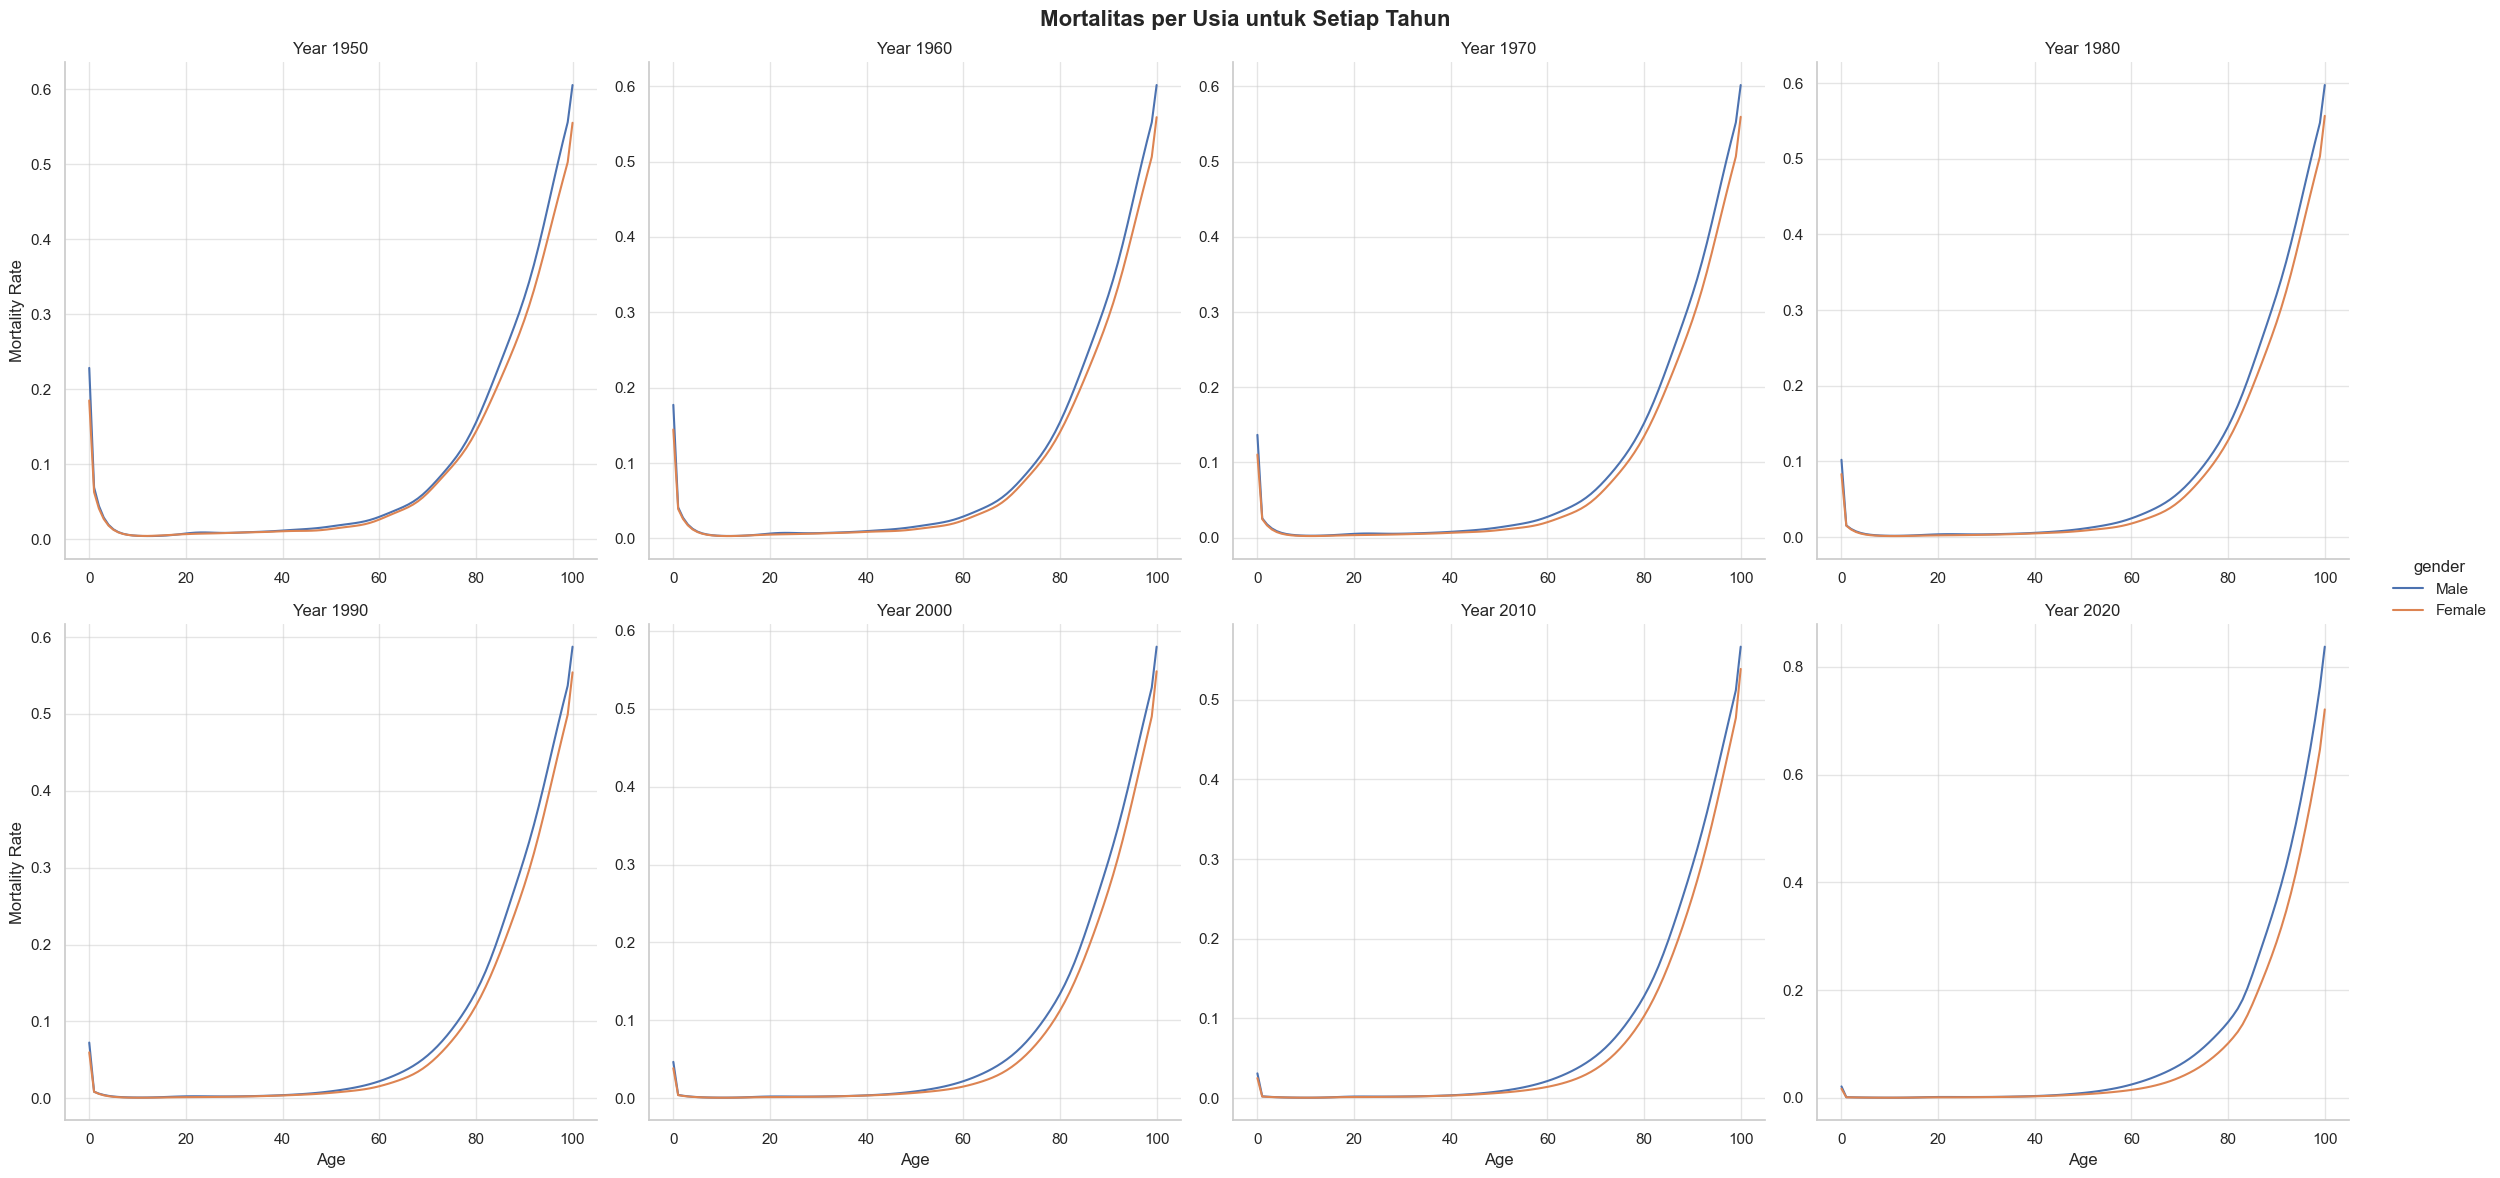

In [29]:
wrapper_plot_tahun_vs_usia(str(YEAR_MIN), str(YEAR_MAX), 10)

# Persiapan data mortalitas untuk pelatihan model

In [30]:
TRAINING_CONFIG = CONFIG.training

## Transformasi data

In [31]:
from ta_module.utils import ScaledLogitTransform

# Dari persamaan asumsi UDD qx = 2mx / (2 + mx)
# 0 <= 1x <= 1
# Jadi constraint untuk mx adalah:
lower_bound = 0.0
upper_bound = 2.0

transform_fn = ScaledLogitTransform(lb=lower_bound, ub=upper_bound)

transformed_M_male = transform_fn(M_male)
transformed_M_female = transform_fn(M_female)

## Pembagian data

In [32]:
from ta_module.data import get_train_val_test_split

train_split = CONFIG.split.train
val_split = CONFIG.split.validation
test_split = CONFIG.split.test

M_male_train, M_male_val, M_male_test = get_train_val_test_split(
    mortality_matrix=transformed_M_male,
    train_split=train_split,
    val_split=val_split,
    test_split=test_split
)

M_female_train, M_female_val, M_female_test = get_train_val_test_split(
    mortality_matrix=transformed_M_female,
    train_split=train_split,
    val_split=val_split,
    test_split=test_split
)

In [33]:
lookback = CONFIG.dataset.lookback
horizon = CONFIG.dataset.horizon

# Tambahkan konteks dari data train ke data val dan test agar sesuai dengan kebutuhan lookback
M_male_val_extend = torch.cat([M_male_train[-lookback:, :], M_male_val], dim=0)
M_male_test_extend = torch.cat([M_male_val_extend[-lookback:, :], M_male_test], dim=0)
M_female_val_extend = torch.cat([M_female_train[-lookback:, :], M_female_val], dim=0)
M_female_test_extend = torch.cat([M_female_val_extend[-lookback:, :], M_female_test], dim=0)

## Normalisasi

### Laki-laki

In [34]:
import torch

train_male_mean = M_male_train.mean(dim=0)
train_male_std = M_male_train.std(dim=0)

pd.DataFrame({"mean": train_male_mean.cpu().numpy(), "std": train_male_std.cpu().numpy()}).to_csv(
    DOT_ENV.results_dir / "train_male_mean_std.csv", sep=";", decimal=","
)

In [35]:
from ta_module.data import NormalizedMortalityDataset

create_male_dataset_split = NormalizedMortalityDataset.factory(
    lookback=lookback,
    horizon=horizon,
    mean=train_male_mean,
    std=train_male_std,
)

train_male_dataset = create_male_dataset_split(M_male_train)
val_male_dataset = create_male_dataset_split(M_male_val_extend)
test_male_dataset = create_male_dataset_split(M_male_test_extend)

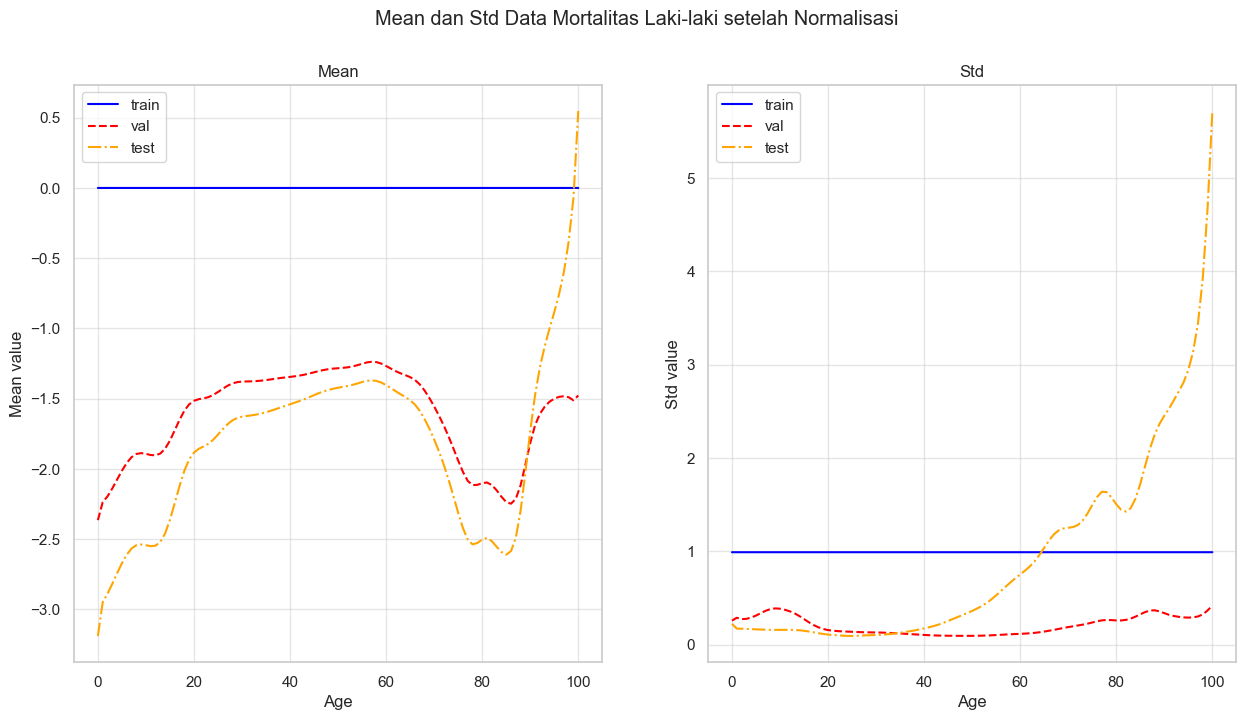

In [36]:
import matplotlib.pyplot as plt
from ta_module.utils import normalize

male_train_normalized = normalize(M_male_train, train_male_mean, train_male_std).cpu().numpy()
male_val_normalized = normalize(M_male_val, train_male_mean, train_male_std).cpu().numpy()
male_test_normalized = normalize(M_male_test, train_male_mean, train_male_std).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].plot(male_train_normalized.mean(axis=0), color="blue", linestyle="-", label="train")
ax[0].plot(male_val_normalized.mean(axis=0), color="red", linestyle="--", label="val")
ax[0].plot(male_test_normalized.mean(axis=0), color="orange", linestyle="-.", label="test")
ax[0].set_title("Mean")
ax[0].legend()
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Mean value")

ax[1].plot(male_train_normalized.std(axis=0), color="blue", linestyle="-", label="train")
ax[1].plot(male_val_normalized.std(axis=0), color="red", linestyle="--", label="val")
ax[1].plot(male_test_normalized.std(axis=0), color="orange", linestyle="-.", label="test")
ax[1].set_title("Std")
ax[1].legend()
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Std value")

fig.suptitle("Mean dan Std Data Mortalitas Laki-laki setelah Normalisasi")
fig.savefig(DOT_ENV.plots_dir / "mean_std_mortalitas_laki-laki_setelah_normalisasi.png")
plt.show()

### Perempuan

In [37]:
train_female_mean = M_female_train.mean(dim=0)
train_female_std = M_female_train.std(dim=0)

pd.DataFrame({"mean": train_female_mean.cpu().numpy(), "std": train_female_std.cpu().numpy()}).to_csv(
    DOT_ENV.results_dir / "train_female_mean_std.csv", sep=";", decimal=","
)

In [38]:
create_female_dataset_split = NormalizedMortalityDataset.factory(
    lookback=lookback,
    horizon=horizon,
    mean=train_female_mean,
    std=train_female_std,
)

train_female_dataset = create_female_dataset_split(M_female_train)
val_female_dataset = create_female_dataset_split(M_female_val_extend)
test_female_dataset = create_female_dataset_split(M_female_test_extend)

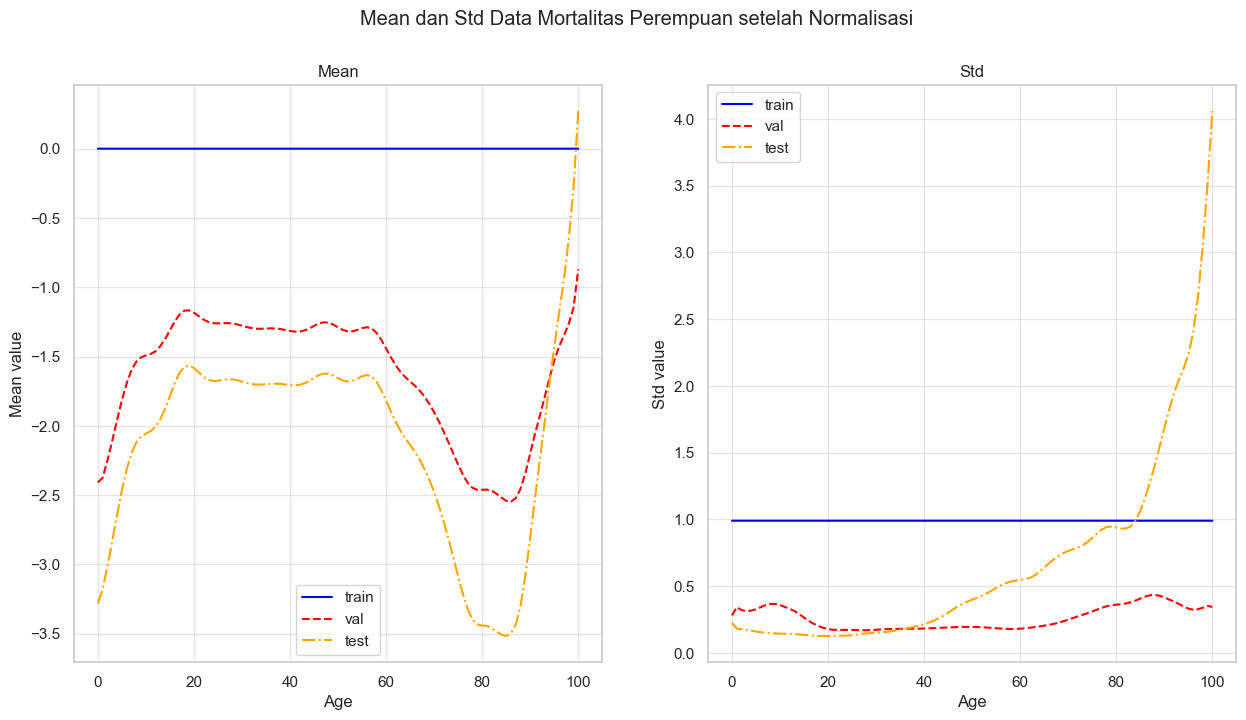

In [39]:
female_train_normalized = normalize(M_female_train, train_female_mean, train_female_std).cpu().numpy()
female_val_normalized = normalize(M_female_val, train_female_mean, train_female_std).cpu().numpy()
female_test_normalized = normalize(M_female_test, train_female_mean, train_female_std).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].plot(female_train_normalized.mean(axis=0), color="blue", linestyle="-", label="train")
ax[0].plot(female_val_normalized.mean(axis=0), color="red", linestyle="--", label="val")
ax[0].plot(female_test_normalized.mean(axis=0), color="orange", linestyle="-.", label="test")
ax[0].set_title("Mean")
ax[0].legend()
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Mean value")

ax[1].plot(female_train_normalized.std(axis=0), color="blue", linestyle="-", label="train")
ax[1].plot(female_val_normalized.std(axis=0), color="red", linestyle="--", label="val")
ax[1].plot(female_test_normalized.std(axis=0), color="orange", linestyle="-.", label="test")
ax[1].set_title("Std")
ax[1].legend()
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Std value")

fig.suptitle("Mean dan Std Data Mortalitas Perempuan setelah Normalisasi")
fig.savefig(DOT_ENV.plots_dir / "mean_std_mortalitas_perempuan_setelah_normalisasi.png")
plt.show()

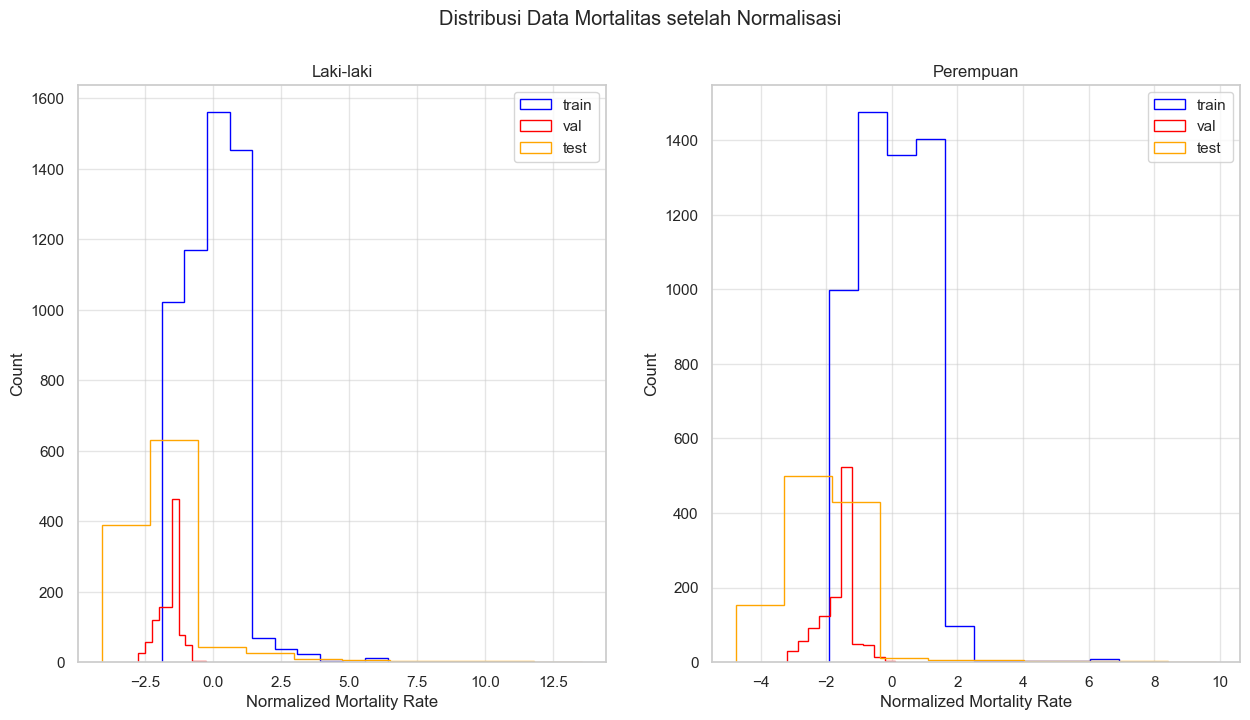

In [40]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].hist(male_train_normalized.reshape(-1), color="blue", histtype="step", label="train")
ax[0].hist(male_val_normalized.reshape(-1), color="red", histtype="step", label="val")
ax[0].hist(male_test_normalized.reshape(-1), color="orange", histtype="step", label="test")
ax[0].legend()
ax[0].set_title("Laki-laki")
ax[0].set_xlabel("Normalized Mortality Rate")
ax[0].set_ylabel("Count")

ax[1].hist(female_train_normalized.reshape(-1), color="blue", histtype="step", label="train")
ax[1].hist(female_val_normalized.reshape(-1), color="red", histtype="step", label="val")
ax[1].hist(female_test_normalized.reshape(-1), color="orange", histtype="step", label="test")
ax[1].legend()
ax[1].set_title("Perempuan")
ax[1].set_xlabel("Normalized Mortality Rate")
ax[1].set_ylabel("Count")

fig.suptitle("Distribusi Data Mortalitas setelah Normalisasi")
fig.savefig(DOT_ENV.plots_dir / "distribusi_data_mortalitas_setelah_normalisasi.png")
plt.show()

## Penggabungan data mortalitas laki-laki dan perempuan untuk pelatihan

In [41]:
from torch.utils.data import ConcatDataset

train_dataset = ConcatDataset([train_male_dataset, train_female_dataset])
val_dataset = ConcatDataset([val_male_dataset, val_female_dataset])

In [42]:
from torch.utils.data import DataLoader

batch_size = TRAINING_CONFIG.batch_size

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=len(val_male_dataset), shuffle=False)

In [43]:
for batch in val_dataloader:
    x, y = batch

# Pelatihan model

### Plot learning rate

Plot disimpan ke: lr_schedule.png


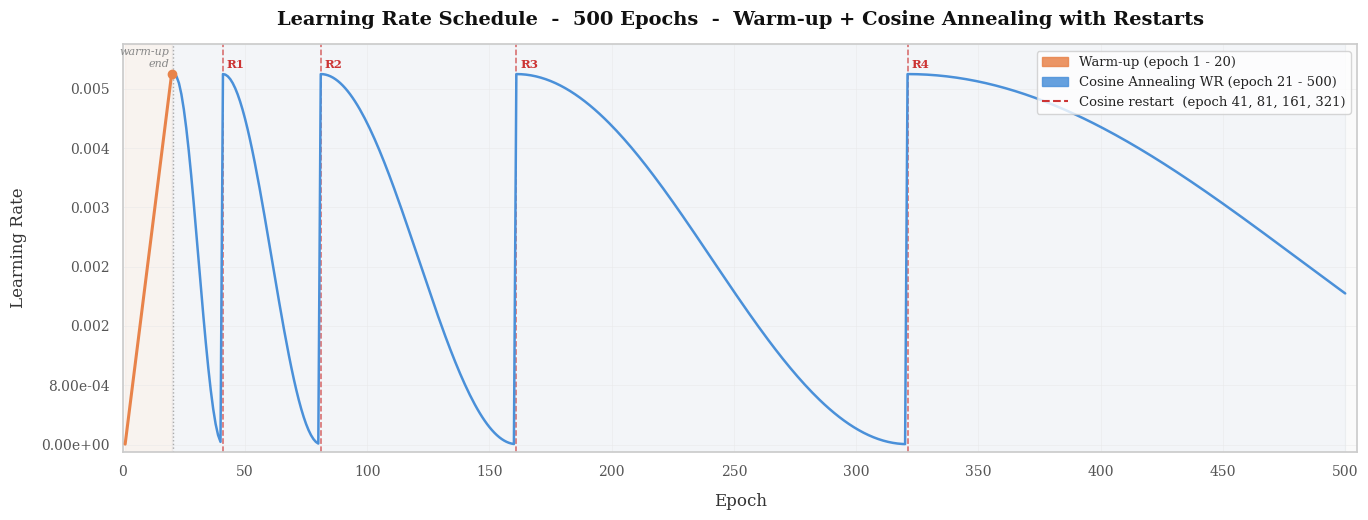

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

# Load data
df = pd.read_excel(DOT_ENV.results_dir / "learning_rate_schedule_500_epochs.xlsx", decimal=",")
df.columns = ["epoch", "lr", "phase", ""]

warmup = df[df["phase"] == "Warm-up"]
cosine = df[df["phase"] == "Cosine Annealing WR"]

# Deteksi restart: puncak lokal di cosine annealing dengan LR > 4.98e-3
cosine_vals = cosine["lr"].values
cosine_eps = cosine["epoch"].values
restart_epochs = [
    cosine_eps[i]
    for i in range(1, len(cosine_vals) - 1)
    if cosine_vals[i] >= cosine_vals[i - 1]
       and cosine_vals[i] >= cosine_vals[i + 1]
       and cosine_vals[i] > 4.98e-3
]

warmup_end = warmup["epoch"].max()  # epoch 20

# Styling
sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update(
    {
        "axes.facecolor"  : "#FAFAFA",
        "figure.facecolor": "#FFFFFF",
        "grid.color"      : "#E8E8E8",
        "grid.linewidth"  : 0.7,
        "axes.edgecolor"  : "#CCCCCC",
        "axes.labelcolor" : "#333333",
        "xtick.color"     : "#555555",
        "ytick.color"     : "#555555",
        "xtick.labelsize" : 10,
        "ytick.labelsize" : 10,
        "axes.labelsize"  : 12,
        "text.color"      : "#222222",
        "font.family"     : "serif",
    }
)

WARMUP_COLOR = "#E8834A"  # oranye hangat
COSINE_COLOR = "#4A90D9"  # biru
RESTART_COLOR = "#CC3333"  # merah tua

fig, ax = plt.subplots(figsize=(14, 5.5))

# Shading background per fase
ax.axvspan(
    warmup["epoch"].min(), warmup_end,
    color=WARMUP_COLOR, alpha=0.06, zorder=0
)
ax.axvspan(
    warmup_end, cosine["epoch"].max(),
    color=COSINE_COLOR, alpha=0.04, zorder=0
)

# Plot garis LR
ax.plot(
    warmup["epoch"], warmup["lr"],
    color=WARMUP_COLOR, linewidth=2.2, zorder=3,
    solid_capstyle="round"
)

ax.plot(
    cosine["epoch"], cosine["lr"],
    color=COSINE_COLOR, linewidth=1.8, zorder=3,
    solid_capstyle="round"
)

# Titik sambung warm-up cosine
ax.plot(
    warmup_end, warmup[warmup["epoch"] == warmup_end]["lr"].values[0],
    "o", color=WARMUP_COLOR, markersize=6, zorder=5
)

# Garis vertikal restart
for i, ep in enumerate(restart_epochs):
    lr_at_restart = cosine[cosine["epoch"] == ep]["lr"].values[0]
    ax.axvline(
        ep, color=RESTART_COLOR, linewidth=1.1,
        linestyle="--", alpha=0.75, zorder=2
    )
    # Label "R1", "R2", ... di atas garis
    ax.text(
        ep + 1.5, lr_at_restart * 1.01,
        f"R{i + 1}", fontsize=8.5, color=RESTART_COLOR,
        fontweight="bold", va="bottom"
        )

# Annotation warm-up end
ax.axvline(
    warmup_end + 0.5, color="#AAAAAA", linewidth=1.0,
    linestyle=":", zorder=2
    )
ax.text(
    warmup_end - 1, 5e-3 * 1.015, "warm-up\nend",
    ha="right", fontsize=8, color="#888888", style="italic", va="bottom"
    )

# Estetika sumbu
ax.set_title(
    "Learning Rate Schedule  -  500 Epochs  -  Warm-up + Cosine Annealing with Restarts",
    fontsize=14, fontweight="bold", color="#111111",
    pad=14, loc="center",
)
ax.set_xlabel("Epoch", labelpad=10)
ax.set_ylabel("Learning Rate", labelpad=10)

ax.set_xlim(0, df["epoch"].max() + 5)
y_max = df["lr"].max()
ax.set_ylim(-0.0001, y_max * 1.08)

ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8, prune="both"))
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{x:.3f}" if x >= 0.001 else f"{x:.2e}"
    )
)
ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(10))

# Legenda
handles = [
    mpatches.Patch(color=WARMUP_COLOR, alpha=0.85, label="Warm-up (epoch 1 - 20)"),
    mpatches.Patch(color=COSINE_COLOR, alpha=0.85, label="Cosine Annealing WR (epoch 21 - 500)"),
    Line2D(
        [0], [0], color=RESTART_COLOR, linewidth=1.5,
        linestyle="--", label=f"Cosine restart  (epoch {', '.join(map(str, restart_epochs))})"
    ),
]
leg = ax.legend(
    handles=handles,
    loc="upper right",
    fontsize=9.5,
    framealpha=0.8,
    facecolor="#FFFFFF",
    edgecolor="#CCCCCC",
    handlelength=2.0,
)
for text in leg.get_texts():
    text.set_color("#222222")

plt.tight_layout(pad=1.5)
fig.savefig(
    DOT_ENV.plots_dir / "lr_schedule.png", dpi=150, bbox_inches="tight",
    facecolor=fig.get_facecolor()
    )

print("Plot disimpan ke: lr_schedule.png")
plt.show()

## Definisi arsitektur model

In [45]:
MODEL_CONFIG = CONFIG.model

### LCN

In [46]:
from torch import nn
from ta_module.models import LocalGLMnet, LocallyConnected2D

ukuran_matriks_input = (lookback, AGE_MAX - AGE_MIN + 1)
lcn_activation_function = nn.Sigmoid()
LCN_CONFIG = MODEL_CONFIG.lcn

create_lcn_layer = LocallyConnected2D.factory(
    input_size=ukuran_matriks_input,
    activation_fn=lcn_activation_function,
    kernel_size=LCN_CONFIG.kernel_size,
    zero_padding=LCN_CONFIG.zero_padding,
    bias=LCN_CONFIG.bias,
)

### LocalGLMnet

In [47]:
from ta_module.utils import IdentityTransform

link_fn = IdentityTransform()

LOCALGLMNET_CONFIG = MODEL_CONFIG.localglmnet
create_localglmnet_model = LocalGLMnet.factory(
    input_size=ukuran_matriks_input,
    link_fn=link_fn,
    bias=LOCALGLMNET_CONFIG.bias,
)

## Definisi metode pelatihan model

In [48]:
TRAINING_CONFIG = CONFIG.training

### Loss function dan metrik evaluasi

In [49]:
import torch.nn.functional as F

loss_metric_fn = F.mse_loss
eval_metric_fn = F.l1_loss

### Optimizer dan lr scheduler

In [50]:
from typing import Iterator
from torch.optim import NAdam

OPTIMIZER_CONFIG = TRAINING_CONFIG.optimizer


def create_optimizer(params: Iterator[nn.Parameter]):
    return NAdam(
        params=params,
        lr=OPTIMIZER_CONFIG.lr,
    )

In [51]:
from torch.optim import Optimizer
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingWarmRestarts, SequentialLR

LR_SCHEDULER_CONFIG = TRAINING_CONFIG.lr_scheduler


def create_lr_scheduler(optimizer: Optimizer):
    warm_up_epochs = LR_SCHEDULER_CONFIG.total_iters
    warm_up_scheduler = LinearLR(
        optimizer=optimizer,
        start_factor=LR_SCHEDULER_CONFIG.start_factor,
        end_factor=LR_SCHEDULER_CONFIG.end_factor,
        total_iters=warm_up_epochs
    )

    sgdr_scheduler = CosineAnnealingWarmRestarts(
        optimizer=optimizer,
        T_0=LR_SCHEDULER_CONFIG.T_0,
        T_mult=LR_SCHEDULER_CONFIG.T_mult,
        eta_min=LR_SCHEDULER_CONFIG.eta_min
    )

    return SequentialLR(
        optimizer=optimizer,
        schedulers=[warm_up_scheduler, sgdr_scheduler],
        milestones=[warm_up_epochs]
    )

## Grid search untuk hyperparameter koefisien regularisasi LASSO

In [52]:
TUNING_CONFIG = CONFIG.tuning

### Proses grid search

In [53]:
from optuna.trial import Trial
from typing import Callable, Iterator
from torch.nn import Parameter

from ta_module.tuning import reg_coef_grid_search, reg_coef_objective
from ta_module.config import TuneMetadata, ModeEnum
from ta_module.utils import get_current_run_datetime, ElasticNetRegularizationTerm
from ta_module.models import LocalGLMnetLightning

if CONFIG.mode == ModeEnum.TUNE:
    max_epochs = TRAINING_CONFIG.max_epochs
    min_epochs = TRAINING_CONFIG.min_epochs
    reg_coef_candidates = TUNING_CONFIG.reg_coef_candidates


    def create_mymodel_with_reg_coef(
        reg_coef: float
    ):
        def _create_regularization_term(model_weights_getter: Callable[[], Iterator[Parameter]]):
            return ElasticNetRegularizationTerm(
                reg_coef=reg_coef,
                alpha=TRAINING_CONFIG.regularization.alpha,
                model_weights_getter=model_weights_getter,
            )

        localglmnet = create_localglmnet_model(create_lcn_layer())
        localglmnet_attention_weights_getter = lambda: (
            params for name, params in
            localglmnet.regression_attention_model.named_parameters()
            if "bias" not in name
        )

        return LocalGLMnetLightning(
            model=localglmnet,
            loss_metric=loss_metric_fn,
            eval_metric=eval_metric_fn,
            create_optimizer=create_optimizer,
            create_lr_scheduler=create_lr_scheduler,
            regularization_term=_create_regularization_term(model_weights_getter=localglmnet_attention_weights_getter),
        )

    objective: Callable[[Trial], float] = lambda trial: (
        reg_coef_objective(
            trial=trial,
            create_my_model_with_reg_coef=create_mymodel_with_reg_coef,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            max_epochs=max_epochs,
            min_epochs=min_epochs,
            log_dir=DOT_ENV.tuning_logs_dir,
            checkpoint_dir=DOT_ENV.tuning_checkpoints_dir,
            reg_coef_candidates=reg_coef_candidates,
            gradient_clip_val=TRAINING_CONFIG.regularization.gradient_clip_val,
            seed=CONFIG.seed
        )
    )

    run_datetime = get_current_run_datetime()
    print(f"==================================================================")
    print("Mulai grid search untuk hyperparameter reg_coef dalam lasso loss")
    print(f"Run datetime: {run_datetime}")
    print(f"reg_coef candidates: {reg_coef_candidates}")
    print(f"==================================================================\n")
    grid_search_result = reg_coef_grid_search(
        objective_fn=objective,
        reg_coef_candidates=reg_coef_candidates,
        storage=DOT_ENV.optuna_db_url,
        seed=CONFIG.seed,
    )
    print(f"\n==================================================================\n")
    print("Grid_search selesai!")
    print(f"Result:\n{grid_search_result}\n")

    last_tune_metadata_filepath = DOT_ENV.last_tune_metadata_file
    print(f"Update file {last_tune_metadata_filepath}:")
    tune_metadata: TuneMetadata = TuneMetadata.model_validate(
        {
            "datetime": run_datetime,
            "result"  : grid_search_result,
        }
    )
    print(f"Tune metadata:\n{tune_metadata}\n")
    with open(last_tune_metadata_filepath, "w") as f:
        f.write(tune_metadata.model_dump_json(indent=4))
    print(f"Update berhasil!")
else:
    print(f"Mode = {CONFIG.mode}")
    print("Skip proses tuning")

Mode = inference
Skip proses tuning


### Plot metrik dan learning rate tuning

Plot disimpan!


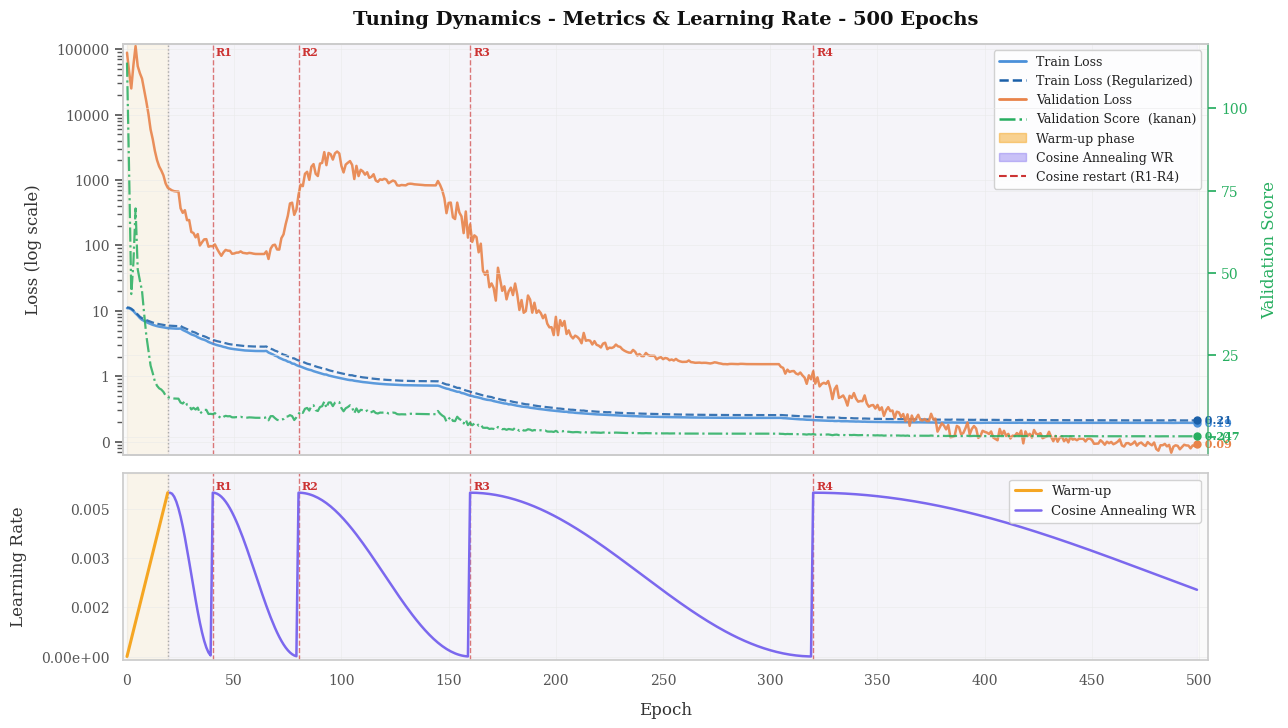

In [54]:
"""
------------------------
2-panel plot:
  (atas) train_loss, train_loss_regularized, val_loss (kiri)
         val_score (kanan, dual y-axis)
  (bawah) learning rate schedule
Garis vertikal restart cosine annealing tembus ke kedua panel.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

# Load data
metrics = pd.read_csv(
    DOT_ENV.tuning_logs_dir / "tune_reg_coef_elasticnet_regularization/Trial_2_reg_coef_5e_04/2026-05-17_22-14-19" / "metrics.csv"
)

train_df = (metrics.dropna(subset=["train_loss_epoch"])
            [["epoch", "train_loss_epoch"]].reset_index(drop=True))
train_reg = (metrics.dropna(subset=["train_loss_regularized_epoch"])
             [["epoch", "train_loss_regularized_epoch"]].reset_index(drop=True))
val_df = (metrics.dropna(subset=["val_loss"])
          [["epoch", "val_loss"]].reset_index(drop=True))
score_df = (metrics.dropna(subset=["val_score"])
            [["epoch", "val_score"]].reset_index(drop=True))

lr_df = pd.read_excel(
    DOT_ENV.results_dir / "learning_rate_schedule_500_epochs.xlsx",
    sheet_name="LR_Schedule_500",
    usecols=["Epoch", "Learning Rate", "Phase"],
)

lr_df.columns = ["epoch", "lr", "phase"]
lr_df["epoch"] = lr_df["epoch"] - 1

warmup = lr_df[lr_df["phase"] == "Warm-up"]
cosine = lr_df[lr_df["phase"] == "Cosine Annealing WR"]

# Deteksi restart
cosine_vals = cosine["lr"].values
cosine_eps = cosine["epoch"].values
restart_epochs = [
    cosine_eps[i]
    for i in range(1, len(cosine_vals) - 1)
    if cosine_vals[i] >= cosine_vals[i - 1]
       and cosine_vals[i] >= cosine_vals[i + 1]
       and cosine_vals[i] > 4.98e-3
]
warmup_end = warmup["epoch"].max()

# Styling
sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update(
    {
        "axes.facecolor"  : "#FAFAFA",
        "figure.facecolor": "#FFFFFF",
        "grid.color"      : "#E8E8E8",
        "grid.linewidth"  : 0.7,
        "axes.edgecolor"  : "#CCCCCC",
        "axes.labelcolor" : "#333333",
        "xtick.color"     : "#555555",
        "ytick.color"     : "#555555",
        "xtick.labelsize" : 10,
        "ytick.labelsize" : 10,
        "axes.labelsize"  : 12,
        "text.color"      : "#222222",
        "font.family"     : "serif",
    }
)

TRAIN_COLOR = "#4A90D9"  # biru
TRAIN_REG_COLOR = "#1A5FA8"  # biru tua
VAL_COLOR = "#E8834A"  # oranye
SCORE_COLOR = "#27AE60"  # hijau (sumbu kanan)
WARMUP_COLOR = "#F5A623"
COSINE_COLOR = "#7B68EE"
RESTART_COLOR = "#CC3333"

# Figure: 2 panel, shared x
fig, (ax_loss, ax_lr) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.06},
)

# Dual y-axis untuk panel atas
ax_score = ax_loss.twinx()

# PANEL ATAS Loss (kiri) + Val Score (kanan)

# Shading fase
ax_loss.axvspan(
    warmup["epoch"].min(), warmup_end,
    color=WARMUP_COLOR, alpha=0.07, zorder=0
)
ax_loss.axvspan(
    warmup_end, cosine["epoch"].max(),
    color=COSINE_COLOR, alpha=0.04, zorder=0
)

# Garis restart & warm-up end
for ep in restart_epochs:
    ax_loss.axvline(
        ep, color=RESTART_COLOR, linewidth=1.0,
        linestyle="--", alpha=0.65, zorder=2
    )
ax_loss.axvline(
    warmup_end, color="#AAAAAA", linewidth=1.0,
    linestyle=":", zorder=2
)

# Sumbu kiri: 3 garis loss
ax_loss.plot(
    train_df["epoch"], train_df["train_loss_epoch"],
    color=TRAIN_COLOR, linewidth=1.8, zorder=3, alpha=0.9,
    label="Train Loss"
)
ax_loss.plot(
    train_reg["epoch"], train_reg["train_loss_regularized_epoch"],
    color=TRAIN_REG_COLOR, linewidth=1.6, zorder=3, alpha=0.85,
    linestyle="--", label="Train Loss (Regularized)"
)
ax_loss.plot(
    val_df["epoch"], val_df["val_loss"],
    color=VAL_COLOR, linewidth=1.8, zorder=3, alpha=0.9,
    label="Validation Loss"
)

# Log scale sumbu kiri
all_loss = np.concatenate(
    [
        train_df["train_loss_epoch"].values,
        train_reg["train_loss_regularized_epoch"].values,
        val_df["val_loss"].values,
    ]
)
ax_loss.set_yscale("log")
ax_loss.set_ylim(all_loss.min() * 0.92, all_loss.max() * 1.08)
ax_loss.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=8))
ax_loss.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax_loss.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_loss.set_ylabel("Loss (log scale)", labelpad=10, color="#333333")

# Sumbu kanan: val_score
ax_score.plot(
    score_df["epoch"], score_df["val_score"],
    color=SCORE_COLOR, linewidth=1.6, zorder=3, alpha=0.85,
    linestyle="-.", label="Validation Score"
)

s_min, s_max = score_df["val_score"].min(), score_df["val_score"].max()
s_pad = (s_max - s_min) * 0.05
ax_score.set_ylim(s_min - s_pad, s_max + s_pad)
ax_score.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune="both"))
ax_score.set_ylabel("Validation Score", labelpad=10, color=SCORE_COLOR)
ax_score.tick_params(axis="y", colors=SCORE_COLOR, labelsize=10)
ax_score.spines["right"].set_edgecolor(SCORE_COLOR)
ax_score.spines["right"].set_alpha(0.6)

# Label nilai akhir
for ax_, arr, ep_col, col, fmt in [
    (ax_loss, train_df["train_loss_epoch"].values, train_df["epoch"], TRAIN_COLOR, ".2f"),
    (ax_loss, train_reg["train_loss_regularized_epoch"].values, train_reg["epoch"], TRAIN_REG_COLOR, ".2f"),
    (ax_loss, val_df["val_loss"].values, val_df["epoch"], VAL_COLOR, ".2f"),
    (ax_score, score_df["val_score"].values, score_df["epoch"], SCORE_COLOR, ".3f"),
]:
    last_ep = ep_col.iloc[-1]
    last_val = arr[-1]
    ax_.plot(last_ep, last_val, "o", color=col, markersize=5, zorder=6)
    ax_.annotate(
        f"  {last_val:{fmt}}", xy=(last_ep, last_val),
        fontsize=8, color=col, va="center", fontweight="bold"
    )

# Annotasi restart
for i, ep in enumerate(restart_epochs):
    ax_loss.text(
        ep + 1.5, all_loss.max() * 0.97,
        f"R{i + 1}", fontsize=8, color=RESTART_COLOR,
        fontweight="bold", va="top", zorder=6
        )

ax_loss.set_title(
    "Tuning Dynamics - Metrics & Learning Rate - 500 Epochs",
    fontsize=14, fontweight="bold", color="#111111", pad=14, loc="center",
)

# Legenda gabungan (kiri + kanan)
loss_handles = [
    Line2D(
        [0], [0], color=TRAIN_COLOR, linewidth=2.0,
        label="Train Loss"
    ),
    Line2D(
        [0], [0], color=TRAIN_REG_COLOR, linewidth=1.8,
        linestyle="--", label="Train Loss (Regularized)"
    ),
    Line2D(
        [0], [0], color=VAL_COLOR, linewidth=2.0,
        label="Validation Loss"
    ),
    Line2D(
        [0], [0], color=SCORE_COLOR, linewidth=1.8,
        linestyle="-.", label="Validation Score  (kanan)"
    ),
    mpatches.Patch(color=WARMUP_COLOR, alpha=0.5, label="Warm-up phase"),
    mpatches.Patch(color=COSINE_COLOR, alpha=0.4, label="Cosine Annealing WR"),
    Line2D(
        [0], [0], color=RESTART_COLOR, linewidth=1.5,
        linestyle="--", label=f"Cosine restart (R1-R{len(restart_epochs)})"
    ),
]

leg = ax_loss.legend(
    handles=loss_handles, loc="upper right",
    fontsize=9.0, framealpha=0.88,
    facecolor="#FFFFFF", edgecolor="#CCCCCC",
    handlelength=2.2
)
for t in leg.get_texts():
    t.set_color("#222222")

# PANEL BAWAH Learning Rate

ax_lr.axvspan(
    warmup["epoch"].min(), warmup_end,
    color=WARMUP_COLOR, alpha=0.07, zorder=0
)
ax_lr.axvspan(
    warmup_end, cosine["epoch"].max(),
    color=COSINE_COLOR, alpha=0.04, zorder=0
)

for i, ep in enumerate(restart_epochs):
    lr_val = cosine[cosine["epoch"] == ep]["lr"].values[0]
    ax_lr.axvline(
        ep, color=RESTART_COLOR, linewidth=1.0,
        linestyle="--", alpha=0.65, zorder=2
    )
    ax_lr.text(
        ep + 1.5, lr_val * 1.01, f"R{i + 1}",
        fontsize=8, color=RESTART_COLOR, fontweight="bold",
        va="bottom", zorder=6
        )

ax_lr.axvline(
    warmup_end, color="#AAAAAA", linewidth=1.0,
    linestyle=":", zorder=2
)

ax_lr.plot(
    warmup["epoch"], warmup["lr"],
    color=WARMUP_COLOR, linewidth=2.2, zorder=3, solid_capstyle="round"
)
ax_lr.plot(
    cosine["epoch"], cosine["lr"],
    color=COSINE_COLOR, linewidth=1.8, zorder=3, solid_capstyle="round"
)

ax_lr.set_xlabel("Epoch", labelpad=10)
ax_lr.set_ylabel("Learning Rate", labelpad=10)

ax_lr.set_xlim(-2, lr_df["epoch"].max() + 5)
lr_y_max = lr_df["lr"].max()
ax_lr.set_ylim(-0.0001, lr_y_max * 1.12)
ax_lr.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, prune="both"))
ax_lr.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{x:.3f}" if x >= 0.001 else f"{x:.2e}"
    )
)
ax_lr.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax_lr.xaxis.set_minor_locator(mticker.MultipleLocator(10))

lr_handles = [
    Line2D([0], [0], color=WARMUP_COLOR, linewidth=2.2, label="Warm-up"),
    Line2D([0], [0], color=COSINE_COLOR, linewidth=1.8, label="Cosine Annealing WR"),
]
leg2 = ax_lr.legend(
    handles=lr_handles, loc="upper right",
    fontsize=9.5, framealpha=0.85,
    facecolor="#FFFFFF", edgecolor="#CCCCCC",
    handlelength=2.0
)

for t in leg2.get_texts():
    t.set_color("#222222")

plt.savefig(
    DOT_ENV.plots_dir / "tuning_metrics_vs_learning_rate.png", dpi=150, bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

print("Plot disimpan!")
plt.show()

## Pelatihan model dengan hyperparameter terbaik

### Load hyperparameter terbaik dari tune metadata

In [55]:
from ta_module.config import load_last_tune_metadata

last_tune_metadata = load_last_tune_metadata(DOT_ENV.last_tune_metadata_file)
print(f"Last tune metadata:\n{last_tune_metadata}")

Last tune metadata:
datetime=datetime.datetime(2026, 5, 17, 22, 8, 23, 65576, tzinfo=TzInfo(25200)) result=TuningResult(study_name='reg_coef_grid_search_2026-05-17_22-08-23', trials={'number': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'value': [0.12368039786815643, 0.09233341366052628, 0.06759503483772278, 0.10547361522912979, 0.12858672440052032, 0.08680722862482071, 0.10960392653942108, 0.7548892498016357, 0.24644070863723755, 0.10582030564546585], 'datetime_start': ['2026-05-17T15:08:24.122727', '2026-05-17T15:11:40.318399', '2026-05-17T15:14:19.268033', '2026-05-17T15:16:49.210324', '2026-05-17T15:19:20.131872', '2026-05-17T15:21:48.010370', '2026-05-17T15:24:14.355370', '2026-05-17T15:26:39.191708', '2026-05-17T15:29:02.240405', '2026-05-17T15:31:25.077531'], 'datetime_complete': ['2026-05-17T15:11:40.250231', '2026-05-17T15:14:19.203017', '2026-05-17T15:16:49.140447', '2026-05-17T15:19:20.090002', '2026-05-17T15:21:47.969962', '2026-05-17T15:24:14.315183', '2026-05-17T15:26:39.145030', '20

In [56]:
tune_trials_result = pd.DataFrame(last_tune_metadata.result.trials)
tune_trials_result.to_csv(DOT_ENV.results_dir / "tune_trials_result.csv", sep=";", decimal=",")

In [57]:
best_reg_coef = last_tune_metadata.result.best_params.get("reg_coef", None)
create_elasticnet_regularization = ElasticNetRegularizationTerm.factory(
    reg_coef=best_reg_coef,
    alpha=TRAINING_CONFIG.regularization.alpha,
)

### Proses pelatihan

In [58]:
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger
from lightning import Trainer

from ta_module.config import TrainMetadata
from ta_module.models import LocalGLMnetLightning
from ta_module.utils import get_current_run_datetime_str

if CONFIG.mode in [ModeEnum.TRAIN, ModeEnum.TUNE]:
    num_ensembles = MODEL_CONFIG.num_ensembles
    run_datetime = get_current_run_datetime()
    run_datetime_str = get_current_run_datetime_str()
    checkpoint_dirs = []

    # Train ensembles pada data mortalitas laki-laki dan perempuan
    print(f"Melatih {num_ensembles} model LocalGLMnet secara independen")
    print(f"Run datetime: {run_datetime_str}")
    for i in range(num_ensembles):
        # Random seed direset tiap model dengan nilai berbeda-beda agar inisiasi acak dan independen
        seed_everything(seed=CONFIG.seed * i + i, workers=True)

        localglmnet_model = create_localglmnet_model(create_lcn_layer())

        attention_weight_getter = lambda: (
            params for name, params in localglmnet_model.regression_attention_model.named_parameters() if
                 "bias" not in name
        )

        lightning_module = LocalGLMnetLightning(
            model=localglmnet_model,
            loss_metric=loss_metric_fn,
            eval_metric=eval_metric_fn,
            regularization_term=create_elasticnet_regularization(attention_weight_getter),
            create_optimizer=create_optimizer,
            create_lr_scheduler=create_lr_scheduler
        )

        max_epochs = TRAINING_CONFIG.max_epochs
        min_epochs = TRAINING_CONFIG.min_epochs
        model_name = f"LocalGLMnet_{i + 1}"
        checkpoint_dir = DOT_ENV.training_checkpoints_dir / model_name
        checkpoint_dirs.append(checkpoint_dir)

        trainer = Trainer(
            max_epochs=max_epochs,
            min_epochs=min_epochs,
            log_every_n_steps=1,
            deterministic=True,
            gradient_clip_val=TRAINING_CONFIG.regularization.gradient_clip_val,
            logger=[
                TensorBoardLogger(
                    save_dir=DOT_ENV.training_logs_dir,
                    name=model_name,
                    version=run_datetime_str
                ),
                CSVLogger(
                    save_dir=DOT_ENV.training_logs_dir,
                    name=model_name,
                    version=run_datetime_str,
                )
            ],
            callbacks=[
                ModelCheckpoint(
                    dirpath=checkpoint_dir,
                    filename=run_datetime_str,
                    monitor="val_loss",
                    mode="min",
                    save_top_k=1
                )
            ]
        )

        print("\n================================================================")
        print(f"Training model {i + 1} pada mortalitas laki-laki dan perempuan:")
        print("================================================================\n")
        trainer.fit(
            model=lightning_module,
            train_dataloaders=train_dataloader,
            val_dataloaders=val_dataloader,
        )

    print("Pelatihan selesai!")

    # Save metadadata
    last_train_metadata_filepath = DOT_ENV.last_train_metadata_file
    checkpoint_file_paths = [checkpoint_dirs[i] / f"{run_datetime_str}.ckpt" for i in range(num_ensembles)]
    print(f"Update file {last_train_metadata_filepath}:")
    # metadata digunakan untuk load checkpoint model terakhir secara otomatis
    # jika tidak run proses pelatihan
    train_metadata = TrainMetadata.model_validate(
        {
            "datetime"             : run_datetime,
            "checkpoint_file_paths": checkpoint_file_paths,
        }, extra="forbid"
    )
    print(f"Train metadata:\n{train_metadata}\n")
    with open(last_train_metadata_filepath, "w") as f:
        f.write(train_metadata.model_dump_json(indent=4))
    print("Update berhasil!")
else:
    print(f"Mode = {CONFIG.mode}")
    print("Skip proses pelatihan, langsung inference")

Mode = inference
Skip proses pelatihan, langsung inference


### Plot metrik dan learning rate training

Plot disimpan!


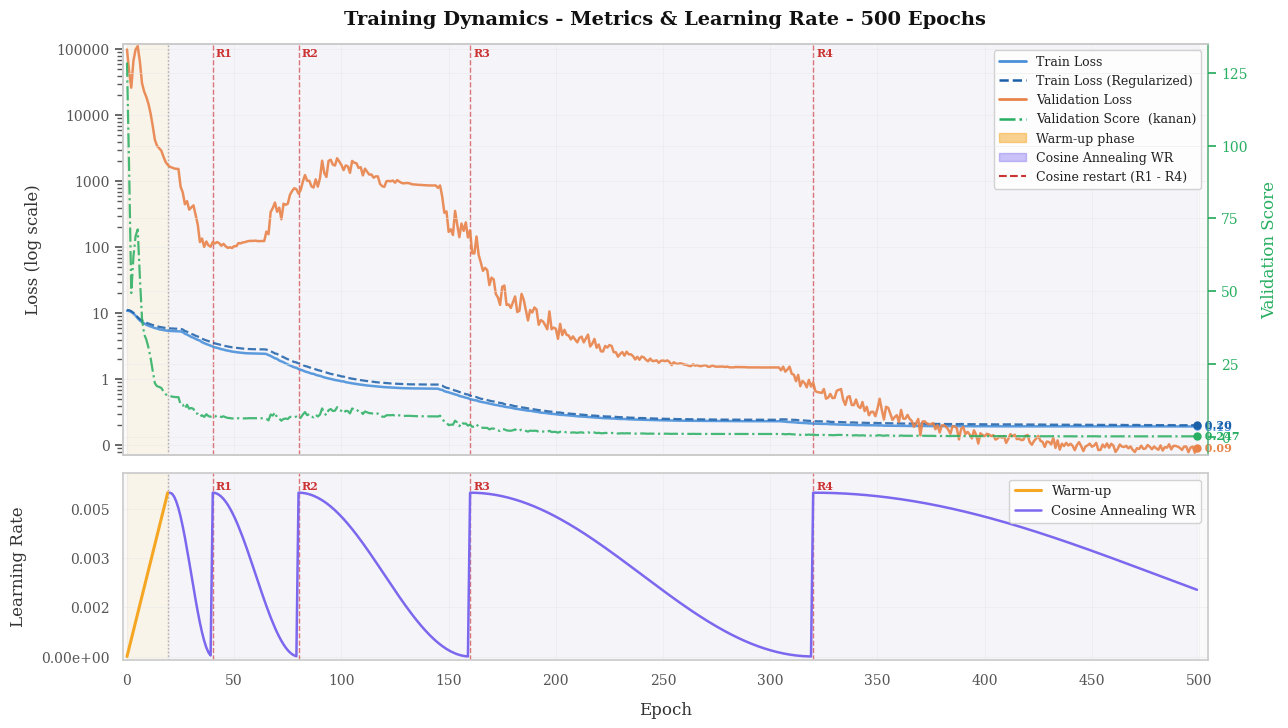

In [59]:
"""
------------------------
2-panel plot:
  (atas) train_loss, train_loss_regularized, val_loss (kiri)
         val_score (kanan, dual y-axis)
  (bawah) learning rate schedule
Garis vertikal restart cosine annealing tembus ke kedua panel.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

# Load data
metrics = pd.read_csv(DOT_ENV.training_logs_dir / "LocalGLMnet_10/2026-05-17_23-07-20" / "metrics.csv")

train_df = (metrics.dropna(subset=["train_loss_epoch"])
            [["epoch", "train_loss_epoch"]].reset_index(drop=True))
train_reg = (metrics.dropna(subset=["train_loss_regularized_epoch"])
             [["epoch", "train_loss_regularized_epoch"]].reset_index(drop=True))
val_df = (metrics.dropna(subset=["val_loss"])
          [["epoch", "val_loss"]].reset_index(drop=True))
score_df = (metrics.dropna(subset=["val_score"])
            [["epoch", "val_score"]].reset_index(drop=True))

lr_df = pd.read_excel(
    DOT_ENV.results_dir / "learning_rate_schedule_500_epochs.xlsx",
    sheet_name="LR_Schedule_500",
    usecols=["Epoch", "Learning Rate", "Phase"],
)
lr_df.columns = ["epoch", "lr", "phase"]
lr_df["epoch"] = lr_df["epoch"] - 1

warmup = lr_df[lr_df["phase"] == "Warm-up"]
cosine = lr_df[lr_df["phase"] == "Cosine Annealing WR"]

# Deteksi restart
cosine_vals = cosine["lr"].values
cosine_eps = cosine["epoch"].values
restart_epochs = [
    cosine_eps[i]
    for i in range(1, len(cosine_vals) - 1)
    if cosine_vals[i] >= cosine_vals[i - 1]
       and cosine_vals[i] >= cosine_vals[i + 1]
       and cosine_vals[i] > 4.98e-3
]
warmup_end = warmup["epoch"].max()

# Styling
sns.set_theme(style="whitegrid", font="serif")
plt.rcParams.update(
    {
        "axes.facecolor"  : "#FAFAFA",
        "figure.facecolor": "#FFFFFF",
        "grid.color"      : "#E8E8E8",
        "grid.linewidth"  : 0.7,
        "axes.edgecolor"  : "#CCCCCC",
        "axes.labelcolor" : "#333333",
        "xtick.color"     : "#555555",
        "ytick.color"     : "#555555",
        "xtick.labelsize" : 10,
        "ytick.labelsize" : 10,
        "axes.labelsize"  : 12,
        "text.color"      : "#222222",
        "font.family"     : "serif",
    }
)

TRAIN_COLOR = "#4A90D9"  # biru
TRAIN_REG_COLOR = "#1A5FA8"  # biru tua
VAL_COLOR = "#E8834A"  # oranye
SCORE_COLOR = "#27AE60"  # hijau (sumbu kanan)
WARMUP_COLOR = "#F5A623"
COSINE_COLOR = "#7B68EE"
RESTART_COLOR = "#CC3333"

# Figure: 2 panel, shared x
fig, (ax_loss, ax_lr) = plt.subplots(
    2, 1,
    figsize=(14, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1], "hspace": 0.06},
)

# Dual y-axis untuk panel atas
ax_score = ax_loss.twinx()

# PANEL ATAS Loss (kiri) + Val Score (kanan)

# Shading fase
ax_loss.axvspan(
    warmup["epoch"].min(), warmup_end,
    color=WARMUP_COLOR, alpha=0.07, zorder=0
)
ax_loss.axvspan(
    warmup_end, cosine["epoch"].max(),
    color=COSINE_COLOR, alpha=0.04, zorder=0
)

# Garis restart & warm-up end
for ep in restart_epochs:
    ax_loss.axvline(
        ep, color=RESTART_COLOR, linewidth=1.0,
        linestyle="--", alpha=0.65, zorder=2
    )
ax_loss.axvline(
    warmup_end, color="#AAAAAA", linewidth=1.0,
    linestyle=":", zorder=2
)

# Sumbu kiri: 3 garis loss
ax_loss.plot(
    train_df["epoch"], train_df["train_loss_epoch"],
    color=TRAIN_COLOR, linewidth=1.8, zorder=3, alpha=0.9,
    label="Train Loss"
)
ax_loss.plot(
    train_reg["epoch"], train_reg["train_loss_regularized_epoch"],
    color=TRAIN_REG_COLOR, linewidth=1.6, zorder=3, alpha=0.85,
    linestyle="--", label="Train Loss (Regularized)"
)
ax_loss.plot(
    val_df["epoch"], val_df["val_loss"],
    color=VAL_COLOR, linewidth=1.8, zorder=3, alpha=0.9,
    label="Validation Loss"
)

# Log scale sumbu kiri
all_loss = np.concatenate(
    [
        train_df["train_loss_epoch"].values,
        train_reg["train_loss_regularized_epoch"].values,
        val_df["val_loss"].values,
    ]
)
ax_loss.set_yscale("log")
ax_loss.set_ylim(all_loss.min() * 0.92, all_loss.max() * 1.08)
ax_loss.yaxis.set_major_locator(mticker.LogLocator(base=10, numticks=8))
ax_loss.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax_loss.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_loss.set_ylabel("Loss (log scale)", labelpad=10, color="#333333")

# Sumbu kanan: val_score
ax_score.plot(
    score_df["epoch"], score_df["val_score"],
    color=SCORE_COLOR, linewidth=1.6, zorder=3, alpha=0.85,
    linestyle="-.", label="Validation Score"
)

s_min, s_max = score_df["val_score"].min(), score_df["val_score"].max()
s_pad = (s_max - s_min) * 0.05
ax_score.set_ylim(s_min - s_pad, s_max + s_pad)
ax_score.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6, prune="both"))
ax_score.set_ylabel("Validation Score", labelpad=10, color=SCORE_COLOR)
ax_score.tick_params(axis="y", colors=SCORE_COLOR, labelsize=10)
ax_score.spines["right"].set_edgecolor(SCORE_COLOR)
ax_score.spines["right"].set_alpha(0.6)

# Label nilai akhir
for ax_, arr, ep_col, col, fmt in [
    (ax_loss, train_df["train_loss_epoch"].values, train_df["epoch"], TRAIN_COLOR, ".2f"),
    (ax_loss, train_reg["train_loss_regularized_epoch"].values, train_reg["epoch"], TRAIN_REG_COLOR, ".2f"),
    (ax_loss, val_df["val_loss"].values, val_df["epoch"], VAL_COLOR, ".2f"),
    (ax_score, score_df["val_score"].values, score_df["epoch"], SCORE_COLOR, ".3f"),
]:
    last_ep = ep_col.iloc[-1]
    last_val = arr[-1]
    ax_.plot(last_ep, last_val, "o", color=col, markersize=5, zorder=6)
    ax_.annotate(
        f"  {last_val:{fmt}}", xy=(last_ep, last_val),
        fontsize=8, color=col, va="center", fontweight="bold"
    )

# Annotasi restart
for i, ep in enumerate(restart_epochs):
    ax_loss.text(
        ep + 1.5, all_loss.max() * 0.97,
        f"R{i + 1}", fontsize=8, color=RESTART_COLOR,
        fontweight="bold", va="top", zorder=6
        )

ax_loss.set_title(
    "Training Dynamics - Metrics & Learning Rate - 500 Epochs",
    fontsize=14, fontweight="bold", color="#111111", pad=14, loc="center",
)

# Legenda gabungan (kiri + kanan)
loss_handles = [
    Line2D(
        [0], [0], color=TRAIN_COLOR, linewidth=2.0,
        label="Train Loss"
    ),
    Line2D(
        [0], [0], color=TRAIN_REG_COLOR, linewidth=1.8,
        linestyle="--", label="Train Loss (Regularized)"
    ),
    Line2D(
        [0], [0], color=VAL_COLOR, linewidth=2.0,
        label="Validation Loss"
    ),
    Line2D(
        [0], [0], color=SCORE_COLOR, linewidth=1.8,
        linestyle="-.", label="Validation Score  (kanan)"
    ),
    mpatches.Patch(color=WARMUP_COLOR, alpha=0.5, label="Warm-up phase"),
    mpatches.Patch(color=COSINE_COLOR, alpha=0.4, label="Cosine Annealing WR"),
    Line2D(
        [0], [0], color=RESTART_COLOR, linewidth=1.5,
        linestyle="--", label=f"Cosine restart (R1 - R{len(restart_epochs)})"
    ),
]
leg = ax_loss.legend(
    handles=loss_handles, loc="upper right",
    fontsize=9.0, framealpha=0.88,
    facecolor="#FFFFFF", edgecolor="#CCCCCC",
    handlelength=2.2
)
for t in leg.get_texts():
    t.set_color("#222222")

# PANEL BAWAH Learning Rate

ax_lr.axvspan(
    warmup["epoch"].min(), warmup_end,
    color=WARMUP_COLOR, alpha=0.07, zorder=0
)
ax_lr.axvspan(
    warmup_end, cosine["epoch"].max(),
    color=COSINE_COLOR, alpha=0.04, zorder=0
)

for i, ep in enumerate(restart_epochs):
    lr_val = cosine[cosine["epoch"] == ep]["lr"].values[0]
    ax_lr.axvline(
        ep, color=RESTART_COLOR, linewidth=1.0,
        linestyle="--", alpha=0.65, zorder=2
    )
    ax_lr.text(
        ep + 1.5, lr_val * 1.01, f"R{i + 1}",
        fontsize=8, color=RESTART_COLOR, fontweight="bold",
        va="bottom", zorder=6
        )

ax_lr.axvline(
    warmup_end, color="#AAAAAA", linewidth=1.0,
    linestyle=":", zorder=2
)

ax_lr.plot(
    warmup["epoch"], warmup["lr"],
    color=WARMUP_COLOR, linewidth=2.2, zorder=3, solid_capstyle="round"
)
ax_lr.plot(
    cosine["epoch"], cosine["lr"],
    color=COSINE_COLOR, linewidth=1.8, zorder=3, solid_capstyle="round"
)

ax_lr.set_xlabel("Epoch", labelpad=10)
ax_lr.set_ylabel("Learning Rate", labelpad=10)

ax_lr.set_xlim(-2, lr_df["epoch"].max() + 5)
lr_y_max = lr_df["lr"].max()
ax_lr.set_ylim(-0.0001, lr_y_max * 1.12)
ax_lr.yaxis.set_major_locator(mticker.MaxNLocator(nbins=5, prune="both"))
ax_lr.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{x:.3f}" if x >= 0.001 else f"{x:.2e}"
    )
)
ax_lr.xaxis.set_major_locator(mticker.MultipleLocator(50))
ax_lr.xaxis.set_minor_locator(mticker.MultipleLocator(10))

lr_handles = [
    Line2D([0], [0], color=WARMUP_COLOR, linewidth=2.2, label="Warm-up"),
    Line2D([0], [0], color=COSINE_COLOR, linewidth=1.8, label="Cosine Annealing WR"),
]
leg2 = ax_lr.legend(
    handles=lr_handles, loc="upper right",
    fontsize=9.5, framealpha=0.85,
    facecolor="#FFFFFF", edgecolor="#CCCCCC",
    handlelength=2.0
)
for t in leg2.get_texts():
    t.set_color("#222222")

plt.savefig(
    DOT_ENV.plots_dir / "training_metrics_vs_learning_rate.png", dpi=150, bbox_inches="tight",
    facecolor=fig.get_facecolor()
    )

print("Plot disimpan!")
plt.show()

# Evaluasi model LocalGLMnet

## Load model yang sudah dilatih

In [60]:
from ta_module.config import load_last_train_metadata

last_train_metadata = load_last_train_metadata(DOT_ENV.last_train_metadata_file)

In [61]:
last_train_metadata

TrainMetadata(datetime=datetime.datetime(2026, 5, 17, 23, 7, 20, 917625, tzinfo=TzInfo(25200)), checkpoint_file_paths=[WindowsPath('checkpoints/training/LocalGLMnet_1/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_2/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_3/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_4/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_5/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_6/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_7/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_8/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_9/2026-05-17_23-07-20.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_10/2026-05-17_23-07-20.ckpt')])

In [62]:
localglmnet_models = []
for checkpoint_filepath in last_train_metadata.checkpoint_file_paths:
    localglmnet_model = create_localglmnet_model(create_lcn_layer())
    ckpt = torch.load(checkpoint_filepath, map_location=DEVICE)
    state_dict = ckpt["state_dict"]

    # sesuaikan dengan nama atribut di LightningModule-mu
    prefix = "model."
    state_dict = {
        k[len(prefix):]: v
        for k, v in state_dict.items()
        if k.startswith(prefix)
    }

    localglmnet_model.load_state_dict(state_dict)
    localglmnet_model.eval()
    localglmnet_models.append(localglmnet_model)

print(localglmnet_models)

[LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (ac

In [63]:
from ta_module.models import EnsembleLocalGLMNet

localglmnet_ensemble = EnsembleLocalGLMNet(
    models=localglmnet_models,
).to(DEVICE)

print(localglmnet_ensemble)

EnsembleLocalGLMNet(
  (models): ModuleList(
    (0-9): 10 x LocalGLMnet(
      (regression_attention_model): LocallyConnected2D(
        (activation_fn): Sigmoid()
      )
    )
  )
)


## Evaluasi performa

In [64]:
from torch import Tensor
from ta_module.utils import denormalize


def inverse_transform_mortality(x: Tensor, mean: Tensor, std: Tensor) -> Tensor:
    denormalized = denormalize(x, mean, std)
    detransformed = transform_fn.inv(denormalized)

    return detransformed


def inverse_transform_male_mortality(x: Tensor) -> Tensor:
    return inverse_transform_mortality(x, train_male_mean, train_male_std)


def inverse_transform_female_mortality(x: Tensor) -> Tensor:
    return inverse_transform_mortality(x, train_female_mean, train_female_std)

In [65]:
from ta_module.utils import recursive_forecast

test_male_dataloader = DataLoader(test_male_dataset, batch_size=len(test_male_dataset), shuffle=False)
male_test_loss = 0.0
male_test_score = 0.0

for batch in test_male_dataloader:
    x, y = batch
    x = x[:1, :, :]
    h = y.shape[0]

    with torch.no_grad():
        y_pred = recursive_forecast(
            model=localglmnet_ensemble,
            x=x,
            forecast_horizon=h,
            n_sim=1
        )

    y_pred = y_pred.permute(1, 0, 2)
    y_detransformed = inverse_transform_male_mortality(y)
    y_pred_detransformed = inverse_transform_male_mortality(y_pred)

    male_test_loss = F.mse_loss(y_detransformed, y_pred_detransformed).detach()
    male_test_score = F.l1_loss(y_detransformed, y_pred_detransformed).detach()

print(f"Male test MSE = {male_test_loss:.6f}")
print(f"Male test MAE = {male_test_score:.6f}")

Male test MSE = 0.000944
Male test MAE = 0.006893


In [66]:
male_individual_test_loss = []
male_individual_test_score = []
for batch in test_male_dataloader:
    x, y = batch
    x = x[:1, :, :]
    h = y.shape[0]

    y_detransformed = inverse_transform_male_mortality(y)
    for i in range(len(localglmnet_ensemble.models)):
        model = localglmnet_ensemble.models[i]
        with torch.no_grad():
            y_pred = recursive_forecast(
                model=model,
                x=x,
                forecast_horizon=h,
                n_sim=1
            )

        y_pred = y_pred.permute(1, 0, 2)
        y_pred_detransformed = inverse_transform_male_mortality(y_pred)

        test_loss = F.mse_loss(y_detransformed, y_pred_detransformed).detach()
        test_score = F.l1_loss(y_detransformed, y_pred_detransformed).detach()

        male_individual_test_loss.append(test_loss)
        male_individual_test_score.append(test_score)

print(55 * "=")
print("Male test individu model LocalGLMnet:")
print(55 * "=")
for i in range(len(male_individual_test_loss)):
    print(f"LocalGLMnet{i+1} : MSE = {male_individual_test_loss[i]:.6f}; MAE = {male_individual_test_score[i]:.6f}")

Male test individu model LocalGLMnet:
LocalGLMnet1 : MSE = 0.000930; MAE = 0.006753
LocalGLMnet2 : MSE = 0.000921; MAE = 0.006673
LocalGLMnet3 : MSE = 0.000929; MAE = 0.006812
LocalGLMnet4 : MSE = 0.000946; MAE = 0.006904
LocalGLMnet5 : MSE = 0.000949; MAE = 0.006961
LocalGLMnet6 : MSE = 0.000942; MAE = 0.006846
LocalGLMnet7 : MSE = 0.001019; MAE = 0.007523
LocalGLMnet8 : MSE = 0.000938; MAE = 0.006827
LocalGLMnet9 : MSE = 0.000965; MAE = 0.007094
LocalGLMnet10 : MSE = 0.000919; MAE = 0.006645


In [67]:
test_female_dataloader = DataLoader(test_female_dataset, batch_size=len(test_male_dataset), shuffle=False)
female_test_loss = 0.0
female_test_score = 0.0

for batch in test_female_dataloader:
    x, y = batch
    x = x[:1, :, :]
    h = y.shape[0]
    with torch.no_grad():
        y_pred = recursive_forecast(
            model=localglmnet_ensemble,
            x=x,
            forecast_horizon=h,
            n_sim=1
        )

    y_pred = y_pred.permute(1, 0, 2)
    y_detransformed = inverse_transform_female_mortality(y)
    y_pred_detransformed = inverse_transform_female_mortality(y_pred)

    female_test_loss = F.mse_loss(y_detransformed, y_pred_detransformed).detach()
    female_test_score = F.l1_loss(y_detransformed, y_pred_detransformed).detach()

print(f"Female test MSE = {female_test_loss:.6f}")
print(f"Female test MAE = {female_test_score:.6f}")

Female test MSE = 0.000470
Female test MAE = 0.005020


In [68]:
female_individual_test_loss = []
female_individual_test_score = []
for batch in test_female_dataloader:
    x, y = batch
    x = x[:1, :, :]
    h = y.shape[0]
    y_detransformed = inverse_transform_male_mortality(y)
    for i in range(len(localglmnet_ensemble.models)):
        model = localglmnet_ensemble.models[i]
        with torch.no_grad():
            y_pred = recursive_forecast(
                model=model,
                x=x,
                forecast_horizon=h,
                n_sim=1
            )

        y_pred = y_pred.permute(1, 0, 2)
        y_pred_detransformed = inverse_transform_male_mortality(y_pred)

        test_loss = F.mse_loss(y_detransformed, y_pred_detransformed).detach()
        test_score = F.l1_loss(y_detransformed, y_pred_detransformed).detach()

        female_individual_test_loss.append(test_loss)
        female_individual_test_score.append(test_score)

print(55 * "=")
print("Female test individu model LocalGLMnet:")
print(55 * "=")
for i in range(len(female_individual_test_score)):
    print(f"LocalGLMnet{i+1} : MSE = {female_individual_test_loss[i]:.6f}; MAE = {female_individual_test_score[i]:.6f}")

Female test individu model LocalGLMnet:
LocalGLMnet1 : MSE = 0.000478; MAE = 0.004903
LocalGLMnet2 : MSE = 0.000474; MAE = 0.004844
LocalGLMnet3 : MSE = 0.000473; MAE = 0.004965
LocalGLMnet4 : MSE = 0.000488; MAE = 0.005030
LocalGLMnet5 : MSE = 0.000490; MAE = 0.005098
LocalGLMnet6 : MSE = 0.000488; MAE = 0.005006
LocalGLMnet7 : MSE = 0.000540; MAE = 0.005636
LocalGLMnet8 : MSE = 0.000486; MAE = 0.004993
LocalGLMnet9 : MSE = 0.000495; MAE = 0.005167
LocalGLMnet10 : MSE = 0.000473; MAE = 0.004806


In [69]:
print(f"Average MSE = {(male_test_loss + female_test_loss) / 2:.6f}")
print(f"Average MAE = {(male_test_score + female_test_score) / 2:.6f}")

Average MSE = 0.000707
Average MAE = 0.005957


In [70]:
print(55 * "=")
print("Average test individu model LocalGLMnet:")
print(55 * "=")
for i in range(len(female_individual_test_score)):
    print(f"LocalGLMnet{i+1} : MSE = {((female_individual_test_loss[i] + male_individual_test_loss[i]) / 2):.6f}; MAE = {((female_individual_test_score[i] + male_individual_test_score[i]) / 2):.6f}")

Average test individu model LocalGLMnet:
LocalGLMnet1 : MSE = 0.000704; MAE = 0.005828
LocalGLMnet2 : MSE = 0.000697; MAE = 0.005759
LocalGLMnet3 : MSE = 0.000701; MAE = 0.005889
LocalGLMnet4 : MSE = 0.000717; MAE = 0.005967
LocalGLMnet5 : MSE = 0.000719; MAE = 0.006029
LocalGLMnet6 : MSE = 0.000715; MAE = 0.005926
LocalGLMnet7 : MSE = 0.000780; MAE = 0.006580
LocalGLMnet8 : MSE = 0.000712; MAE = 0.005910
LocalGLMnet9 : MSE = 0.000730; MAE = 0.006130
LocalGLMnet10 : MSE = 0.000696; MAE = 0.005726


## Plot peramalan data tes

In [71]:
y_male_pred, y_male_test = None, None
y_female_pred, y_female_test = None, None

for batch in test_male_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)

    y_pred = inverse_transform_male_mortality(y_pred)
    y_test = inverse_transform_male_mortality(y)

    y_male_pred = y_pred
    y_male_test = y_test

for batch in test_female_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)

    y_pred = inverse_transform_female_mortality(y_pred)
    y_test = inverse_transform_female_mortality(y)

    y_female_pred = y_pred
    y_female_test = y_test

In [72]:
y_male_pred = y_male_pred.squeeze(1)
y_male_test = y_male_test.squeeze(1)

y_female_pred = y_female_pred.squeeze(1)
y_female_test = y_female_test.squeeze(1)

In [76]:
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates


def plot_tes_vs_peramalan(
    start_age: int,
    end_age: int,
    factor: int,
    gender: int
):
    assert 0 <= start_age <= end_age <= 100
    assert factor >= 1
    assert gender == 0 or gender == 1

    if gender == 1:
        y_pred = y_male_pred.cpu()
        y_test = y_male_test.cpu()
    else:
        y_pred = y_female_pred.cpu()
        y_test = y_female_test.cpu()

    residual = y_test - y_pred
    x = pd.date_range(start="2014", end="2024", freq="YS")

    sns.set_theme(style="whitegrid", context="paper")

    PALETTE = {
        "pred" : "#378ADD",  # blue
        "real" : "#1D9E75",  # teal
        "resid": "#D85A30",  # coral
    }

    ages = range(start_age, end_age + 1, factor)
    n_plots = len(ages)  # 11 plots

    ncols = 3
    nrows = (n_plots + 1) // ncols  # 6 rows

    fig = plt.figure(figsize=(18, nrows * 3.2))
    fig.patch.set_facecolor("#F8F9FA")

    gs = GridSpec(nrows, ncols, figure=fig, hspace=0.30, wspace=0.15)

    for idx, usia in enumerate(ages):
        row, col = divmod(idx, ncols)
        ax = fig.add_subplot(gs[row, col])
        ax.set_facecolor("white")

        ax.plot(
            x, y_pred[:, usia],
            color=PALETTE["pred"], lw=1.8, ls="--",
            label="Prediksi", zorder=3
        )
        ax.plot(
            x, y_test[:, usia],
            color=PALETTE["real"], lw=2, ls="-",
            label="Aktual", zorder=4
        )
        ax.plot(
            x, residual[:, usia],
            color=PALETTE["resid"], lw=1.4, ls="-.",
            label="Residual", alpha=0.75, zorder=2
        )

        ax.fill_between(
            x, y_pred[:, usia], y_test[:, usia],
            alpha=0.08, color=PALETTE["pred"]
        )

        ax.axhline(0, color="#888780", lw=0.7, ls=":", zorder=1)

        ax.set_title(
            f"Usia {usia}", fontsize=10, fontweight="semibold",
            color="#2C2C2A", pad=6
        )
        ax.set_xlabel("Tahun", fontsize=8.5, color="#5F5E5A")
        ax.set_ylabel("Mortality Rate", fontsize=8.5, color="#5F5E5A")

        ax.tick_params(axis="both", labelsize=7.5, colors="#5F5E5A")
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda v, _: str(int(mdates.num2date(v).year)) if hasattr(mdates, 'num2date') else ""
            )
        )

        for spine in ax.spines.values():
            spine.set_edgecolor("#D3D1C7")
            spine.set_linewidth(0.6)

        ax.grid(True, color="#EEEDE8", linewidth=0.5, zorder=0)

    # Sembunyikan subplot kosong jika jumlah plot ganjil
    if n_plots % ncols != 0:
        fig.add_subplot(gs[nrows - 1, ncols - 1]).set_visible(False)

    # Legend bersama di luar plot
    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower center", ncol=3,
        fontsize=9, frameon=True,
        framealpha=0.9, edgecolor="#D3D1C7",
        bbox_to_anchor=(0.5, -0.015)
    )

    fig.suptitle(
        f"Peramalan Mortalitas usia {start_age}-{end_age} - Data Tes {"Laki-laki" if gender == 0 else "Perempuan"}",
        fontsize=14, fontweight="semibold",
        color="#2C2C2A", y=1.01
    )

    plt.savefig(
        DOT_ENV.plots_dir / f"peramalan_mortalitas_data_tes_{"laki-laki" if gender == 0 else "perempuan"}_usia_{start_age}_{end_age}.png",
        dpi=150, bbox_inches="tight",
        facecolor=fig.get_facecolor()
        )

    plt.show()

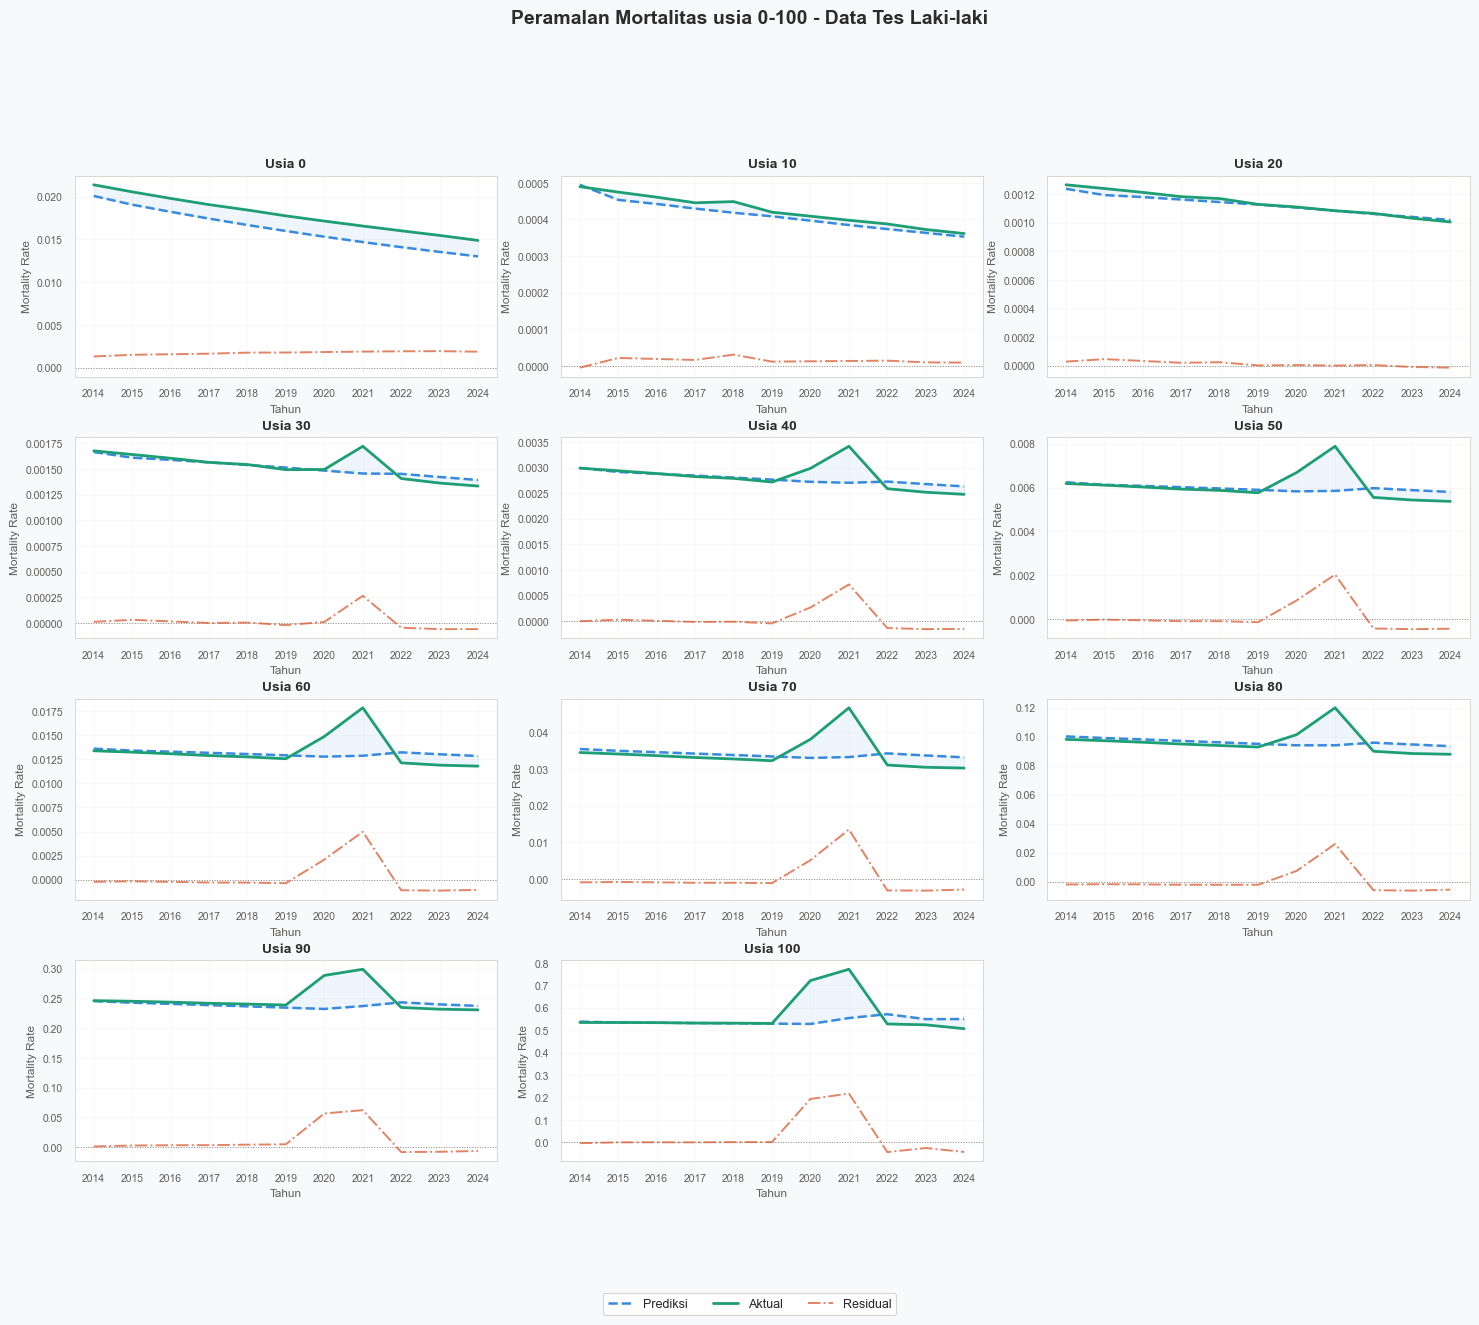

In [77]:
plot_tes_vs_peramalan(
    start_age=0,
    end_age=100,
    factor=10,
    gender=0
)

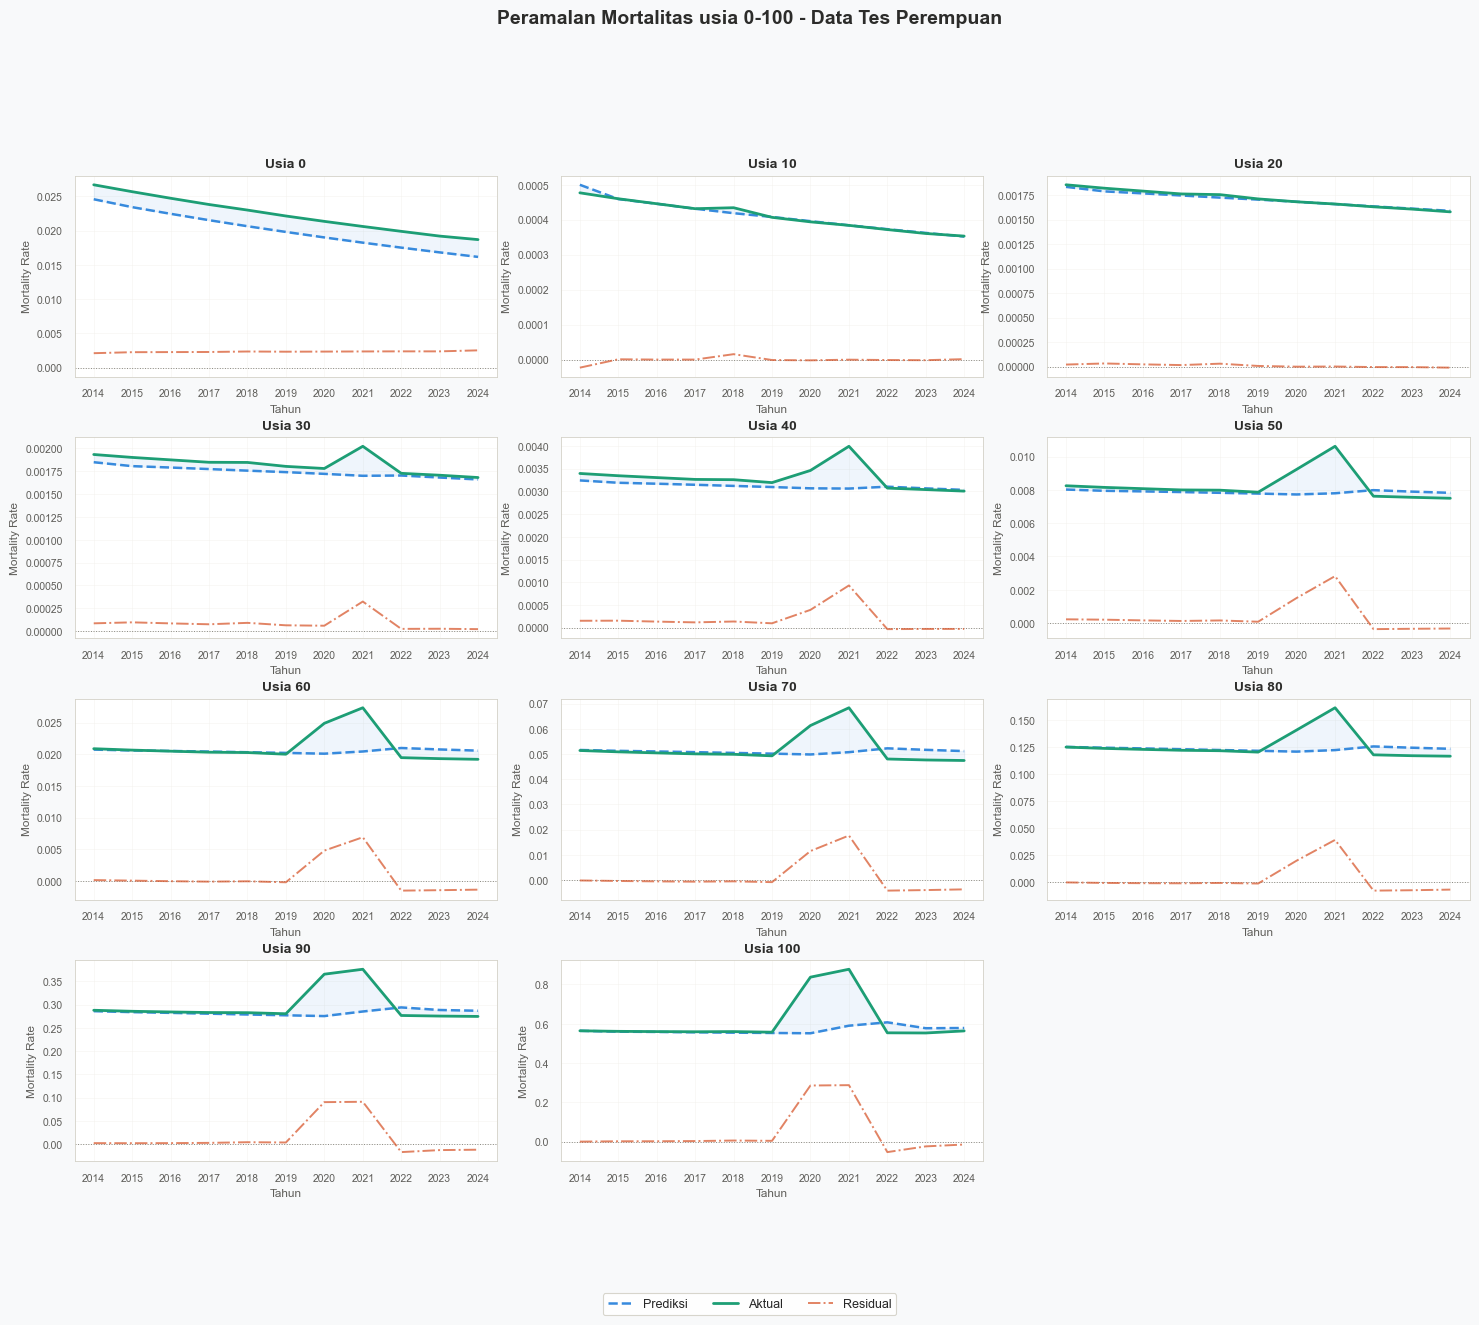

In [78]:
plot_tes_vs_peramalan(
    start_age=0,
    end_age=100,
    factor=10,
    gender=1
)

# Interpretasi pemodelan

## Perhitungan regression attention

In [79]:
male_dataset = create_male_dataset_split(transformed_M_male)
male_dataloader = DataLoader(male_dataset, batch_size=len(male_dataset))
male_mortality = None

male_reg_att = []
for batch in male_dataloader:
    x, _ = batch
    male_mortality = x

    window = []
    for model in localglmnet_ensemble.models:
        assert isinstance(model, LocalGLMnet)
        reg_att = model.get_regression_attention(x)
        window.append(reg_att)

    window = torch.cat(window).to(DEVICE)
    male_reg_att.append(window)

male_reg_att = torch.cat(male_reg_att).to(DEVICE)

print(male_reg_att.shape)
print(male_mortality.shape)

torch.Size([650, 10, 101])
torch.Size([65, 10, 101])


In [80]:
female_dataset = create_female_dataset_split(transformed_M_female)
female_dataloader = DataLoader(female_dataset, batch_size=len(female_dataset))
female_mortality = None

female_reg_att = []
for batch in female_dataloader:
    x, _ = batch
    female_mortality = x
    window = []
    for model in localglmnet_ensemble.models:
        assert isinstance(model, LocalGLMnet)
        reg_att = model.get_regression_attention(x)
        window.append(reg_att)

    window = torch.cat(window).to(DEVICE)
    female_reg_att.append(window)

female_reg_att = torch.cat(female_reg_att).to(DEVICE)

print(female_reg_att.shape)
print(female_mortality.shape)

torch.Size([650, 10, 101])
torch.Size([65, 10, 101])


## Plot mortalitas vs regression attention

In [81]:
import numpy as np

# warna per lag
_BASE_COLORS = [
    "#E63946",   # lag 0  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ vivid red
    "#F4A261",   # lag 1  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ warm orange
    "#2A9D8F",   # lag 2  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ teal
    "#457B9D",   # lag 3  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ steel blue
    "#A8DADC",   # lag 4  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ pale cyan
    "#8338EC",   # lag 5  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ violet
    "#FB5607",   # lag 6  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ burnt orange
    "#3A86FF",   # lag 7  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ bright blue
    "#06D6A0",   # lag 8  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ mint
    "#FFBE0B",   # lag 9  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ golden yellow
]


def _to_numpy(t) -> np.ndarray:
    """Konversi torch.Tensor / np.ndarray ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ float64 numpy."""
    if hasattr(t, "detach"):
        return t.detach().cpu().numpy().astype(float)
    return np.asarray(t, dtype=float)


def _flatten3d(arr: np.ndarray) -> np.ndarray:
    """
    Flatten semua dimensi kecuali dua terakhir (n_lags, n_ages).
    Input  : (..., n_lags, n_ages)
    Output : (N, n_lags, n_ages)
    """
    *leading, n_lags, n_ages = arr.shape
    N = int(np.prod(leading)) if leading else 1
    return arr.reshape(N, n_lags, n_ages)


def _smart_fmt(v: float, _) -> str:
    if v == 0:
        return "0"
    av = abs(v)
    if av < 0.001:
        return f"{v:.4f}"
    if av < 0.01:
        return f"{v:.3f}"
    if av < 0.1:
        return f"{v:.2f}"
    return f"{v:.2f}"


# FUNGSI UTAMA
def plot_attention_regression(
    mortality_tensor: Tensor,
    attention_tensor: Tensor,
    save_path: Path,
    start_age:   int  = 0,
    end_age:     int  = 100,
    factor:      int  = 5,
    suptitle:    str  = "LocalGLMnet - Attention Regression Coefficients",
    panel_cols:  int  = 7,
    dpi:         int  = 200,
) -> None:
    """
    Plot scatter (m_{t,x}, beta_{t-s,x}) untuk setiap usia x dan lag s.

    Parameters
    ----------
    mortality_tensor : (..., n_lags, n_ages)
        Data mortalitas. Dua dimensi terakhir wajib (n_lags, n_ages).
        Semua dimensi sebelumnya di-flatten menjadi sumbu sampel.

    attention_tensor : (..., n_lags, n_ages)
        Attention coefficient. Dua dimensi terakhir wajib sama dengan
        mortality_tensor.

    start_age, end_age, factor : int
        Panel usia: start_age, start_age+factor, ..., end_age.

    suptitle : str
        Judul besar di atas semua panel.

    panel_cols : int
        Jumlah kolom panel.

    save_path : str | None
        Path simpan PNG; None = tidak disimpan.

    dpi : int
        Resolusi gambar.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    # 0. konversi & flatten
    mx  = _to_numpy(mortality_tensor)
    att = _to_numpy(attention_tensor)

    if mx.ndim < 2 or att.ndim < 2:
        raise ValueError("Kedua tensor harus minimal 2 dimensi (..., n_lags, n_ages).")

    # pastikan minimal 3D sebelum flatten
    if mx.ndim == 2:
        mx = mx[np.newaxis]
    if att.ndim == 2:
        att = att[np.newaxis]

    mx_flat  = _flatten3d(mx)    # (N_mort, n_lags, n_ages)
    att_flat = _flatten3d(att)   # (N_att,  n_lags, n_ages)

    N_mort, n_lags_mx, n_ages_mx   = mx_flat.shape
    N_att,  n_lags_att, n_ages_att = att_flat.shape

    # validasi dimensi terakhir
    if n_lags_mx != n_lags_att:
        raise ValueError(
            f"Dimensi lag tidak cocok: mortality={n_lags_mx}, attention={n_lags_att}."
        )
    if n_ages_mx != n_ages_att:
        raise ValueError(
            f"Dimensi usia tidak cocok: mortality={n_ages_mx}, attention={n_ages_att}."
        )

    n_lags = n_lags_mx
    n_ages = n_ages_mx

    # 1. sinkronisasi N_mort vs N_att via repeat
    if N_att != N_mort:
        if N_att % N_mort == 0:
            k = N_att // N_mort
            mx_flat = np.repeat(mx_flat, k, axis=0)   # (N_att, n_lags, n_ages)
        elif N_mort % N_att == 0:
            k = N_mort // N_att
            att_flat = np.repeat(att_flat, k, axis=0) # (N_mort, n_lags, n_ages)
        else:
            # Tidak habis dibagi: potong ke ukuran terkecil
            N_min = min(N_mort, N_att)
            mx_flat  = mx_flat[:N_min]
            att_flat = att_flat[:N_min]
            import warnings
            warnings.warn(
                f"N_mort={N_mort} dan N_att={N_att} tidak saling habis dibagi. "
                f"Dipotong ke {N_min} sampel pertama.",
                UserWarning,
                stacklevel=2,
            )

    N = mx_flat.shape[0]   # ukuran sampel final

    # 2. daftar usia panel
    ages_step = list(range(start_age, end_age, factor))
    if end_age not in ages_step:
        ages_step.append(end_age)
    ages_step = [a for a in ages_step if 0 <= a < n_ages]
    n_panels  = len(ages_step)
    n_rows    = (n_panels + panel_cols - 1) // panel_cols

    # 3. warna lag
    if n_lags <= len(_BASE_COLORS):
        lag_colors = _BASE_COLORS[:n_lags]
    else:
        cmap = plt.get_cmap("tab20", n_lags)
        lag_colors = [cmap(i) for i in range(n_lags)]

    # 4. figure layout
    sns.set_theme(style="white", font_scale=0.85)

    panel_w, panel_h = 3.0, 2.8
    fig_w      = panel_w * panel_cols
    top_pad    = 0.75
    bottom_pad = 1.50
    fig_h      = top_pad + panel_h * n_rows + bottom_pad

    top_frac    = 1.0 - top_pad    / fig_h
    bottom_frac = bottom_pad / fig_h

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="white")

    gs = fig.add_gridspec(
        n_rows, panel_cols,
        left=0.06, right=0.99,
        top=top_frac, bottom=bottom_frac,
        hspace=0.60, wspace=0.50,
    )

    # 5. suptitle & subtitle
    fig.suptitle(
        suptitle,
        fontsize=12, fontweight="bold", color="#1a1a2e",
        y=top_frac + (top_pad * 0.60) / fig_h,
        va="bottom",
    )

    # 6. plot panel
    for idx, age in enumerate(ages_step):
        row, col = divmod(idx, panel_cols)
        ax = fig.add_subplot(gs[row, col])

        for s in range(n_lags):   # lag kecil di depan
            x_vals = mx_flat[:,  s, age]   # (N,) mortalitas
            y_vals = att_flat[:, s, age]   # (N,) attention

            ax.scatter(
                x_vals, y_vals,
                s=4, color=lag_colors[s],
                alpha=0.45, linewidths=0,
                zorder=n_lags - s,
            )

        # styling
        ax.set_title(str(age), fontsize=9, fontweight="semibold",
                     pad=3, color="#1a1a2e")
        ax.tick_params(axis="both", labelsize=6.5, length=2.5, color="#666")

        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3, prune="both"))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(_smart_fmt))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune="both"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(_smart_fmt))

        sns.despine(ax=ax, top=True, right=True)
        for sp in ("bottom", "left"):
            ax.spines[sp].set_linewidth(0.6)
            ax.spines[sp].set_color("#bbb")
        ax.set_facecolor("white")

        if col == 0:
            ax.set_ylabel("Regression Attention", fontsize=7.5,
                          color="#333", labelpad=4)
        if (row == n_rows - 1) or (idx == n_panels - 1):
            ax.set_xlabel("mx (transformed)", fontsize=7.5, color="#333", labelpad=2)

    # 7. legend bersama
    legend_handles = [
        plt.scatter([], [], s=26, color=lag_colors[n_lags - s - 1],
                    label=str(s), alpha=0.9, linewidths=0)
        for s in range(n_lags)
    ]
    fig.legend(
        handles=legend_handles,
        title="lag", title_fontsize=8, fontsize=7.5,
        ncol=min(n_lags, 10),
        loc="lower center",
        bbox_to_anchor=(0.5, bottom_frac * 0.60),
        frameon=True, framealpha=0.92, edgecolor="#ddd",
        fancybox=False, columnspacing=0.9,
        handletextpad=0.3, borderpad=0.5,
    )

    # 9. simpan
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved -> {save_path}")

    plt.show()

### Laki-laki

Saved -> plots\mortalitas_vs_reg_attention_laki-laki_localglmnet1.png


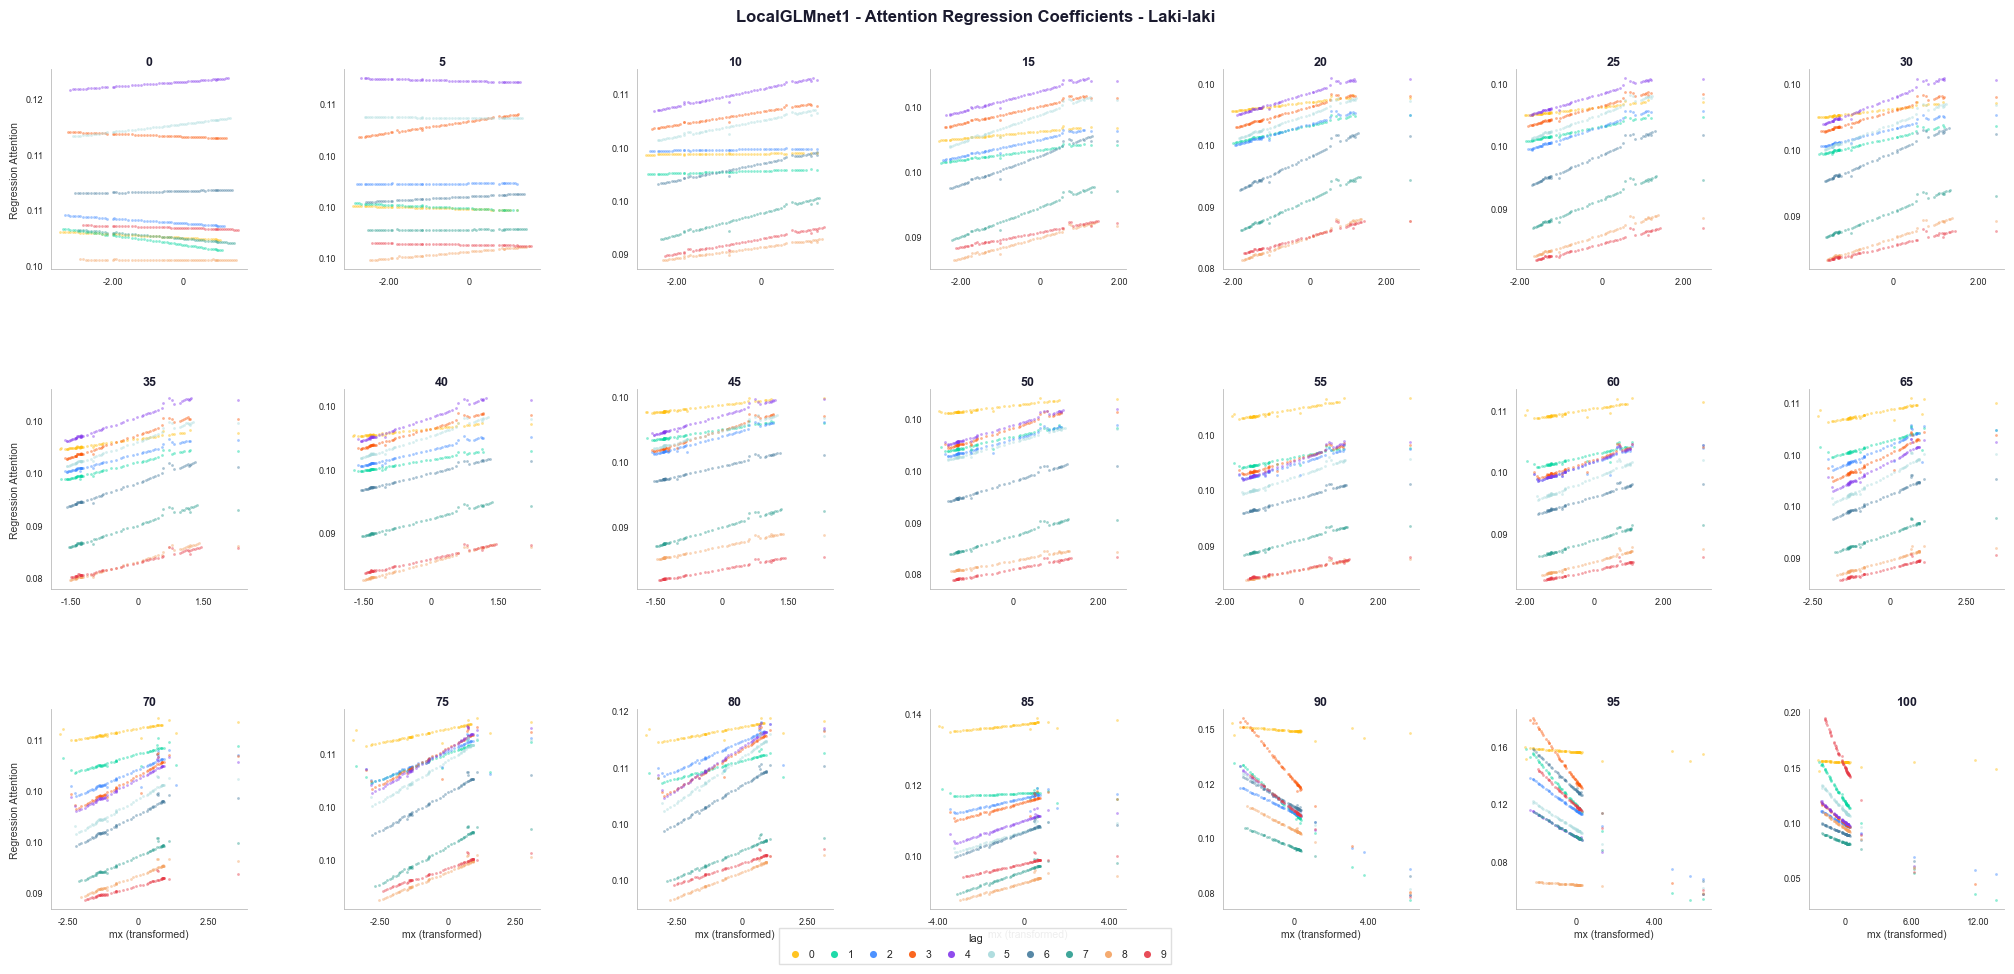

In [82]:
n = 1
assert 0 < n <= 10

reg_att = male_reg_att[(n-1) * 65:n * 65]

plot_attention_regression(
    mortality_tensor=male_mortality,
    attention_tensor=reg_att,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_reg_attention_laki-laki_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Coefficients - Laki-laki"
)

Saved -> plots\mortalitas_vs_reg_attention_laki-laki_localglmnet5.png


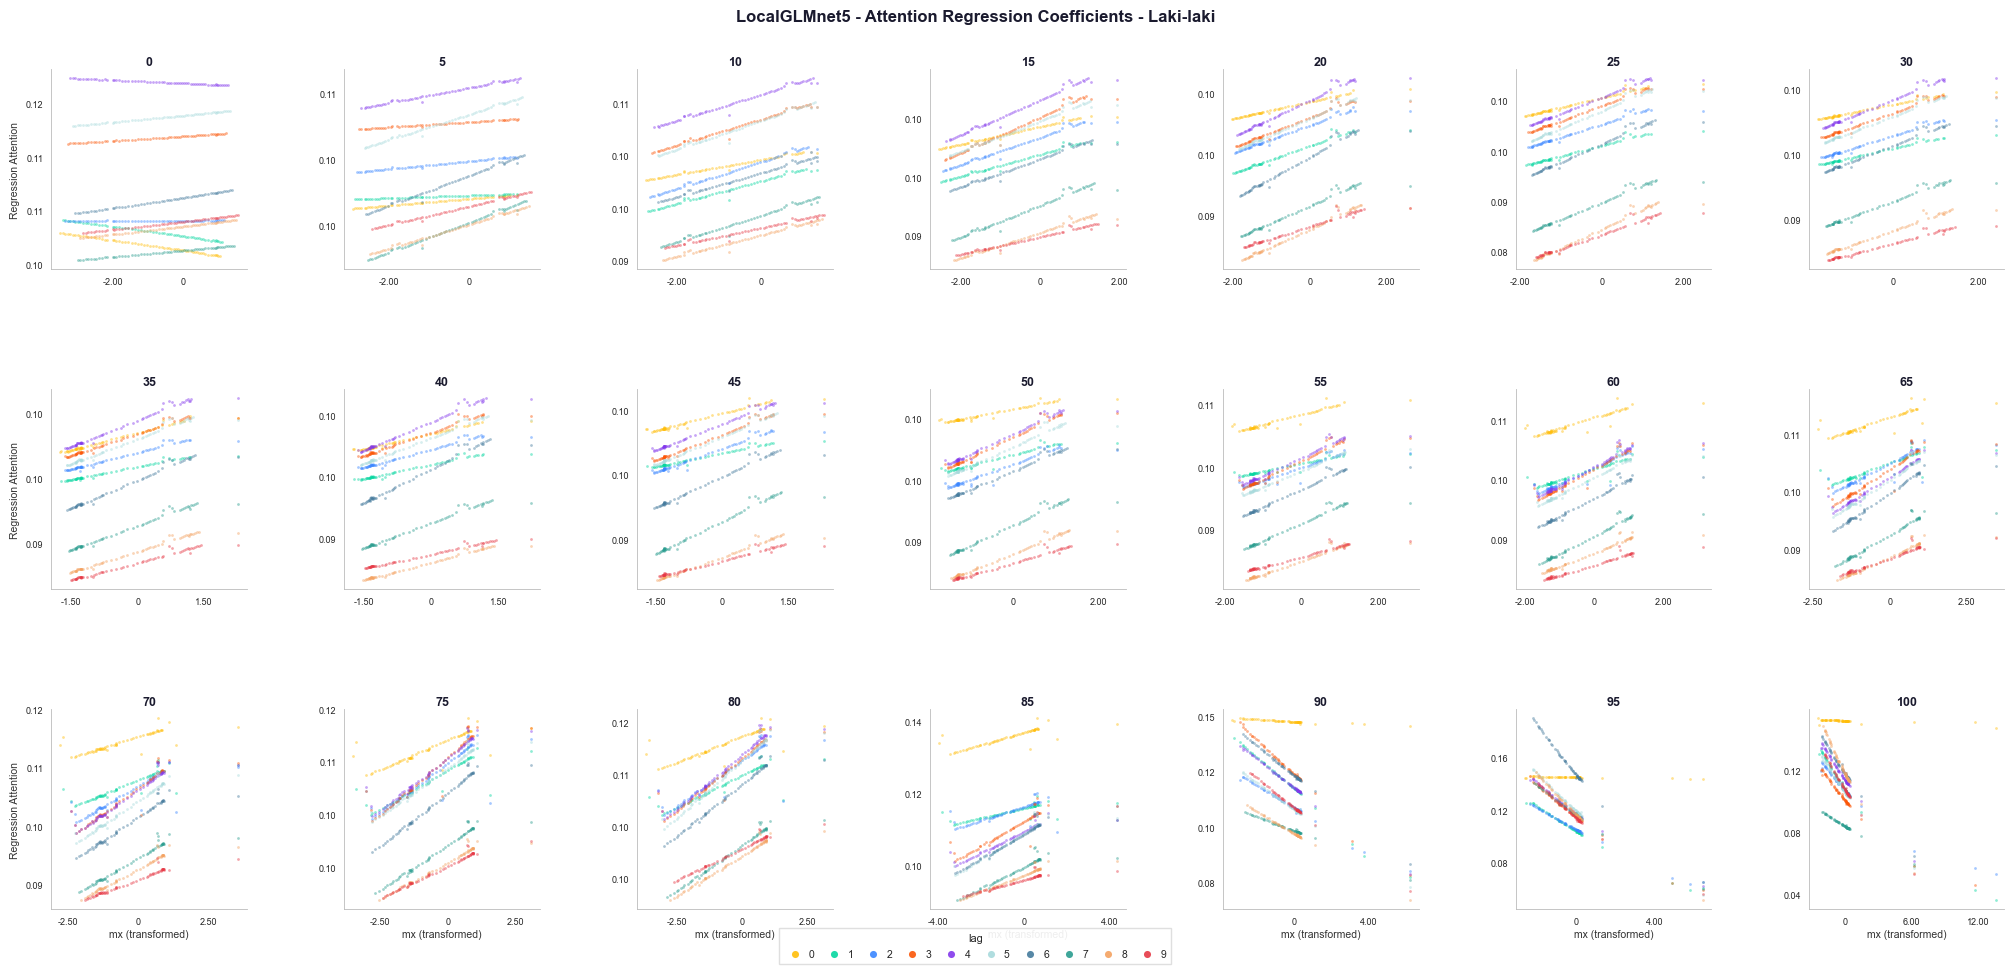

In [83]:
n = 5
assert 0 < n <= 10

reg_att = male_reg_att[(n-1) * 65:n * 65]

plot_attention_regression(
    mortality_tensor=male_mortality,
    attention_tensor=reg_att,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_reg_attention_laki-laki_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Coefficients - Laki-laki"
)

Saved -> plots\mortalitas_vs_reg_attention_laki-laki_localglmnet10.png


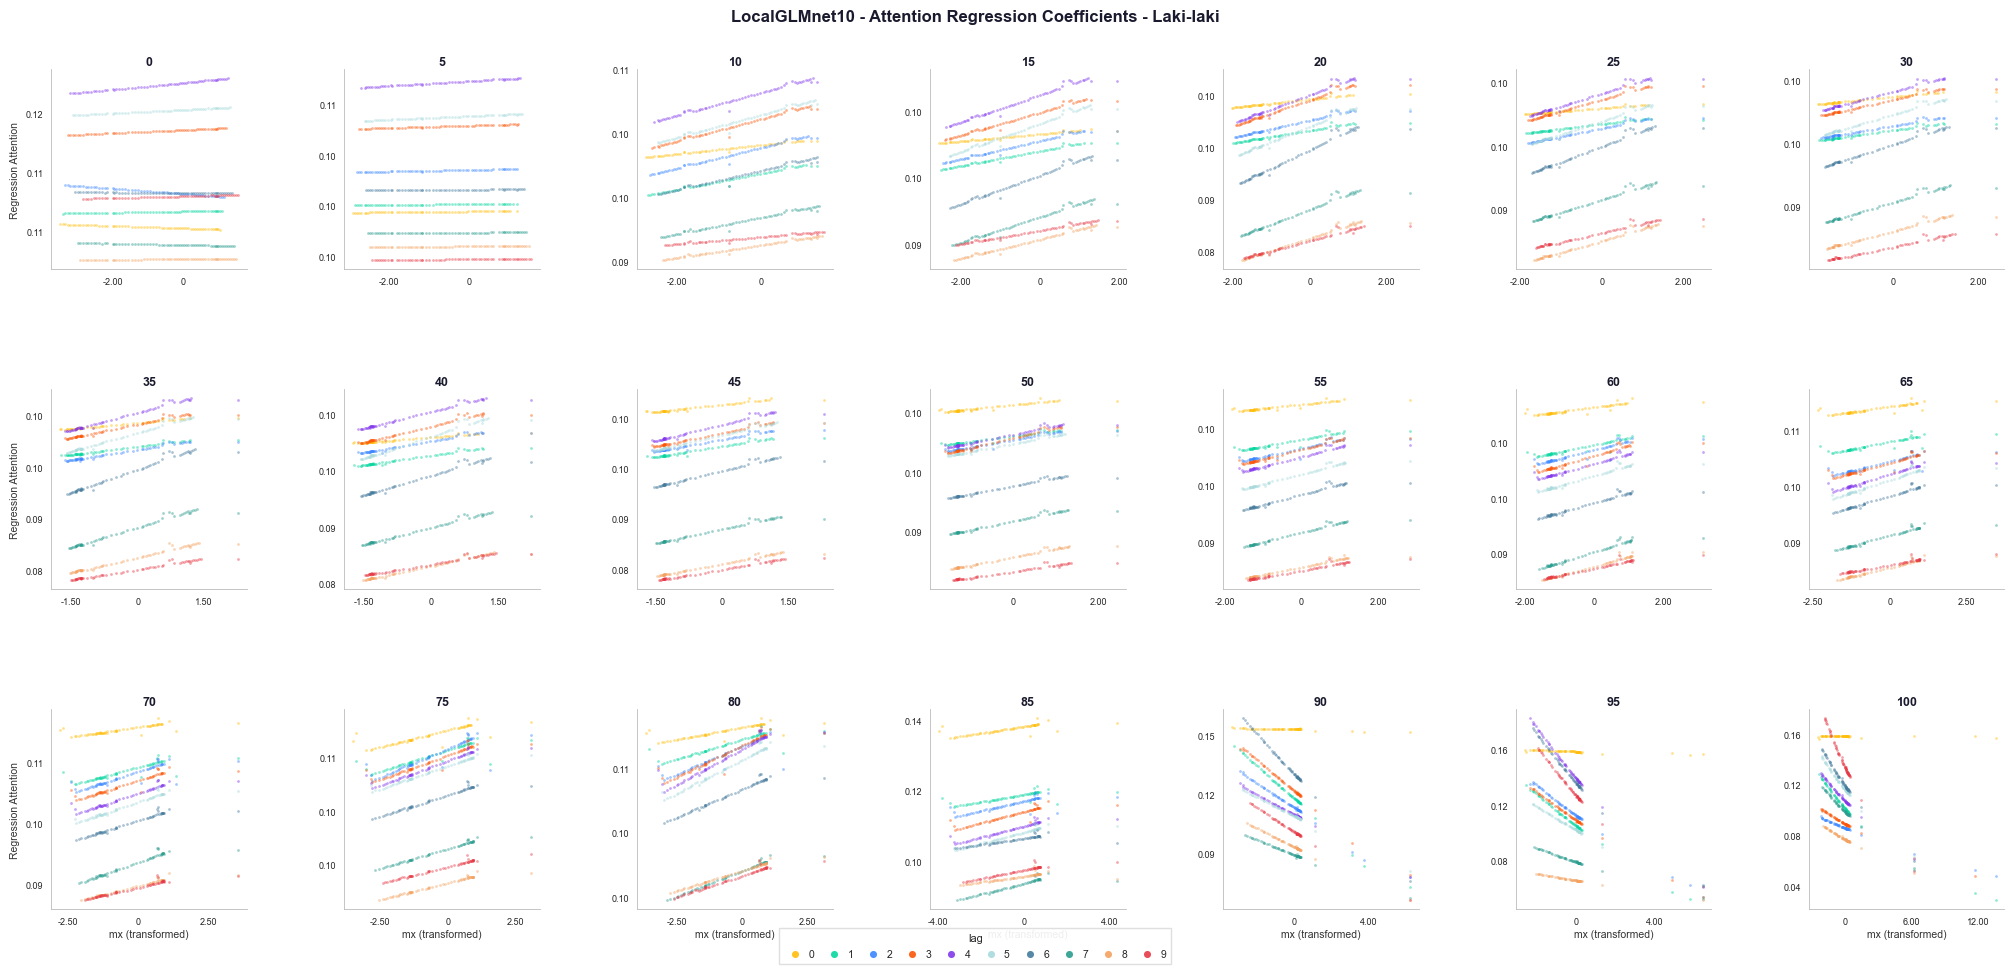

In [84]:
n = 10
assert 0 < n <= 10

reg_att = male_reg_att[(n-1) * 65:n * 65]

plot_attention_regression(
    mortality_tensor=male_mortality,
    attention_tensor=reg_att,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_reg_attention_laki-laki_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Coefficients - Laki-laki"
)

### Perempuan

Saved -> plots\mortalitas_vs_reg_attention_perempuan_localglmnet1.png


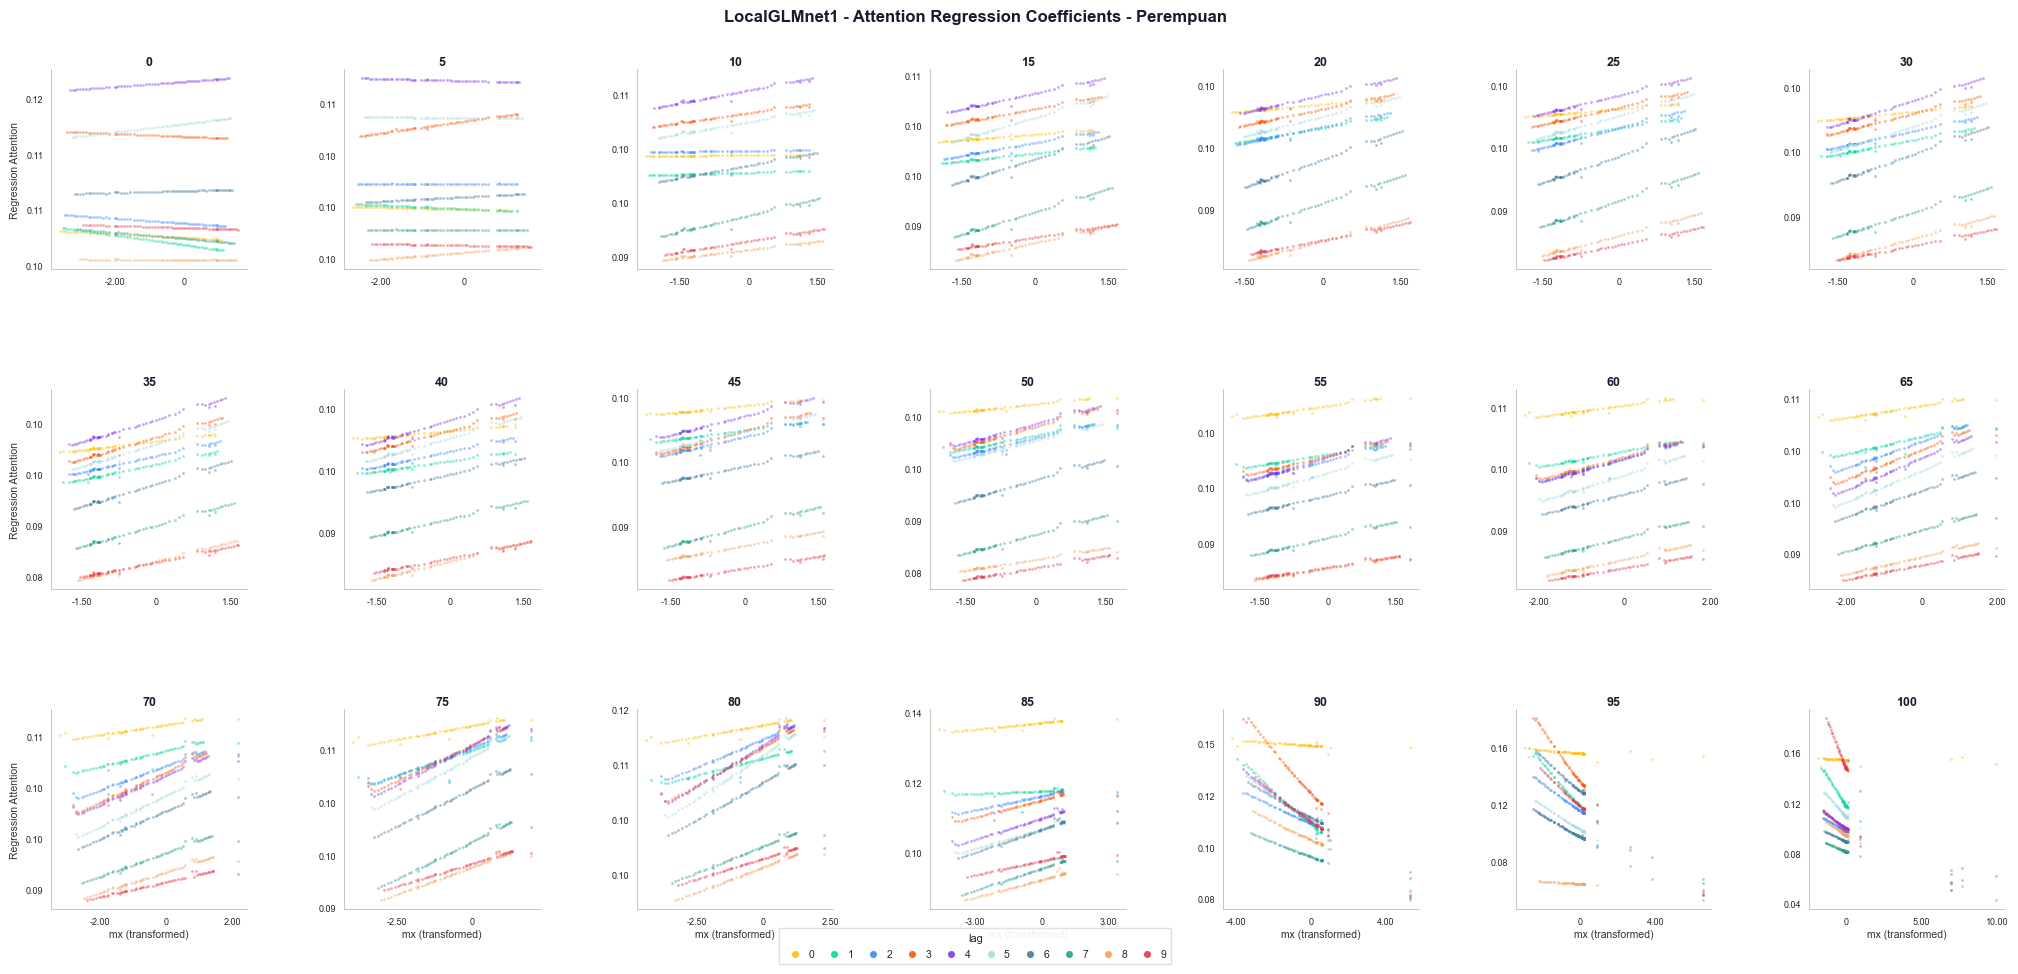

In [85]:
n = 1
assert 0 < n <= 10

reg_att = female_reg_att[(n-1) * 65:n * 65]

plot_attention_regression(
    mortality_tensor=female_mortality,
    attention_tensor=reg_att,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_reg_attention_perempuan_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Coefficients - Perempuan"
)

Saved -> plots\mortalitas_vs_reg_attention_perempuan_localglmnet5.png


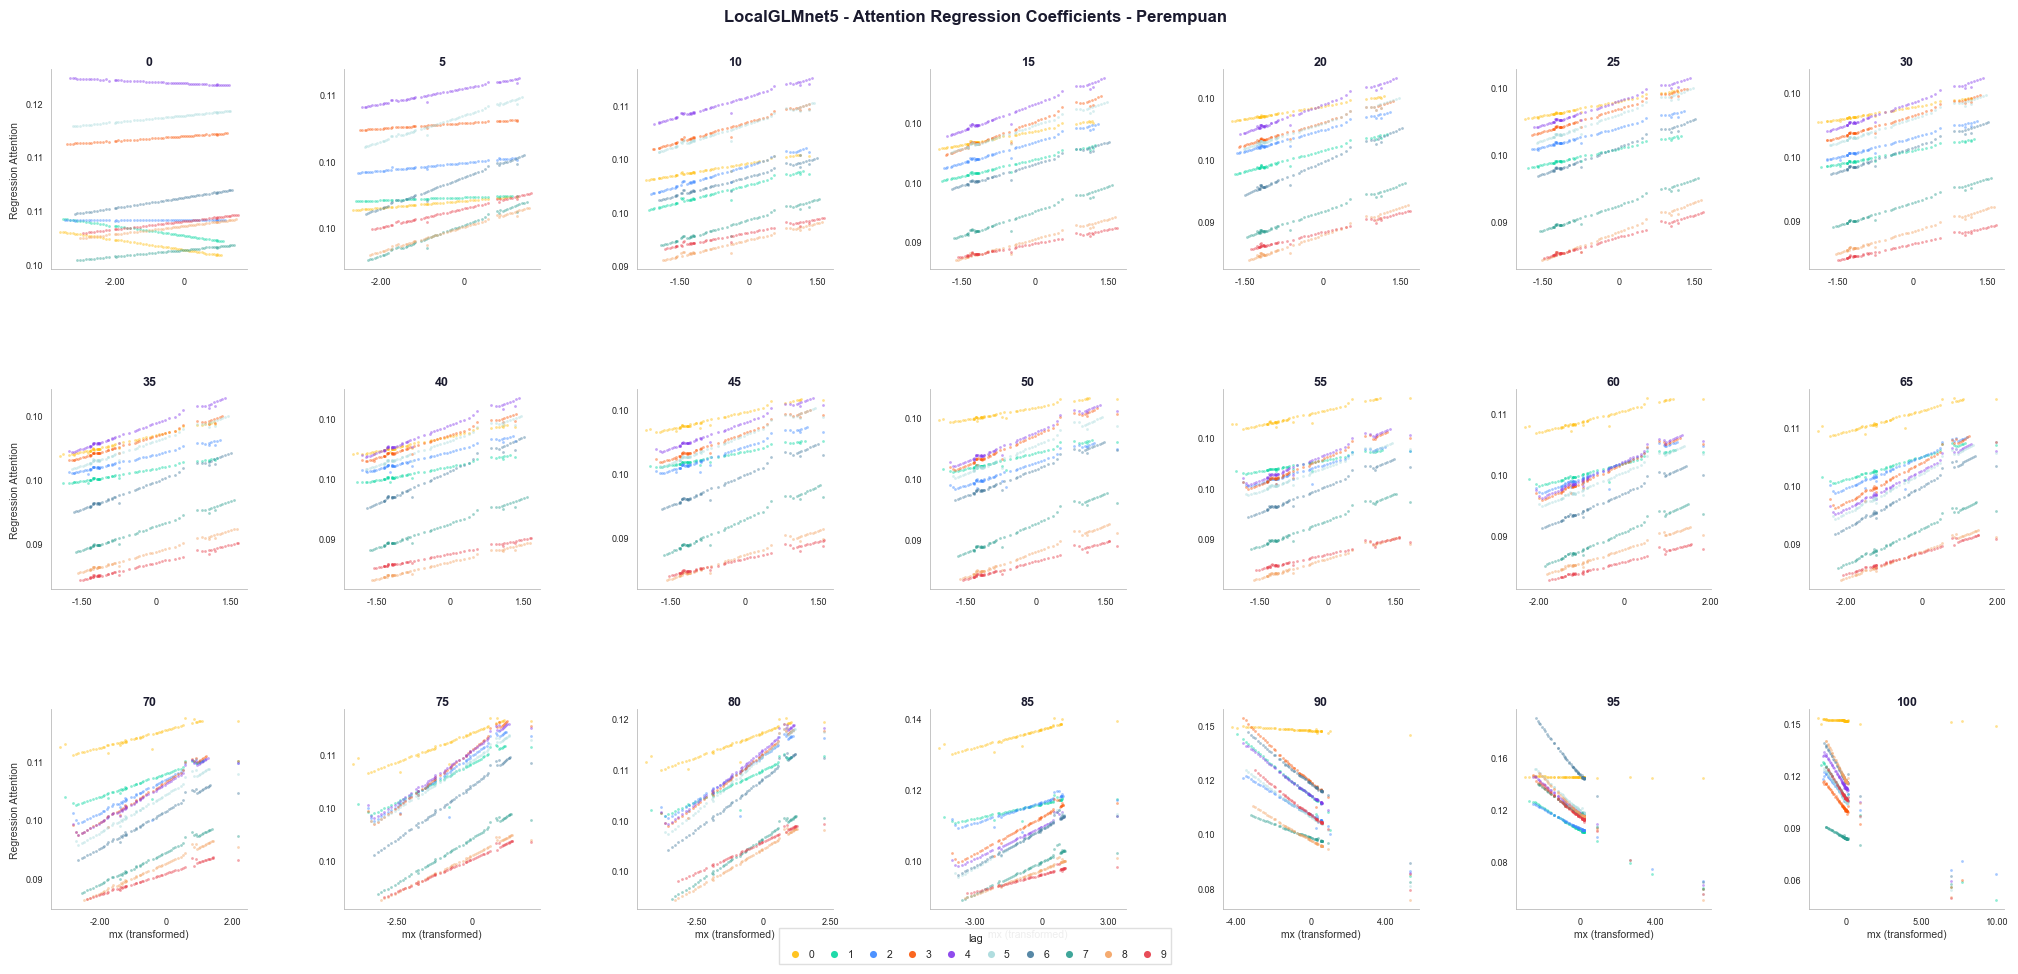

In [86]:
n = 5
assert 0 < n <= 10

reg_att = female_reg_att[(n-1) * 65:n * 65]

plot_attention_regression(
    mortality_tensor=female_mortality,
    attention_tensor=reg_att,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_reg_attention_perempuan_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Coefficients - Perempuan"
)

Saved -> plots\mortalitas_vs_reg_attention_perempuan_localglmnet10.png


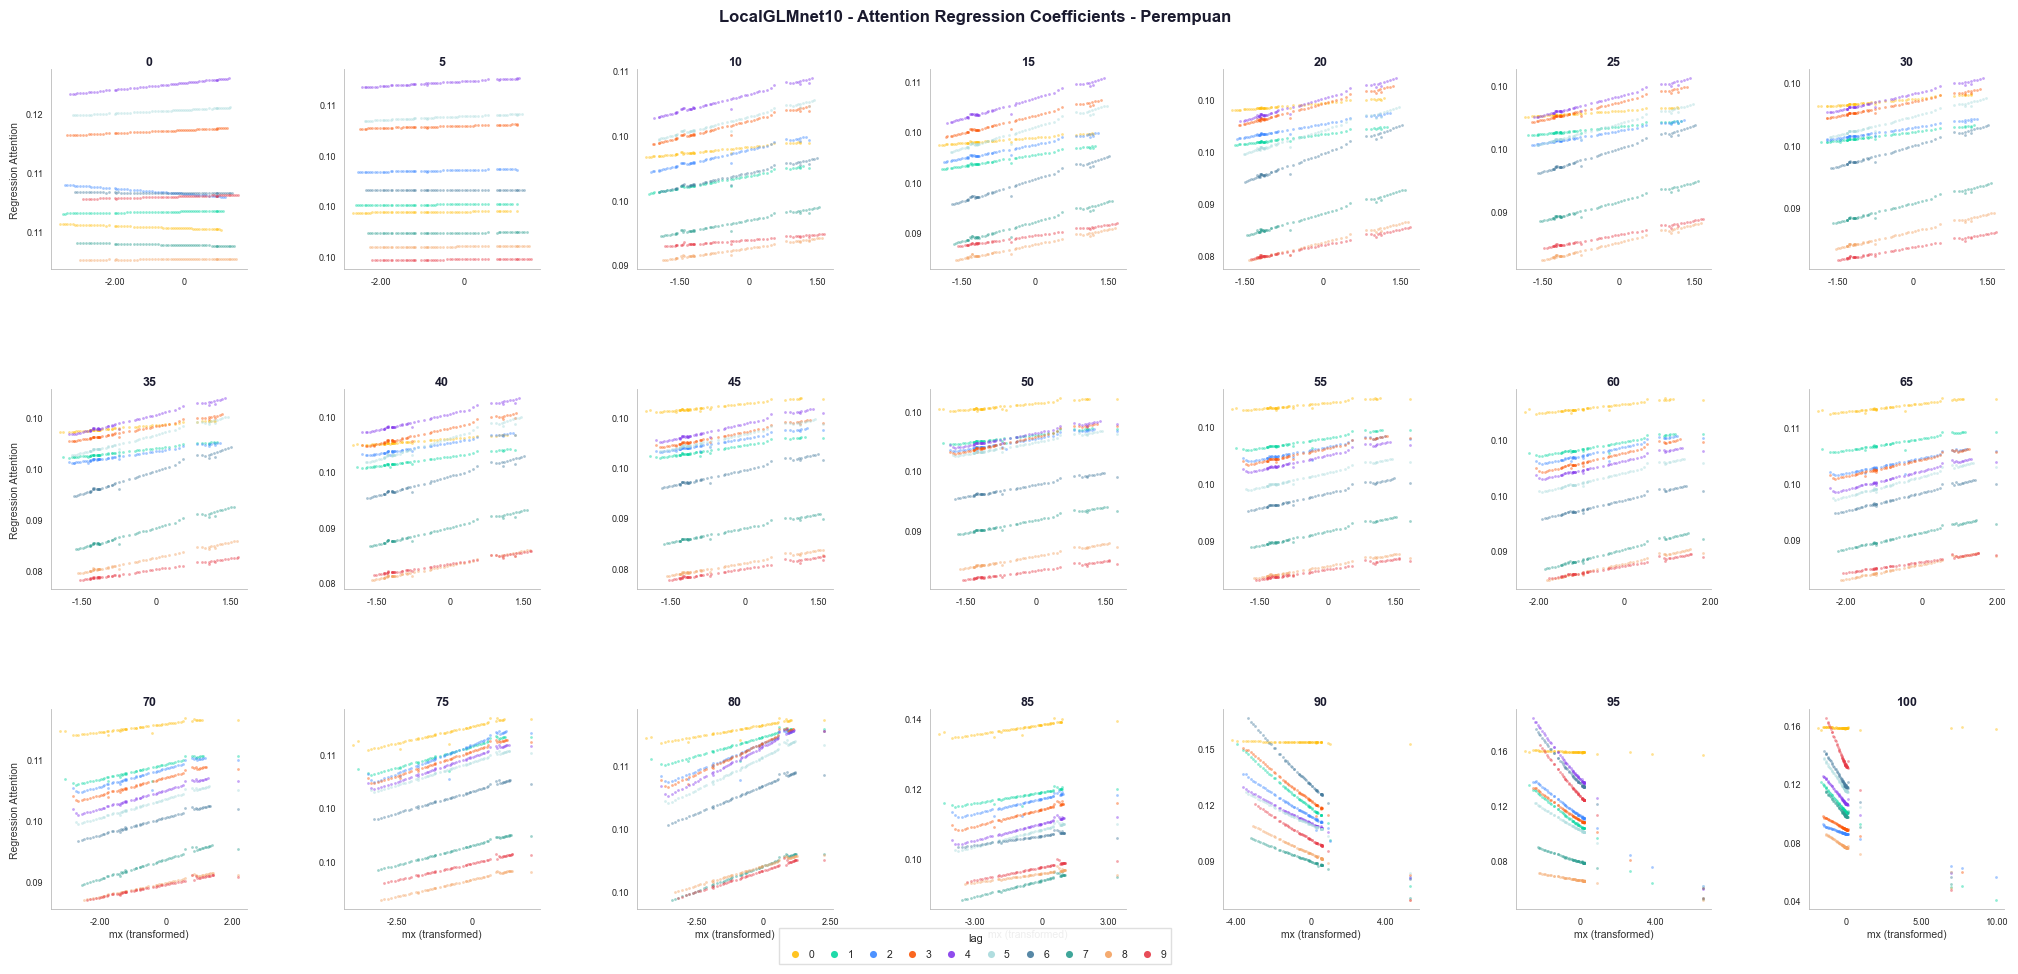

In [87]:
n = 10
assert 0 < n <= 10

reg_att = female_reg_att[(n-1) * 65:n * 65]

plot_attention_regression(
    mortality_tensor=female_mortality,
    attention_tensor=reg_att,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_reg_attention_perempuan_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Coefficients - Perempuan"
)

## Plot attention contribution

In [128]:
import numpy as np

# warna per lag
_BASE_COLORS = [
    "#E63946",   # lag 0  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ vivid red
    "#F4A261",   # lag 1  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ warm orange
    "#2A9D8F",   # lag 2  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ teal
    "#457B9D",   # lag 3  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ steel blue
    "#A8DADC",   # lag 4  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ pale cyan
    "#8338EC",   # lag 5  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ violet
    "#FB5607",   # lag 6  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ burnt orange
    "#3A86FF",   # lag 7  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ bright blue
    "#06D6A0",   # lag 8  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ mint
    "#FFBE0B",   # lag 9  ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ golden yellow
]


def _to_numpy(t) -> np.ndarray:
    """Konversi torch.Tensor / np.ndarray ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ float64 numpy."""
    if hasattr(t, "detach"):
        return t.detach().cpu().numpy().astype(float)
    return np.asarray(t, dtype=float)


def _flatten3d(arr: np.ndarray) -> np.ndarray:
    """
    Flatten semua dimensi kecuali dua terakhir (n_lags, n_ages).
    Input  : (..., n_lags, n_ages)
    Output : (N, n_lags, n_ages)
    """
    *leading, n_lags, n_ages = arr.shape
    N = int(np.prod(leading)) if leading else 1
    return arr.reshape(N, n_lags, n_ages)


def _smart_fmt(v: float, _) -> str:
    if v == 0:
        return "0"
    av = abs(v)
    if av < 0.001:
        return f"{v:.4f}"
    if av < 0.01:
        return f"{v:.3f}"
    if av < 0.1:
        return f"{v:.2f}"
    return f"{v:.2f}"

# FUNGSI UTAMA

def plot_attention_contribution(
    mortality_tensor: Tensor,
    contribution_tensor: Tensor,
    save_path: Path,
    start_age:   int  = 0,
    end_age:     int  = 100,
    factor:      int  = 5,
    suptitle:    str  = "LocalGLMnet ﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿﷿ Attention Regression Contribution",
    panel_cols:  int  = 7,
    dpi:         int  = 200,
) -> None:
    """
    Plot scatter (m_{t,x}, beta_{t-s,x}) untuk setiap usia x dan lag s.

    Parameters
    ----------
    mortality_tensor : (..., n_lags, n_ages)
        Data mortalitas. Dua dimensi terakhir wajib (n_lags, n_ages).
        Semua dimensi sebelumnya di-flatten menjadi sumbu sampel.

    contribution_tensor : (..., n_lags, n_ages)
        Attention coefficient. Dua dimensi terakhir wajib sama dengan
        mortality_tensor.

    start_age, end_age, factor : int
        Panel usia: start_age, start_age+factor, ..., end_age.

    suptitle : str
        Judul besar di atas semua panel.

    panel_cols : int
        Jumlah kolom panel.

    save_path : str | None
        Path simpan PNG; None = tidak disimpan.

    dpi : int
        Resolusi gambar.

    Returns
    -------
    fig : matplotlib.figure.Figure
    """
    # 0. konversi & flatten
    mortality_tensor = mortality_tensor.cpu()
    contribution_tensor = contribution_tensor.cpu()
    att_contribution = _to_numpy(contribution_tensor)
    mx = mortality_tensor
    if mx.ndim < 2 or att_contribution.ndim < 2:
        raise ValueError("Kedua tensor harus minimal 2 dimensi (..., n_lags, n_ages).")

    # pastikan minimal 3D sebelum flatten
    if mx.ndim == 2:
        mx = mx[np.newaxis]
    if att_contribution.ndim == 2:
        att_contribution = att_contribution[np.newaxis]

    mx_flat  = _flatten3d(mx)    # (N_mort, n_lags, n_ages)
    att_flat = _flatten3d(att_contribution)   # (N_att,  n_lags, n_ages)

    N_mort, n_lags_mx, n_ages_mx   = mx_flat.shape
    N_att,  n_lags_att, n_ages_att = att_flat.shape

    # validasi dimensi terakhir
    if n_lags_mx != n_lags_att:
        raise ValueError(
            f"Dimensi lag tidak cocok: mortality={n_lags_mx}, attention={n_lags_att}."
        )
    if n_ages_mx != n_ages_att:
        raise ValueError(
            f"Dimensi usia tidak cocok: mortality={n_ages_mx}, attention={n_ages_att}."
        )

    n_lags = n_lags_mx
    n_ages = n_ages_mx

    # 1. sinkronisasi N_mort vs N_att via repeat
    if N_att != N_mort:
        if N_att % N_mort == 0:
            k = N_att // N_mort
            mx_flat = np.repeat(mx_flat, k, axis=0)   # (N_att, n_lags, n_ages)
        elif N_mort % N_att == 0:
            k = N_mort // N_att
            att_flat = np.repeat(att_flat, k, axis=0) # (N_mort, n_lags, n_ages)
        else:
            # Tidak habis dibagi: potong ke ukuran terkecil
            N_min = min(N_mort, N_att)
            mx_flat  = mx_flat[:N_min]
            att_flat = att_flat[:N_min]
            import warnings
            warnings.warn(
                f"N_mort={N_mort} dan N_att={N_att} tidak saling habis dibagi. "
                f"Dipotong ke {N_min} sampel pertama.",
                UserWarning,
                stacklevel=2,
            )

    N = mx_flat.shape[0]   # ukuran sampel final

    # 2. daftar usia panel
    ages_step = list(range(start_age, end_age, factor))
    if end_age not in ages_step:
        ages_step.append(end_age)
    ages_step = [a for a in ages_step if 0 <= a < n_ages]
    n_panels  = len(ages_step)
    n_rows    = (n_panels + panel_cols - 1) // panel_cols

    # 3. warna lag
    if n_lags <= len(_BASE_COLORS):
        lag_colors = _BASE_COLORS[:n_lags]
    else:
        cmap = plt.get_cmap("tab20", n_lags)
        lag_colors = [cmap(i) for i in range(n_lags)]

    # 4. figure layout
    panel_w, panel_h = 3.0, 2.8
    fig_w      = panel_w * panel_cols
    top_pad    = 0.75
    bottom_pad = 1.50
    fig_h      = top_pad + panel_h * n_rows + bottom_pad

    top_frac    = 1.0 - top_pad    / fig_h
    bottom_frac = bottom_pad / fig_h

    fig = plt.figure(figsize=(fig_w, fig_h), facecolor="white")

    gs = fig.add_gridspec(
        n_rows, panel_cols,
        left=0.06, right=0.99,
        top=top_frac, bottom=bottom_frac,
        hspace=0.60, wspace=0.50,
    )

    # 5. suptitle & subtitle
    fig.suptitle(
        suptitle,
        fontsize=12, fontweight="bold", color="#1a1a2e",
        y=top_frac + (top_pad * 0.60) / fig_h,
        va="bottom",
    )

    # 6. plot panel
    for idx, age in enumerate(ages_step):
        row, col = divmod(idx, panel_cols)
        ax = fig.add_subplot(gs[row, col])

        for s in range(n_lags):   # lag kecil di depan
            x_vals = mx_flat[:,  s, age]   # (N,) mortalitas
            y_vals = att_flat[:, s, age]   # (N,) attention

            ax.scatter(
                x_vals, y_vals,
                s=4, color=lag_colors[s],
                alpha=0.45, linewidths=0,
                zorder=n_lags - s,
            )

        # styling
        ax.set_title(str(age), fontsize=9, fontweight="semibold",
                     pad=3, color="#1a1a2e")
        ax.tick_params(axis="both", labelsize=6.5, length=2.5, color="#666")

        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3, prune="both"))
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(_smart_fmt))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4, prune="both"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(_smart_fmt))

        sns.despine(ax=ax, top=True, right=True)
        for sp in ("bottom", "left"):
            ax.spines[sp].set_linewidth(0.6)
            ax.spines[sp].set_color("#bbb")
        ax.set_facecolor("white")

        if col == 0:
            ax.set_ylabel("Contribution Value", fontsize=7.5,
                          color="#333", labelpad=4)
        if (row == n_rows - 1) or (idx == n_panels - 1):
            ax.set_xlabel("mx (transformed)", fontsize=7.5, color="#333", labelpad=2)

    # 7. legend bersama
    legend_handles = [
        plt.scatter([], [], s=26, color=lag_colors[n_lags - s - 1],
                    label=str(s), alpha=0.9, linewidths=0)
        for s in range(n_lags)
    ]
    fig.legend(
        handles=legend_handles,
        title="lag", title_fontsize=8, fontsize=7.5,
        ncol=min(n_lags, 10),
        loc="lower center",
        bbox_to_anchor=(0.5, bottom_frac * 0.60),
        frameon=True, framealpha=0.92, edgecolor="#ddd",
        fancybox=False, columnspacing=0.9,
        handletextpad=0.3, borderpad=0.5,
    )

    # 9. simpan
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight", facecolor="white")
        print(f"Saved -> {save_path}")

    plt.show()

### Laki-laki

Saved -> plots\mortalitas_vs_attention_contribution_laki-laki_localglmnet1.png


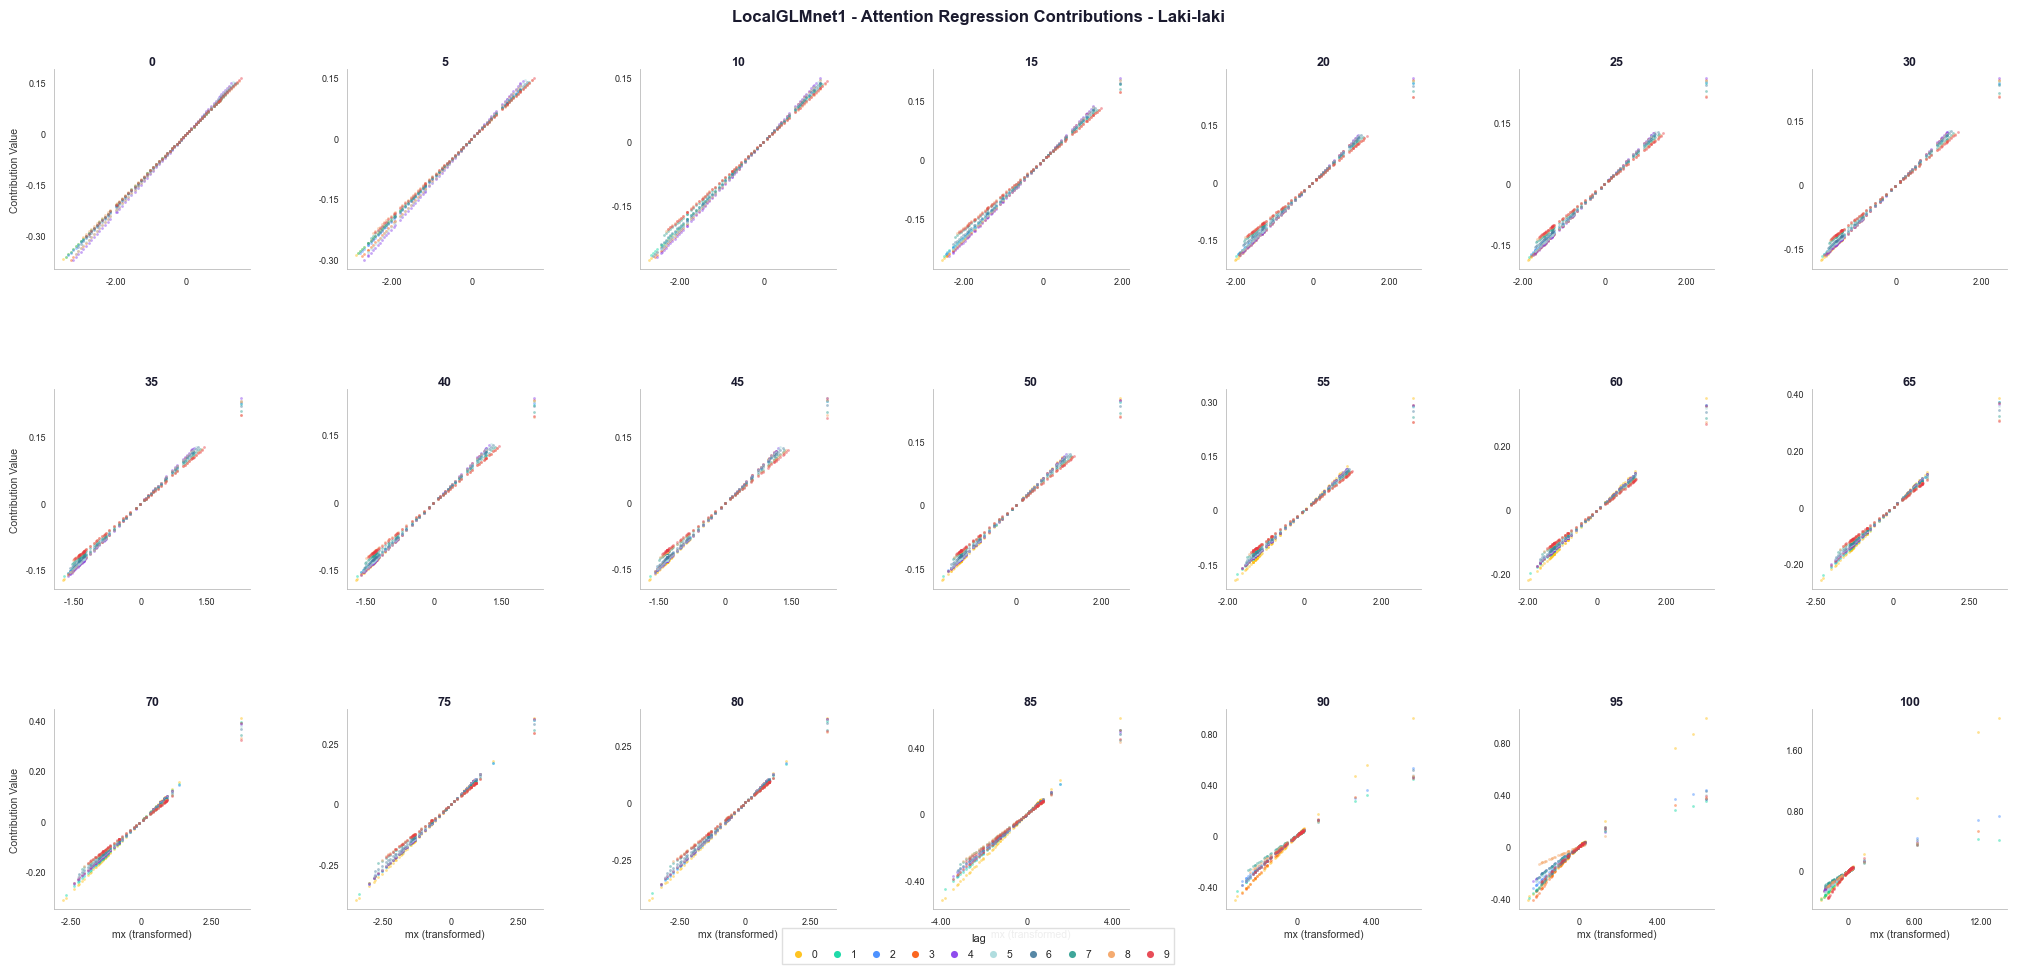

In [129]:
n = 1
assert 0 < n <= 10

reg_att = male_reg_att[(n-1) * 65:n * 65]
reg_att_cont = reg_att * male_mortality

plot_attention_contribution(
    mortality_tensor=male_mortality,
    contribution_tensor=reg_att_cont,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_attention_contribution_laki-laki_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Contributions - Laki-laki"
)

Saved -> plots\mortalitas_vs_attention_contribution_laki-laki_localglmnet5.png


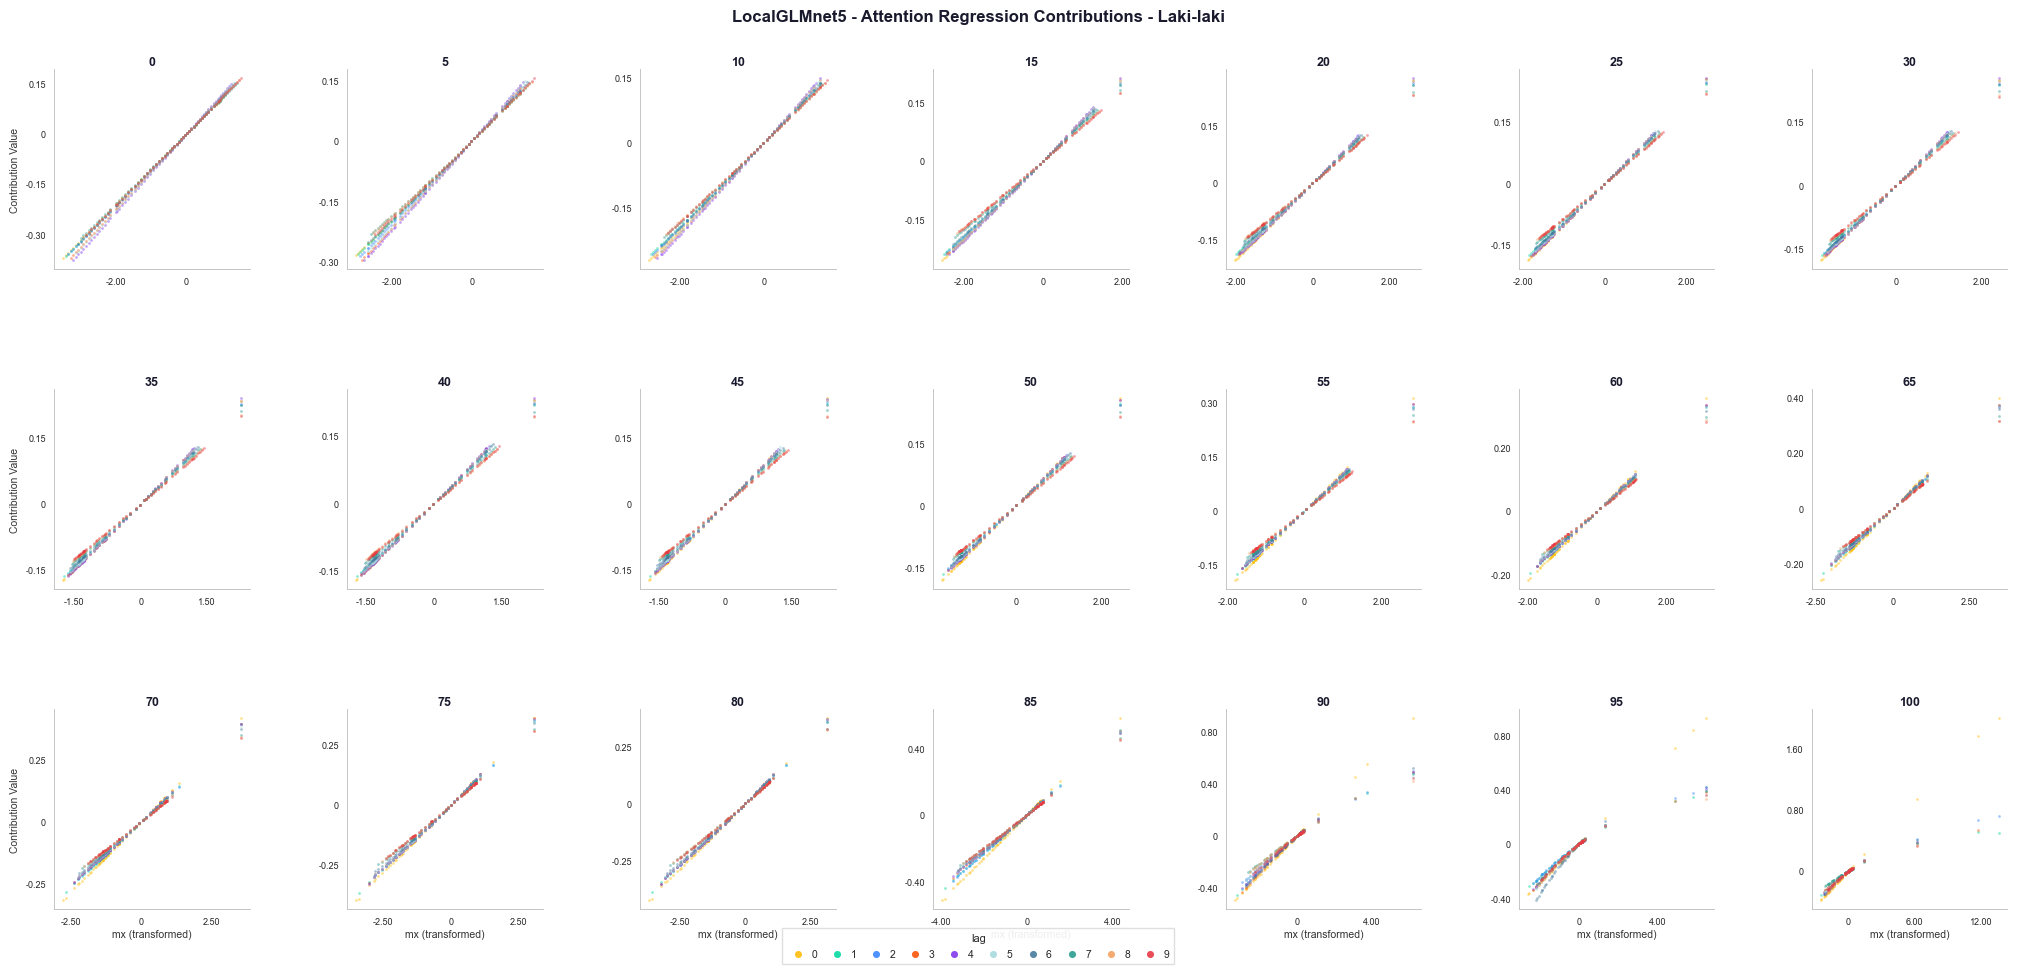

In [130]:
n = 5
assert 0 < n <= 10

reg_att = male_reg_att[(n-1) * 65:n * 65]
reg_att_cont = reg_att * male_mortality

plot_attention_contribution(
    mortality_tensor=male_mortality,
    contribution_tensor=reg_att_cont,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_attention_contribution_laki-laki_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Contributions - Laki-laki"
)

Saved -> plots\mortalitas_vs_attention_contribution_laki-laki_localglmnet10.png


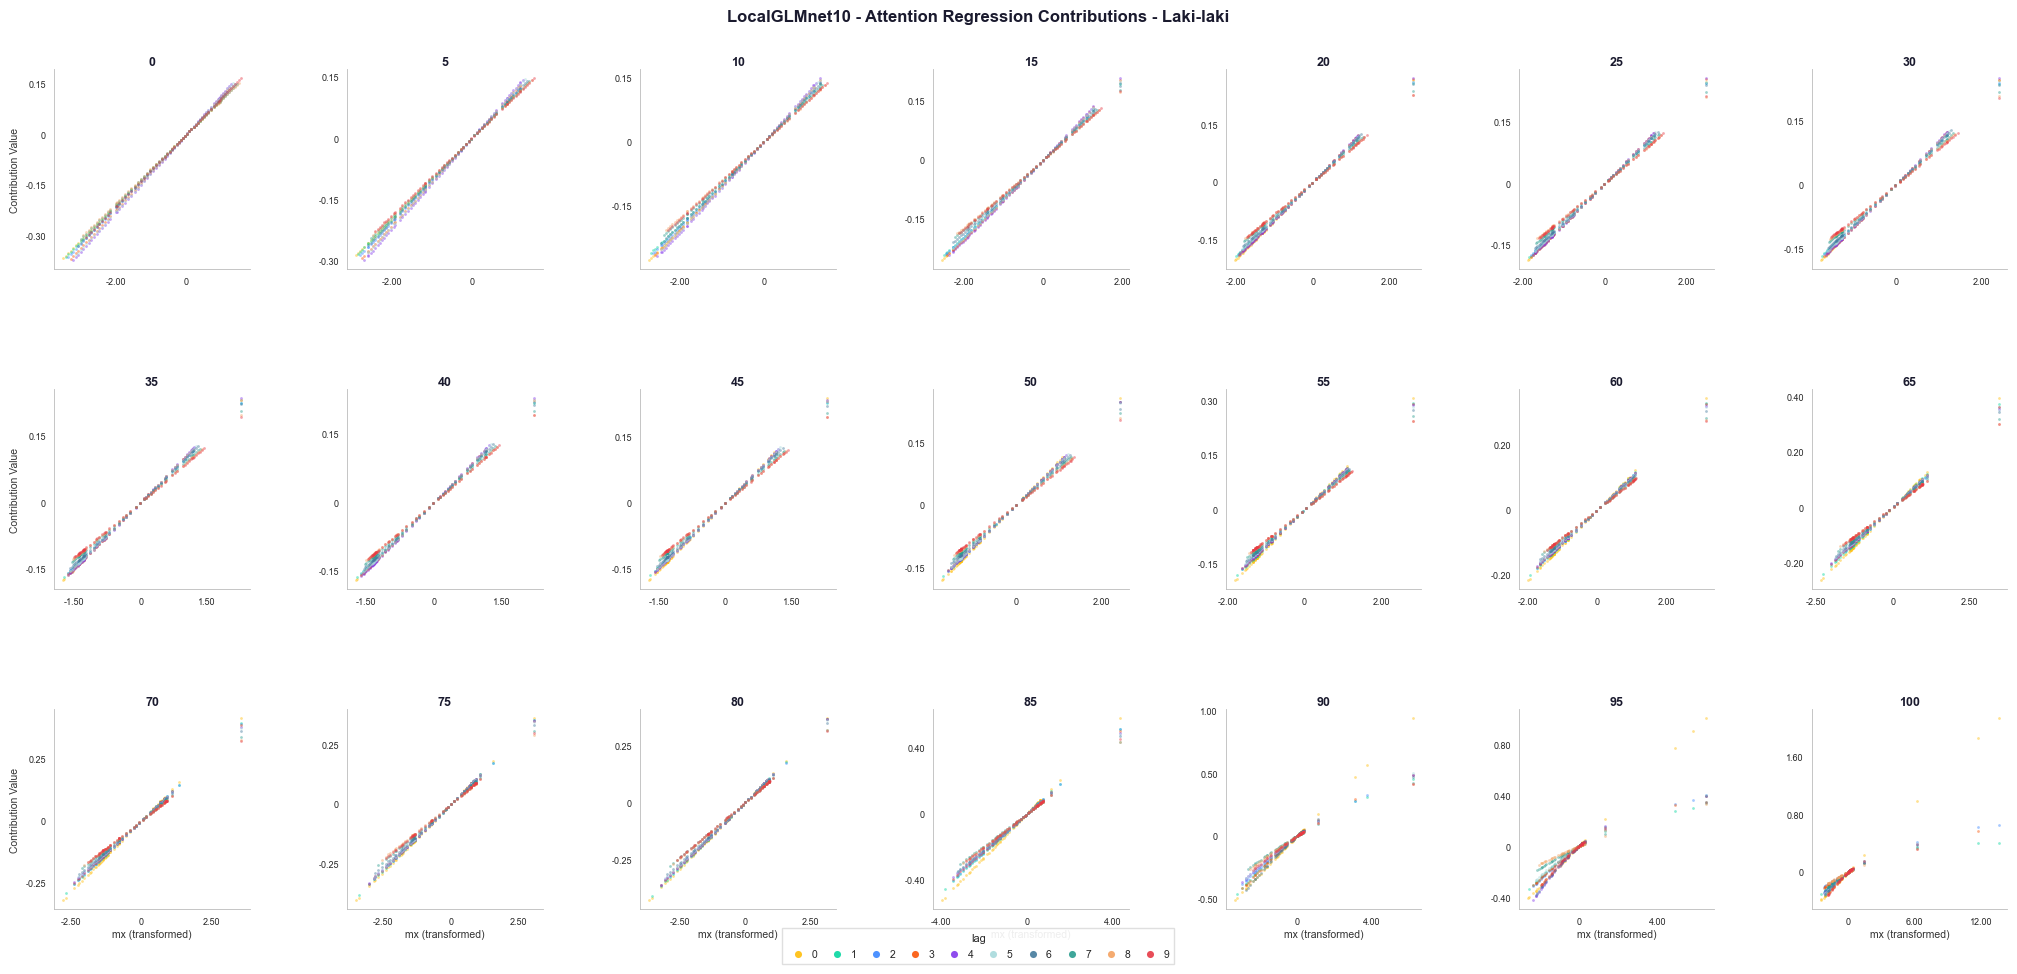

In [131]:
n = 10
assert 0 < n <= 10

reg_att = male_reg_att[(n-1) * 65:n * 65]
reg_att_cont = reg_att * male_mortality

plot_attention_contribution(
    mortality_tensor=male_mortality,
    contribution_tensor=reg_att_cont,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_attention_contribution_laki-laki_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Contributions - Laki-laki"
)

### Perempuan

Saved -> plots\mortalitas_vs_attention_contribution_perempuan_localglmnet1.png


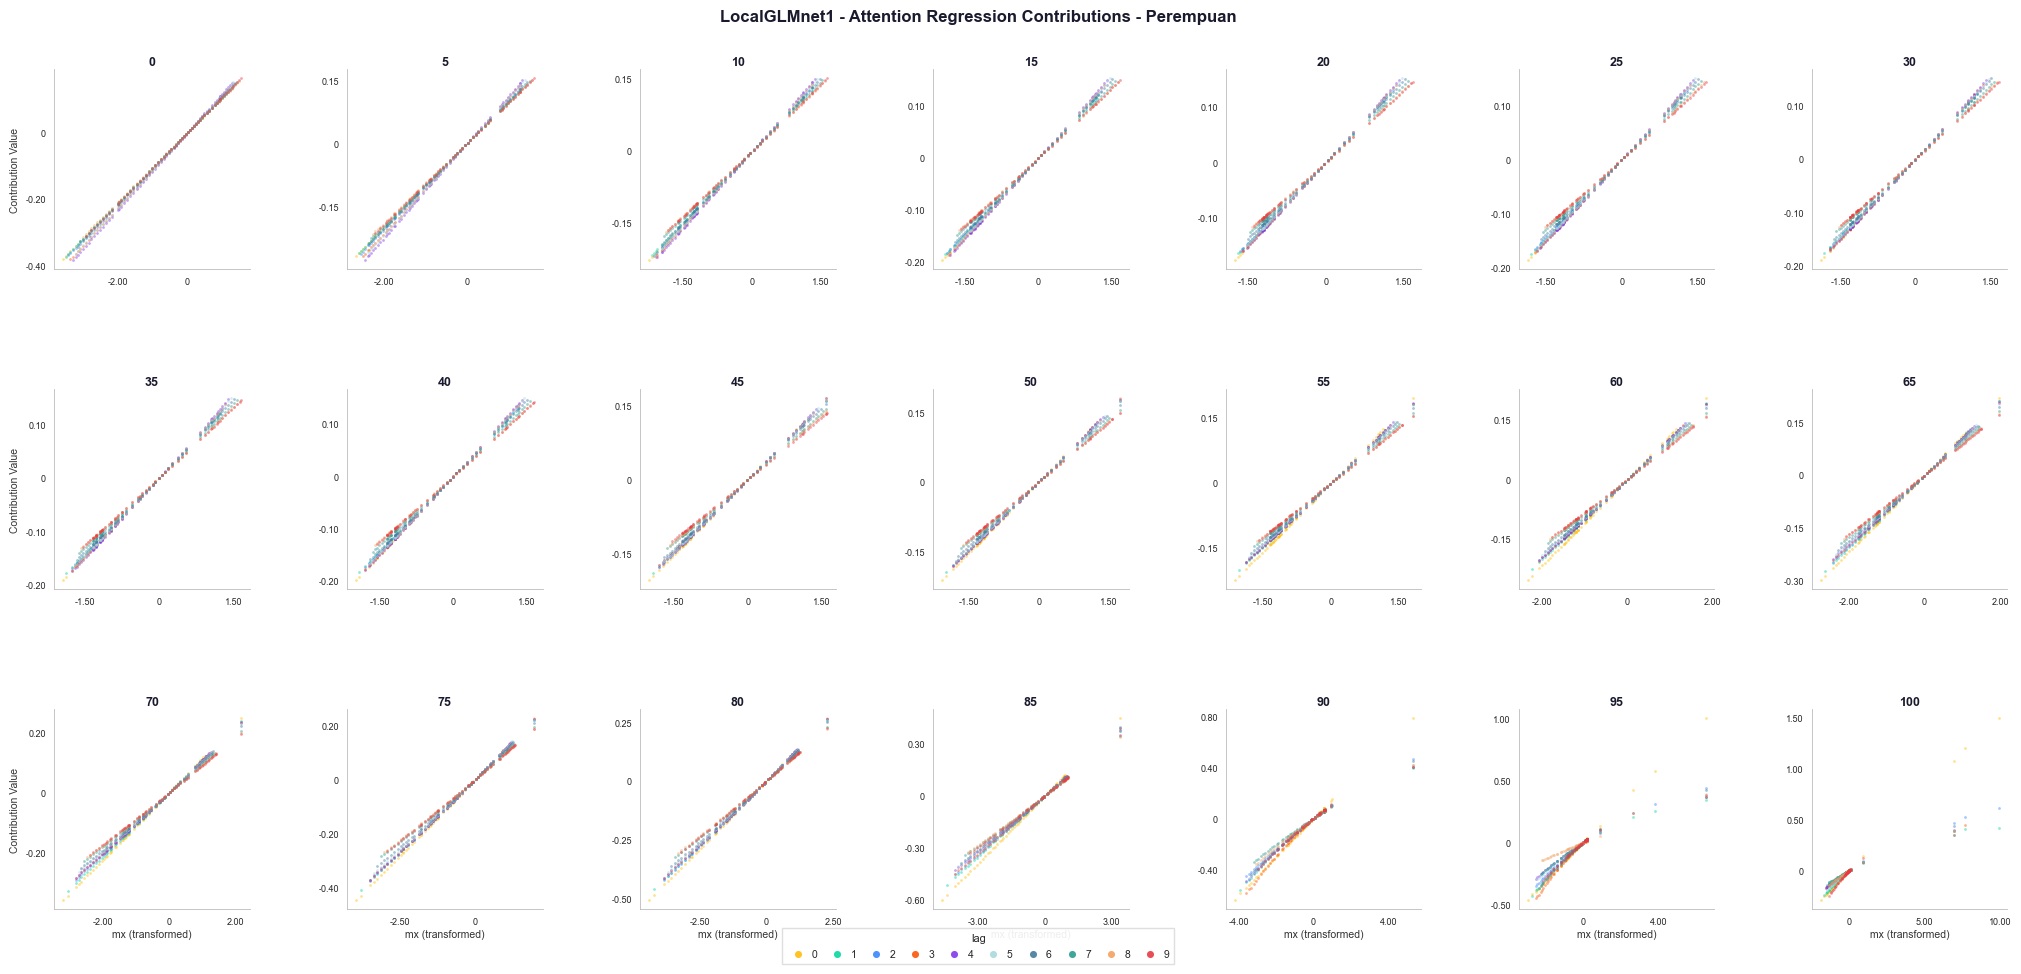

In [132]:
n = 1
assert 0 < n <= 10

reg_att = female_reg_att[(n-1) * 65:n * 65]
reg_att_cont = reg_att * female_mortality

plot_attention_contribution(
    mortality_tensor=female_mortality,
    contribution_tensor=reg_att_cont,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_attention_contribution_perempuan_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Contributions - Perempuan"
)

Saved -> plots\mortalitas_vs_attention_contribution_perempuan_localglmnet5.png


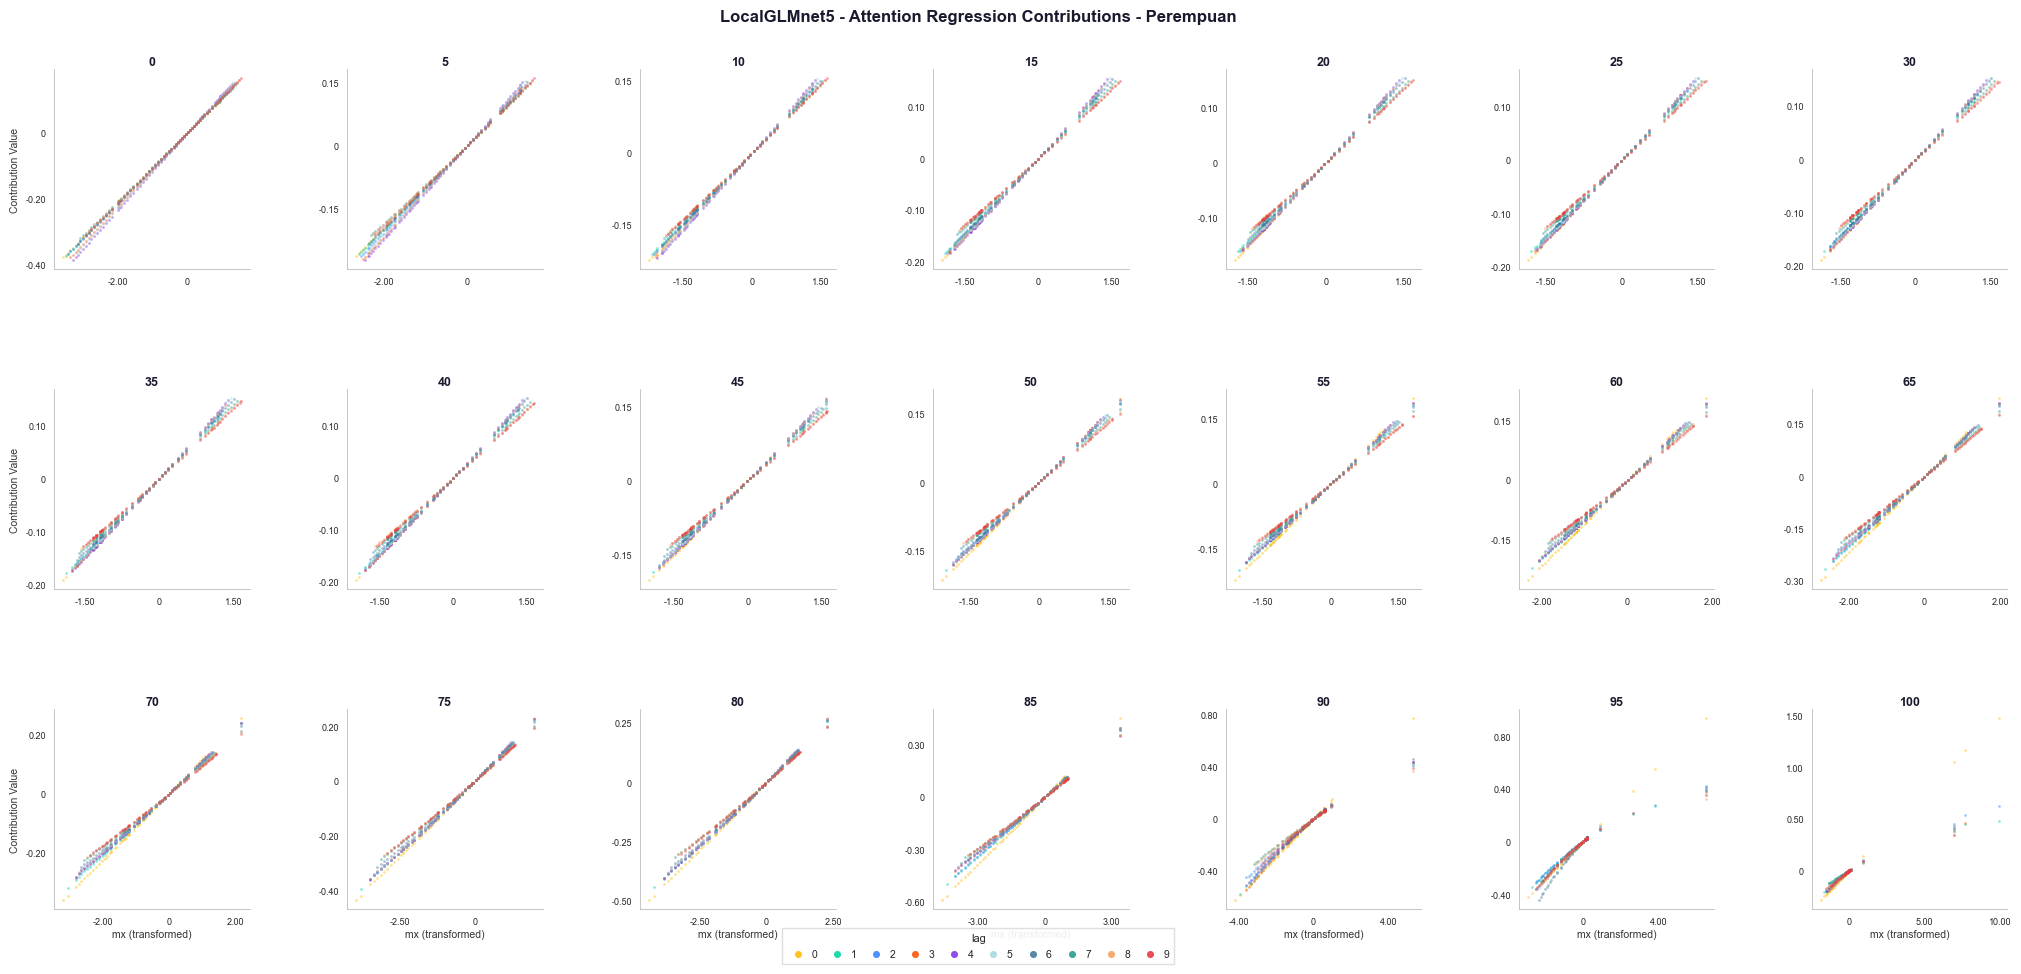

In [133]:
n = 5
assert 0 < n <= 10

reg_att = female_reg_att[(n-1) * 65:n * 65]
reg_att_cont = reg_att * female_mortality

plot_attention_contribution(
    mortality_tensor=female_mortality,
    contribution_tensor=reg_att_cont,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_attention_contribution_perempuan_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Contributions - Perempuan"
)

Saved -> plots\mortalitas_vs_attention_contribution_perempuan_localglmnet10.png


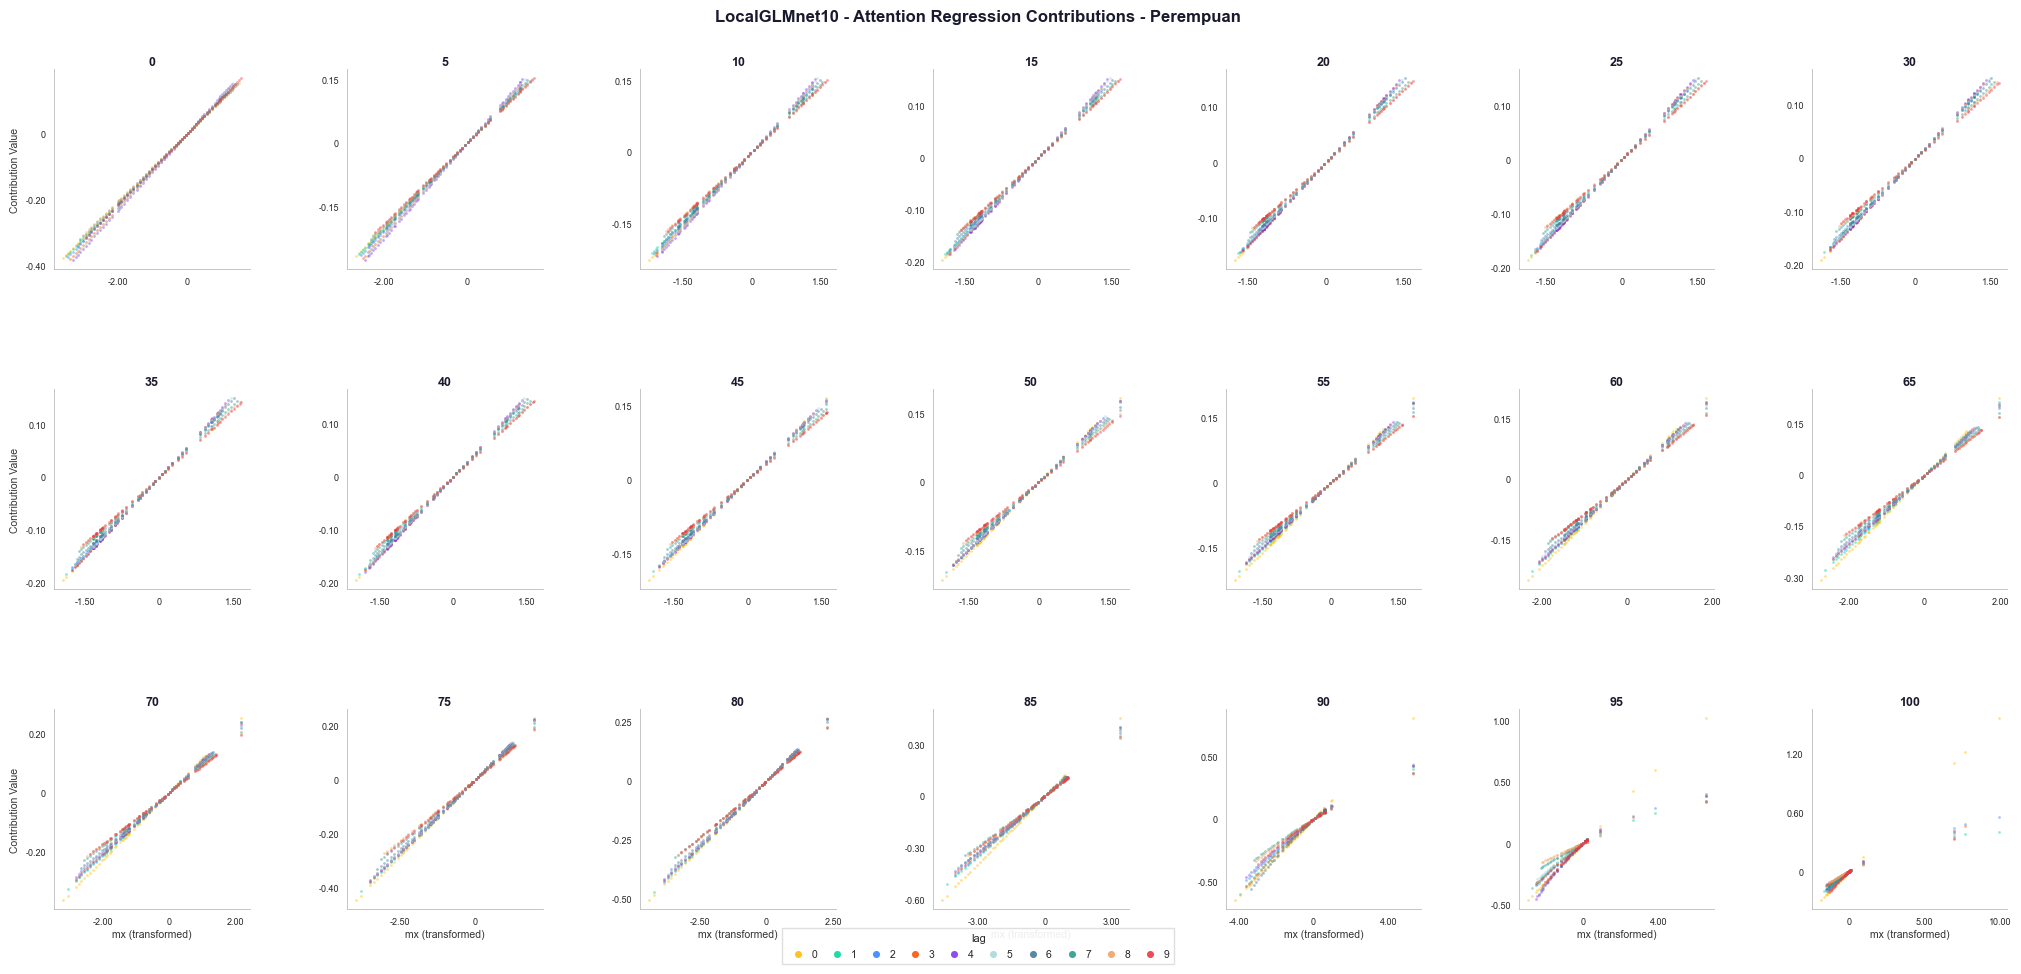

In [134]:
n = 10
assert 0 < n <= 10

reg_att = female_reg_att[(n-1) * 65:n * 65]
reg_att_cont = reg_att * female_mortality

plot_attention_contribution(
    mortality_tensor=female_mortality,
    contribution_tensor=reg_att_cont,
    save_path=DOT_ENV.plots_dir / f"mortalitas_vs_attention_contribution_perempuan_localglmnet{n}.png",
    suptitle=f"LocalGLMnet{n} - Attention Regression Contributions - Perempuan"
)

# Simulasi peramalan mortalitas

In [135]:
# Reset seed state
seed_everything(seed=CONFIG.seed, workers=True)

Seed set to 42


42

In [136]:
n_simulations = 10_000
forecast_horizon = 56

## Laki-laki

In [137]:
male_residuals = None

male_dataloader = DataLoader(train_male_dataset, batch_size=len(train_male_dataset), shuffle=False)
for batch in male_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)
    male_residuals = y - y_pred

print(male_residuals[0])
print(male_residuals.shape)

tensor([[-0.0544, -0.0868, -0.0632, -0.0401, -0.0205, -0.0111, -0.0006,  0.0057,
          0.0071,  0.0084,  0.0085,  0.0112,  0.0140,  0.0201,  0.0324,  0.0495,
          0.0679,  0.0829,  0.0972,  0.1089,  0.1151,  0.1163,  0.1126,  0.1084,
          0.1065,  0.1073,  0.1089,  0.1102,  0.1104,  0.1090,  0.1063,  0.1030,
          0.1005,  0.0988,  0.0972,  0.0963,  0.0954,  0.0943,  0.0930,  0.0916,
          0.0898,  0.0888,  0.0886,  0.0903,  0.0930,  0.0954,  0.0983,  0.1003,
          0.1015,  0.1021,  0.1022,  0.1041,  0.1073,  0.1135,  0.1217,  0.1319,
          0.1419,  0.1501,  0.1553,  0.1575,  0.1574,  0.1571,  0.1589,  0.1647,
          0.1735,  0.1848,  0.1956,  0.2020,  0.2014,  0.1943,  0.1828,  0.1713,
          0.1626,  0.1588,  0.1590,  0.1627,  0.1653,  0.1626,  0.1524,  0.1363,
          0.1198,  0.1065,  0.0990,  0.0992,  0.1092,  0.1296,  0.1566,  0.1792,
          0.1779,  0.1678,  0.1511,  0.1290,  0.1042,  0.0778,  0.0506,  0.0253,
          0.0019, -0.0164, -

In [138]:
from ta_module.utils import recursive_forecast_with_residual_bootstrap

male_simulations_file_path = DOT_ENV.results_dir / "male_mortality_simulations.pt"
if not male_simulations_file_path.exists():
    x, y = test_male_dataset[-1]
    # Dimensi = (10, W)
    x_in = torch.cat([x[1:, :], y])

    # Ubah menjadi dimensi = (1, 10, W)
    x_in = x_in.unsqueeze(0)

    print("=" * 100)
    print(f"Start recursive forecast with residual bootstrap for male mortality:")
    print("=" * 100)
    male_mortality_simulations = recursive_forecast_with_residual_bootstrap(
        model=localglmnet_ensemble,
        x=x_in,
        residuals=male_residuals,
        forecast_horizon=forecast_horizon,
        n_sim=n_simulations,
    )

    print("=" * 100)
    print(f"Simulation done!")
    print("=" * 100)

    # Return data scale to (0, 2)
    male_mortality_simulations = inverse_transform_male_mortality(male_mortality_simulations)

    print(f"Save simulations to {male_simulations_file_path}")
    torch.save(obj=male_mortality_simulations, f=male_simulations_file_path)
    print("All done!")
else:
    male_mortality_simulations = torch.load(male_simulations_file_path, map_location=DEVICE)

print(male_mortality_simulations[0])
print(male_mortality_simulations.shape)

Start recursive forecast with residual bootstrap for male mortality:
Forecasting step 1/56...
Forecasting step 2/56...
Forecasting step 3/56...
Forecasting step 4/56...
Forecasting step 5/56...
Forecasting step 6/56...
Forecasting step 7/56...
Forecasting step 8/56...
Forecasting step 9/56...
Forecasting step 10/56...
Forecasting step 11/56...
Forecasting step 12/56...
Forecasting step 13/56...
Forecasting step 14/56...
Forecasting step 15/56...
Forecasting step 16/56...
Forecasting step 17/56...
Forecasting step 18/56...
Forecasting step 19/56...
Forecasting step 20/56...
Forecasting step 21/56...
Forecasting step 22/56...
Forecasting step 23/56...
Forecasting step 24/56...
Forecasting step 25/56...
Forecasting step 26/56...
Forecasting step 27/56...
Forecasting step 28/56...
Forecasting step 29/56...
Forecasting step 30/56...
Forecasting step 31/56...
Forecasting step 32/56...
Forecasting step 33/56...
Forecasting step 34/56...
Forecasting step 35/56...
Forecasting step 36/56...
Fore

## Perempuan

In [139]:
female_residuals = None

female_dataloader = DataLoader(train_female_dataset, batch_size=len(train_female_dataset), shuffle=False)
for batch in female_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)
    female_residuals = y - y_pred

print(female_residuals[0])
print(female_residuals.shape)

tensor([[-0.0464, -0.0609, -0.0480, -0.0349, -0.0241, -0.0223, -0.0173, -0.0145,
         -0.0155, -0.0153, -0.0158, -0.0136, -0.0119, -0.0112, -0.0105, -0.0084,
         -0.0049, -0.0013,  0.0022,  0.0036,  0.0040,  0.0045,  0.0053,  0.0065,
          0.0071,  0.0084,  0.0090,  0.0096,  0.0101,  0.0112,  0.0122,  0.0128,
          0.0136,  0.0146,  0.0152,  0.0166,  0.0174,  0.0183,  0.0191,  0.0202,
          0.0207,  0.0218,  0.0228,  0.0251,  0.0282,  0.0302,  0.0327,  0.0338,
          0.0339,  0.0327,  0.0303,  0.0287,  0.0264,  0.0253,  0.0239,  0.0234,
          0.0220,  0.0193,  0.0155,  0.0110,  0.0058,  0.0006, -0.0034, -0.0055,
         -0.0071, -0.0072, -0.0062, -0.0054, -0.0047, -0.0046, -0.0055, -0.0053,
         -0.0055, -0.0040, -0.0015,  0.0029,  0.0085,  0.0142,  0.0198,  0.0238,
          0.0270,  0.0300,  0.0330,  0.0365,  0.0433,  0.0545,  0.0698,  0.0828,
          0.0743,  0.0636,  0.0520,  0.0408,  0.0304,  0.0260,  0.0272,  0.0351,
          0.0453,  0.0620,  

In [140]:
female_simulations_file_path = DOT_ENV.results_dir / "female_mortality_simulations.pt"
if not female_simulations_file_path.exists():
    x, y = test_female_dataset[-1]
    # Dimensi = (10, W)
    x_in = torch.cat([x[1:, :], y])

    # Ubah menjadi dimensi = (1, 10, W)
    x_in = x_in.unsqueeze(0)

    print("=" * 100)
    print(f"Start recursive forecast with residual bootstrap for female mortality:")
    print("=" * 100)
    female_mortality_simulations = recursive_forecast_with_residual_bootstrap(
        model=localglmnet_ensemble,
        x=x_in,
        residuals=female_residuals,
        forecast_horizon=forecast_horizon,
        n_sim=n_simulations,
    )
    print("=" * 100)
    print(f"Simulation done!")
    print("=" * 100)

    # Return data scale to (0, 2)
    female_mortality_simulations = inverse_transform_female_mortality(female_mortality_simulations)

    print(f"Save simulations to {female_simulations_file_path}")
    torch.save(obj=female_mortality_simulations, f=female_simulations_file_path)
    print("All done!")
else:
    female_mortality_simulations = torch.load(female_simulations_file_path, map_location=DEVICE)

print(female_mortality_simulations[0])
print(female_mortality_simulations.shape)

Start recursive forecast with residual bootstrap for female mortality:
Forecasting step 1/56...
Forecasting step 2/56...
Forecasting step 3/56...
Forecasting step 4/56...
Forecasting step 5/56...
Forecasting step 6/56...
Forecasting step 7/56...
Forecasting step 8/56...
Forecasting step 9/56...
Forecasting step 10/56...
Forecasting step 11/56...
Forecasting step 12/56...
Forecasting step 13/56...
Forecasting step 14/56...
Forecasting step 15/56...
Forecasting step 16/56...
Forecasting step 17/56...
Forecasting step 18/56...
Forecasting step 19/56...
Forecasting step 20/56...
Forecasting step 21/56...
Forecasting step 22/56...
Forecasting step 23/56...
Forecasting step 24/56...
Forecasting step 25/56...
Forecasting step 26/56...
Forecasting step 27/56...
Forecasting step 28/56...
Forecasting step 29/56...
Forecasting step 30/56...
Forecasting step 31/56...
Forecasting step 32/56...
Forecasting step 33/56...
Forecasting step 34/56...
Forecasting step 35/56...
Forecasting step 36/56...
Fo

# Pembuatan life table

## Stokastik (simulasi peramalan)

### Laki-laki

In [141]:
male_1qx = (2.0 * male_mortality_simulations) / (2.0 + male_mortality_simulations)
male_1px = 1.0 - male_1qx

In [142]:
from ta_module.actuarial import compute_ex, compute_kpx_table_from_xstart_dynamic

male_e45 = []
male_kpx_45_100 = []
for i in range(n_simulations):
    kpx_45_100 = compute_kpx_table_from_xstart_dynamic(
        p=male_1px[i],
        x_start=45,
        max_k=56,
        t0=0
    )

    male_kpx_45_100.append(kpx_45_100)
    kp45 = kpx_45_100[0]

    e45 = compute_ex(kp45)
    male_e45.append(e45)

male_e45 = torch.stack(male_e45)
male_kpx_45_100 = torch.stack(male_kpx_45_100)

In [143]:
_, male_e45_sorted_indices = torch.sort(male_e45, descending=False)

male_kpx_45_100_min = male_kpx_45_100[male_e45_sorted_indices[int(0.025 * n_simulations)]]
male_kpx_45_100_med = male_kpx_45_100[male_e45_sorted_indices[int(0.5 * n_simulations)]]
male_kpx_45_100_max = male_kpx_45_100[male_e45_sorted_indices[int(0.975 * n_simulations)]]

male_kqx_45_100_min = 1.0 - male_kpx_45_100_min
male_kqx_45_100_med = 1.0 - male_kpx_45_100_med
male_kqx_45_100_max = 1.0 - male_kpx_45_100_max

### Perempuan

In [144]:
female_1qx = (2.0 * female_mortality_simulations) / (2.0 + female_mortality_simulations)
female_1px = 1.0 - female_1qx

In [145]:
from ta_module.actuarial import compute_ex, compute_kpx_table_from_xstart_dynamic

female_e45 = []
female_kpx_45_100 = []
for i in range(n_simulations):
    kpx_45_100 = compute_kpx_table_from_xstart_dynamic(
        p=female_1px[i],
        x_start=45,
        max_k=56,
        t0=0
    )
    female_kpx_45_100.append(kpx_45_100)
    kp45 = kpx_45_100[0]

    e45 = compute_ex(kp45)
    female_e45.append(e45)

female_e45 = torch.stack(female_e45)
female_kpx_45_100 = torch.stack(female_kpx_45_100)

In [146]:
_, female_e45_sorted_indices = torch.sort(female_e45, descending=False)

female_kpx_45_100_min = male_kpx_45_100[female_e45_sorted_indices[int(0.025 * n_simulations)]]
female_kpx_45_100_med = male_kpx_45_100[female_e45_sorted_indices[int(0.5 * n_simulations)]]
female_kpx_45_100_max = male_kpx_45_100[female_e45_sorted_indices[int(0.975 * n_simulations)]]

female_kqx_45_100_min = 1.0 - female_kpx_45_100_min
female_kqx_45_100_med = 1.0 - female_kpx_45_100_med
female_kqx_45_100_max = 1.0 - female_kpx_45_100_max

### Plot simulasi

In [147]:
female_mortality_simulations[female_e45_sorted_indices[int(0.025 * n_simulations)], :, 0]

tensor([1.2616e-02, 1.1913e-02, 1.3031e-02, 1.0395e-02, 1.0155e-02, 9.4494e-03,
        8.8604e-03, 8.3891e-03, 7.7654e-03, 7.2519e-03, 6.5491e-03, 6.2943e-03,
        5.6920e-03, 5.3290e-03, 4.8478e-03, 4.4416e-03, 4.1101e-03, 3.7828e-03,
        3.5697e-03, 3.1911e-03, 2.9932e-03, 2.6306e-03, 2.5004e-03, 2.2677e-03,
        2.0531e-03, 1.8533e-03, 1.7272e-03, 1.5635e-03, 1.4255e-03, 1.3344e-03,
        1.1570e-03, 1.0556e-03, 9.6602e-04, 8.6516e-04, 7.7876e-04, 7.0495e-04,
        6.5470e-04, 5.5748e-04, 5.1172e-04, 4.4157e-04, 4.0005e-04, 3.6234e-04,
        3.2131e-04, 2.7463e-04, 2.5295e-04, 2.1984e-04, 1.9619e-04, 1.7372e-04,
        1.5057e-04, 1.3671e-04, 1.1719e-04, 1.0352e-04, 8.7566e-05, 7.7970e-05,
        6.8126e-05, 5.7643e-05], device='cuda:0')

In [148]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.lines import Line2D

mortality_simulations = [
    female_mortality_simulations,
    male_mortality_simulations
]

mortality_data = [
    M_female,
    M_male
]

GENDER_LABEL = {0: "Perempuan", 1: "Laki-laki"}


def plot_mortality_fan(
    age: int,
    gender: int,
    save_path: str,
    start_year: int = 2025,
    sim_alpha: float = 0.018,
    sim_color: str = "#4A90D9",
    band_colors: tuple = ("#E84545", "#F5A623", "#27AE60"),
    figsize: tuple = (13, 6),
    log_scale: bool = False,
    dpi: int = 150,
) -> None:
    assert gender in (0, 1)

    # Data
    sims_data = mortality_simulations[gender].cpu().numpy()  # (n_sim, n_steps, n_ages)
    before_sims_data = mortality_data[gender].cpu().numpy()  # (n_years_hist, n_ages) FIX: index by gender, bukan age

    n_sim, n_steps, n_ages = sims_data.shape
    assert 0 <= age < n_ages, f"age harus di rentang [0, {n_ages - 1}]"

    before_sim_years = np.arange(1950, 2025)  # 1950-2024  (75 titik)
    fore_years = np.arange(start_year, start_year + n_steps)
    data = sims_data[:, :, age]  # (n_sim, n_steps)
    hist = before_sims_data[:, age]  # (75,)

    # Persentil
    pct_idx = female_e45_sorted_indices if gender == 0 else male_e45_sorted_indices
    pct_lo = data[pct_idx[int(0.025 * n_sim)]]
    pct_med = data[pct_idx[int(0.5 * n_sim)]]
    pct_hi = data[pct_idx[int(0.975 * n_sim)]]

    # Styling WHITE - theme
    sns.set_theme(style="whitegrid", font="serif")
    plt.rcParams.update(
        {
            "axes.facecolor"  : "#FAFAFA",
            "figure.facecolor": "#FFFFFF",
            "grid.color"      : "#E0E0E0",
            "grid.linewidth"  : 0.6,
            "axes.edgecolor"  : "#CCCCCC",
            "axes.labelcolor" : "#333333",
            "xtick.color"     : "#555555",
            "ytick.color"     : "#555555",
            "xtick.labelsize" : 10,
            "ytick.labelsize" : 10,
            "axes.labelsize"  : 12,
            "text.color"      : "#222222",
            "font.family"     : "serif",
        }
    )

    fig, ax = plt.subplots(figsize=figsize)

    # Garis vertikal pemisah historis / proyeksi
    ax.axvline(2024.5, color="#AAAAAA", linewidth=1.2, linestyle=":", zorder=2)
    ax.text(
        2024.5 - 0.8, 0, "historis", ha="right", va="bottom",
        fontsize=8, color="#888888", style="italic",
        transform=ax.get_xaxis_transform()
        )
    ax.text(
        2024.5 + 0.8, 0, "proyeksi", ha="left", va="bottom",
        fontsize=8, color="#888888", style="italic",
        transform=ax.get_xaxis_transform()
        )

    # Data historis
    ax.plot(
        before_sim_years, hist,
        color="#333333", linewidth=1.8, zorder=4,
        label="Historis (1950 - 2024)",
    )

    # Fan simulasi
    for i in range(n_sim):
        ax.plot(
            fore_years, data[i],
            color=sim_color, alpha=sim_alpha, linewidth=0.4,
            rasterized=True,
        )

    ax.fill_between(
        fore_years, pct_lo, pct_hi,
        color=sim_color, alpha=0.10, linewidth=0,
    )

    # Garis persentil
    band_styles = [
        dict(linestyle="--", linewidth=1.8, alpha=0.90),
        dict(linestyle="-", linewidth=2.6, alpha=1.00),
        dict(linestyle="--", linewidth=1.8, alpha=0.90),
    ]
    for arr, color, style, label in zip(
            [pct_lo, pct_med, pct_hi],
            band_colors, band_styles,
            ["min (P2.5)", "med (P50)", "max (P97.5)"],
    ):
        ax.plot(fore_years, arr, color=color, label=label, zorder=5, **style)
        ax.plot(fore_years[-1], arr[-1], "o", color=color, markersize=5, zorder=6)
        ax.annotate(
            f"  {arr[-1]:.4f}",
            xy=(fore_years[-1], arr[-1]),
            fontsize=8.5, color=color, va="center", fontweight="bold",
        )

    # stetika
    ax.set_title(
        f"Simulasi Peramalan Mortalitas  -  Usia {age}  -  {GENDER_LABEL[gender]}",
        fontsize=14, fontweight="bold", color="#111111",
        pad=14, loc="center",
    )
    ax.set_xlabel("Tahun", labelpad=10)
    ax.set_ylabel("Mortality Rate", labelpad=10)

    # Skala Y otomatis dari seluruh data
    all_vals = np.concatenate([hist, pct_lo, pct_med, pct_hi])
    y_min, y_max = all_vals.min(), all_vals.max()
    pad_y = (y_max - y_min) * 0.05
    ax.set_ylim(max(0, y_min - pad_y), y_max + pad_y)

    if log_scale:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_ylim(max(1e-6, y_min * 0.9), y_max * 1.1)

    ax.set_xlim(before_sim_years[0] - 0.5, fore_years[-1] + 3)

    # Highlight dekade
    for yr in range(1950, start_year + n_steps + 1, 10):
        ax.axvline(yr, color="#000000", linewidth=0.3, alpha=0.12, zorder=1)

    # Legenda
    custom_handles = [
        Line2D(
            [0], [0], color="#333333", linewidth=1.8,
            label="Historis (1950 - 2024)"
        ),
        Line2D(
            [0], [0], color=sim_color, alpha=0.5, linewidth=1.2,
            label=f"Simulasi individual (n={n_sim:,})"
        ),
        Line2D(
            [0], [0], color=band_colors[0], linewidth=1.8,
            linestyle="--", label="min (P2.5)"
        ),
        Line2D(
            [0], [0], color=band_colors[1], linewidth=2.6,
            label="med (P50)"
        ),
        Line2D(
            [0], [0], color=band_colors[2], linewidth=1.8,
            linestyle="--", label="max (P97.5)"
        ),
    ]

    leg = ax.legend(
        handles=custom_handles,
        loc="upper left",
        fontsize=9.5,
        framealpha=0.7,
        facecolor="#FFFFFF",
        edgecolor="#CCCCCC",
        handlelength=2.2,
    )
    for text in leg.get_texts():
        text.set_color("#222222")

    fig.text(
        0.99, 0.01,
        f"Proyeksi {start_year} - {start_year + n_steps - 1}  |  {n_sim:,} simulasi",
        ha="right", va="bottom", fontsize=7.5, color="#AAAAAA", style="italic",
    )

    plt.tight_layout(pad=1.5)
    fig.savefig(
        save_path, dpi=dpi, bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    print(f"Plot disimpan ke: {save_path}")
    plt.show()

Plot disimpan ke: plots\simulasi_mortalitas_perempuan_usia_0.png


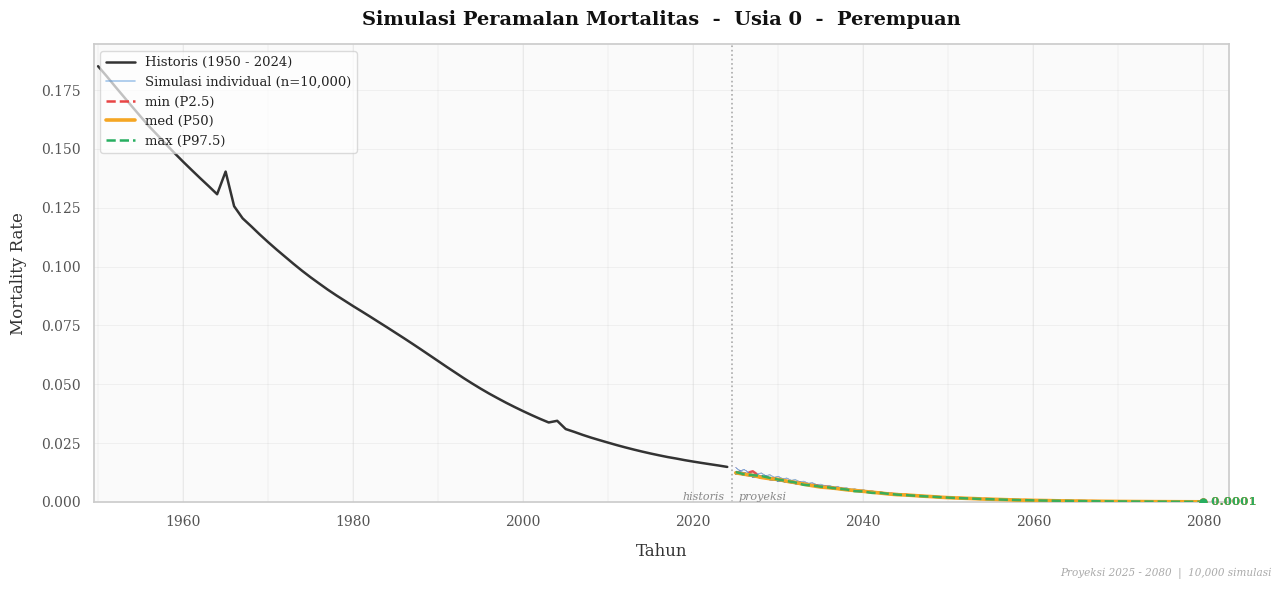

In [149]:
plot_mortality_fan(
    age=0,
    gender=0,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_perempuan_usia_0.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_perempuan_usia_25.png


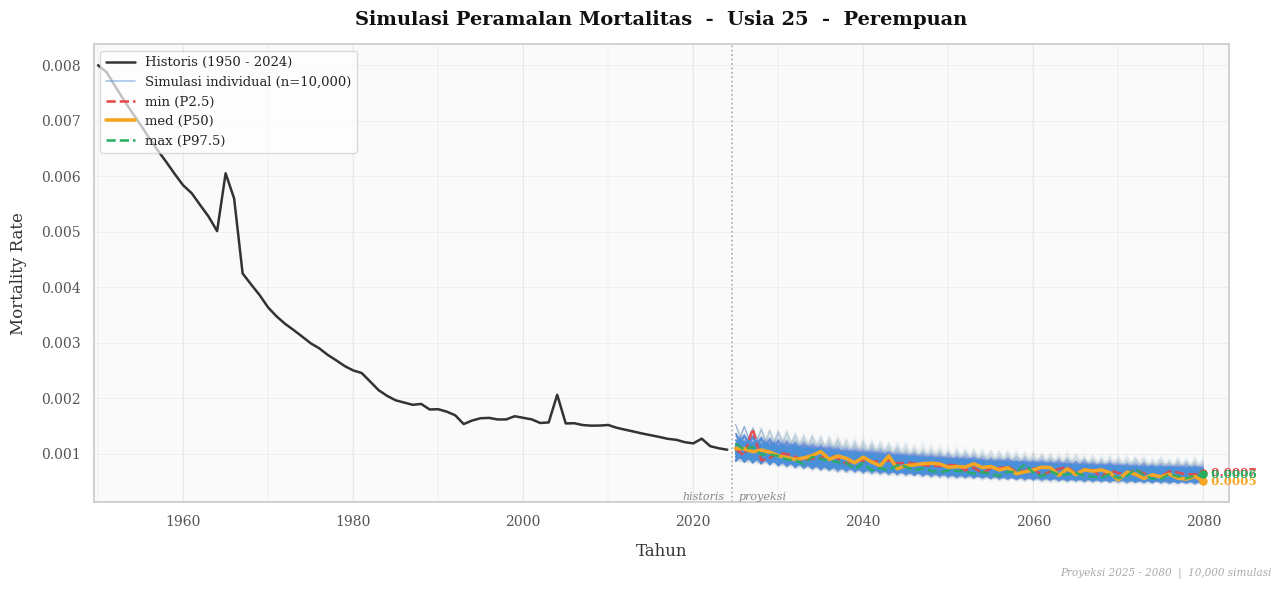

In [150]:
plot_mortality_fan(
    age=25,
    gender=0,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_perempuan_usia_25.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_perempuan_usia_50.png


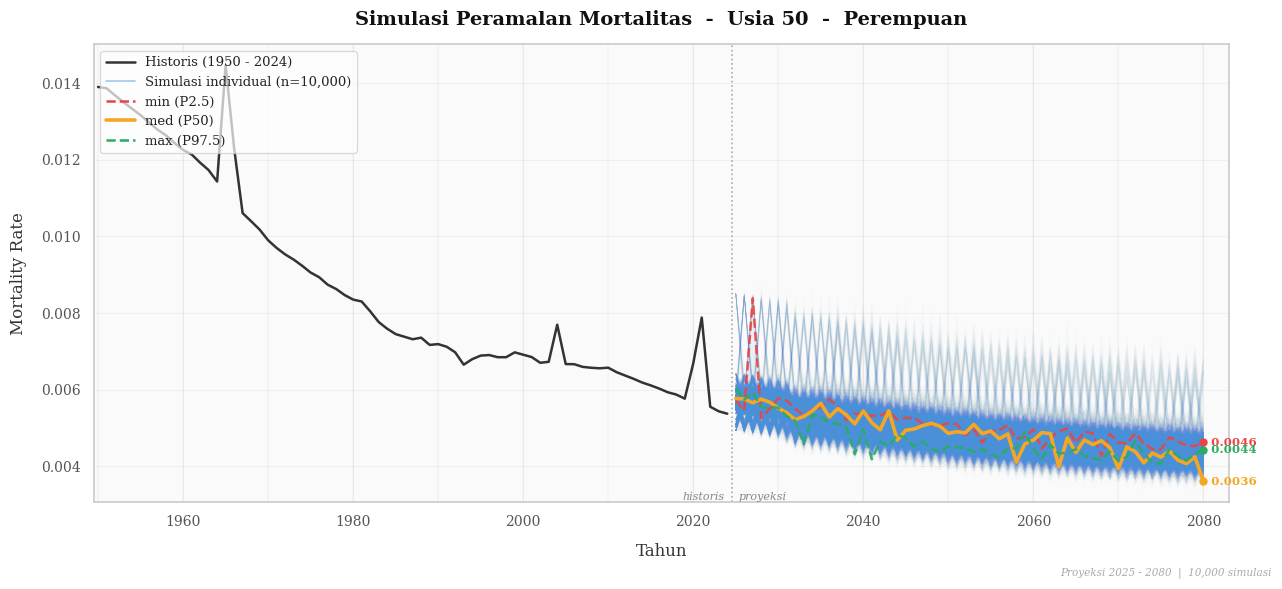

In [151]:
plot_mortality_fan(
    age=50,
    gender=0,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_perempuan_usia_50.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_perempuan_usia_75.png


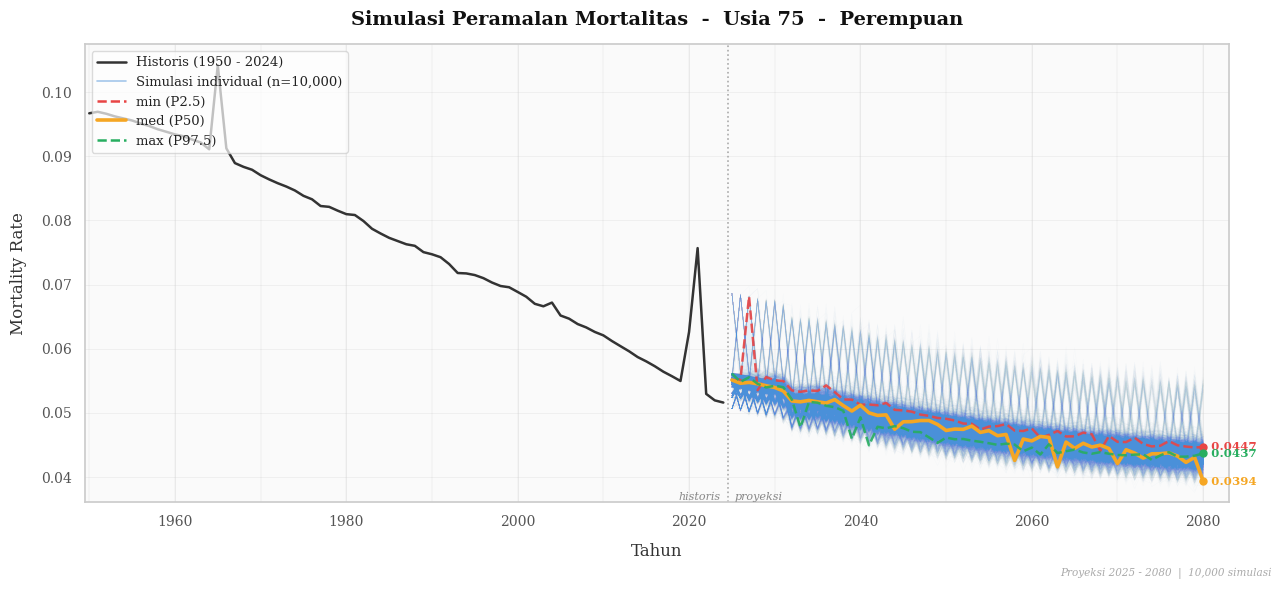

In [152]:
plot_mortality_fan(
    age=75,
    gender=0,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_perempuan_usia_75.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_perempuan_usia_100.png


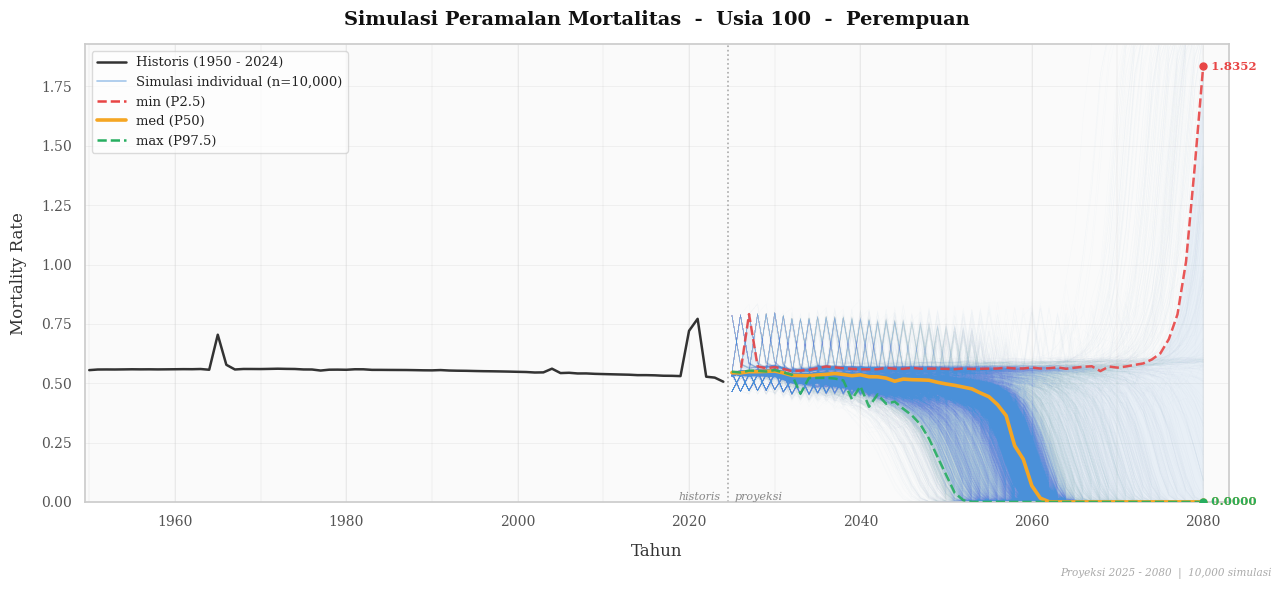

In [153]:
plot_mortality_fan(
    age=100,
    gender=0,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_perempuan_usia_100.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_laki-laki_usia_0.png


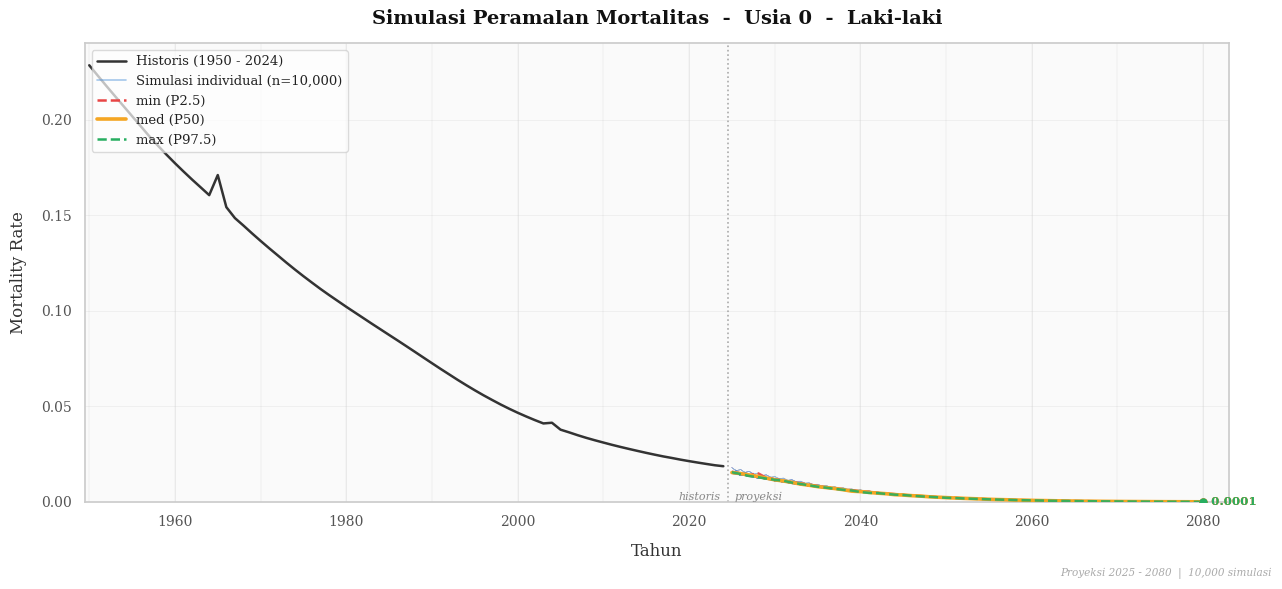

In [154]:
plot_mortality_fan(
    age=0,
    gender=1,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_laki-laki_usia_0.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_laki-laki_usia_25.png


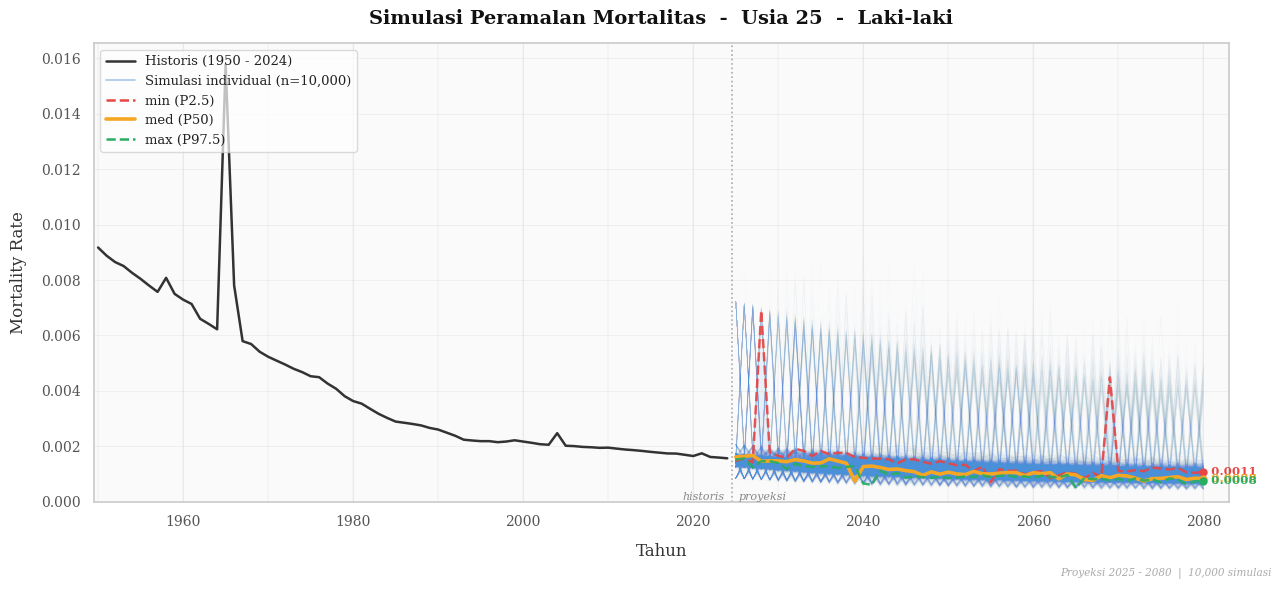

In [155]:
plot_mortality_fan(
    age=25,
    gender=1,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_laki-laki_usia_25.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_laki-laki_usia_50.png


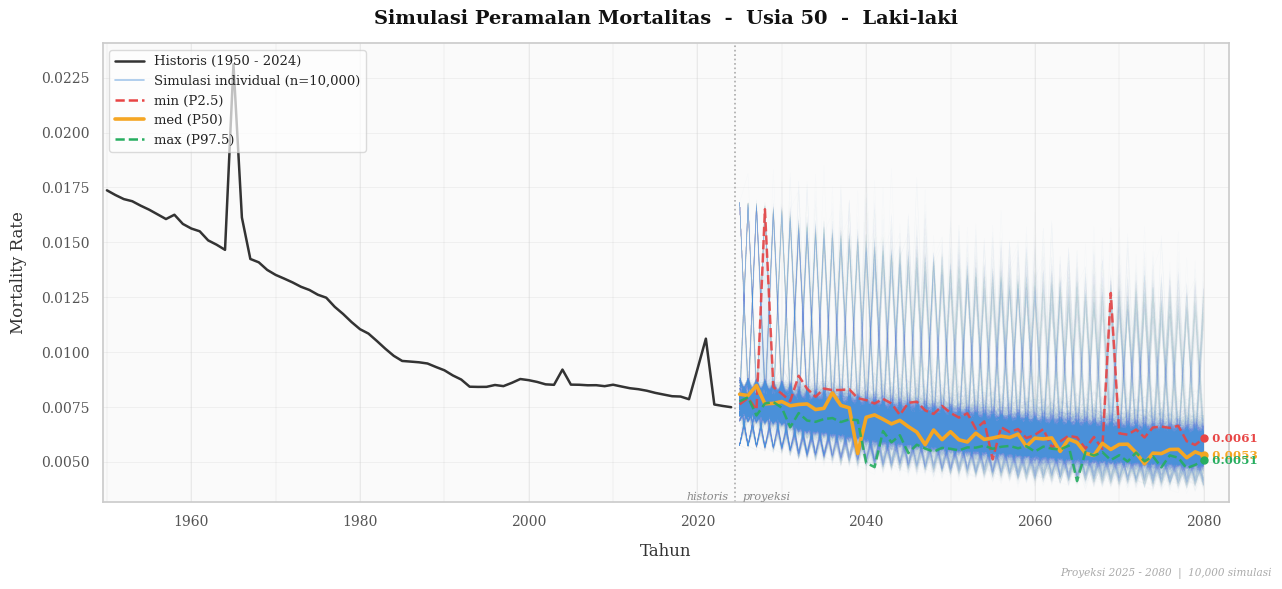

In [156]:
plot_mortality_fan(
    age=50,
    gender=1,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_laki-laki_usia_50.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_laki-laki_usia_75.png


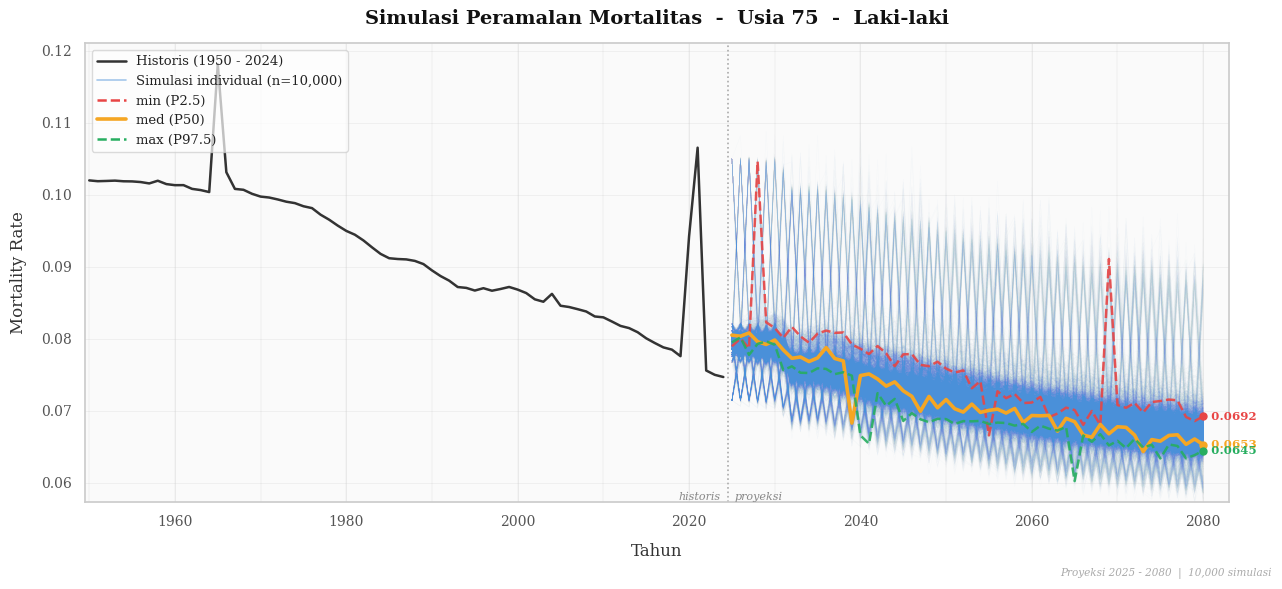

In [157]:
plot_mortality_fan(
    age=75,
    gender=1,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_laki-laki_usia_75.png"
)

Plot disimpan ke: plots\simulasi_mortalitas_laki-laki_usia_100.png


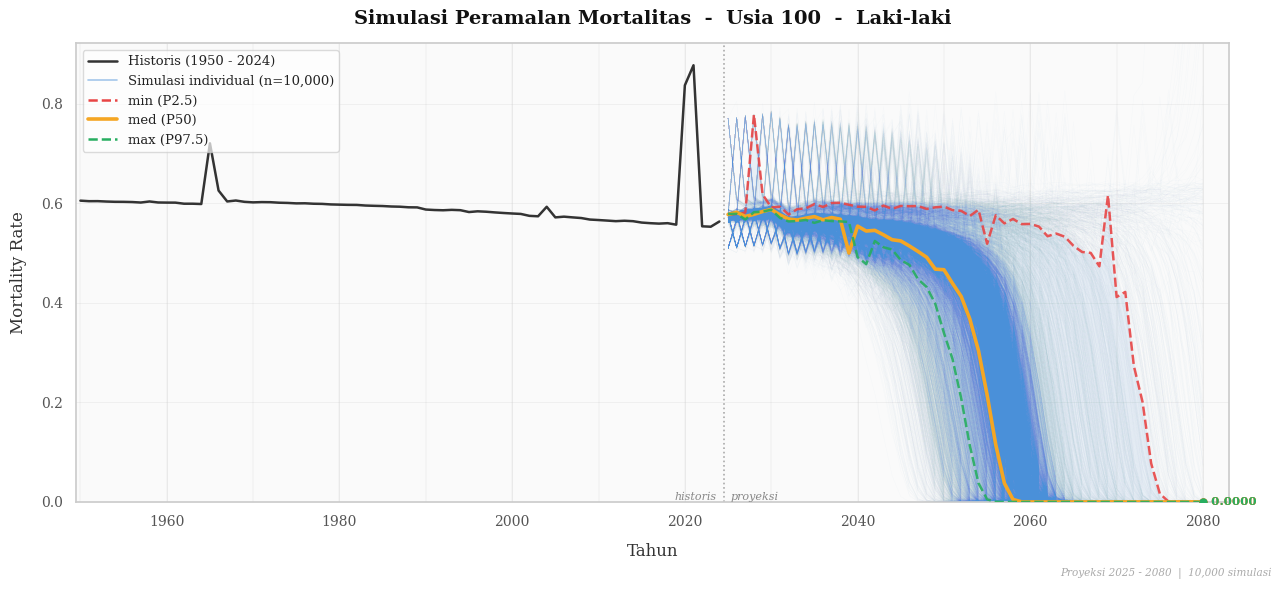

In [158]:
plot_mortality_fan(
    age=100,
    gender=1,
    save_path=DOT_ENV.plots_dir / "simulasi_mortalitas_laki-laki_usia_100.png"
)

### Plot rekursif tanpa residual bootstrap

In [159]:
from ta_module.utils import recursive_forecast

x, y = test_male_dataset[-1]
x_in = torch.cat([x[1:, :], y])
x_in = x_in.unsqueeze(0)

male_recursive_forecast = recursive_forecast(
    model=localglmnet_ensemble,
    x=x_in,
    forecast_horizon=forecast_horizon,
    n_sim=1
)
male_recursive_forecast = inverse_transform_male_mortality(male_recursive_forecast)

In [160]:
x, y = test_female_dataset[-1]
x_in = torch.cat([x[1:, :], y])
x_in = x_in.unsqueeze(0)

female_recursive_forecast = recursive_forecast(
    model=localglmnet_ensemble,
    x=x_in,
    forecast_horizon=forecast_horizon,
    n_sim=1
)
female_recursive_forecast = inverse_transform_female_mortality(female_recursive_forecast)

In [161]:
sims_data = [
    female_recursive_forecast,
    male_recursive_forecast,
]


def plot_mortality_single(
    age: int,
    gender: int,
    save_path: str,
    sim_index: int = 0,
    start_year: int = 2025,
    figsize: tuple = (13, 6),
    log_scale: bool = False,
    dpi: int = 150,
) -> None:
    assert gender in (0, 1)

    sims_data = mortality_simulations[gender].cpu().numpy()
    before_sims_data = mortality_data[gender].cpu().numpy()

    n_sim, n_steps, n_ages = sims_data.shape
    assert 0 <= age < n_ages
    assert 0 <= sim_index < n_sim, f"sim_index harus di rentang [0, {n_sim - 1}]"

    before_sim_years = np.arange(1950, 2025)
    fore_years = np.arange(start_year, start_year + n_steps)
    hist = before_sims_data[:, age]
    sim = sims_data[sim_index, :, age]

    # Styling
    sns.set_theme(style="whitegrid", font="serif")
    plt.rcParams.update(
        {
            "axes.facecolor"  : "#FAFAFA",
            "figure.facecolor": "#FFFFFF",
            "grid.color"      : "#E0E0E0",
            "grid.linewidth"  : 0.6,
            "axes.edgecolor"  : "#CCCCCC",
            "axes.labelcolor" : "#333333",
            "xtick.color"     : "#555555",
            "ytick.color"     : "#555555",
            "xtick.labelsize" : 10,
            "ytick.labelsize" : 10,
            "axes.labelsize"  : 12,
            "text.color"      : "#222222",
            "font.family"     : "serif",
        }
    )

    fig, ax = plt.subplots(figsize=figsize)

    # Pemisah historis / proyeksi
    ax.axvline(2024.5, color="#AAAAAA", linewidth=1.2, linestyle=":", zorder=2)
    ax.text(
        2024.5 - 0.8, 0, "historis", ha="right", va="bottom",
        fontsize=8, color="#888888", style="italic",
        transform=ax.get_xaxis_transform()
        )
    ax.text(
        2024.5 + 0.8, 0, "proyeksi", ha="left", va="bottom",
        fontsize=8, color="#888888", style="italic",
        transform=ax.get_xaxis_transform()
        )

    # Garis historis
    ax.plot(
        before_sim_years, hist,
        color="#333333", linewidth=1.8, zorder=4,
        label="Historis (1950 - 2024)"
    )

    # Satu garis simulasi
    ax.plot(
        fore_years, sim,
        color="#4A90D9", linewidth=1.8, zorder=4,
        label=f"Peramalan Rekursif"
    )

    # Titik sambung historis - simulasi
    ax.plot(2024, hist[-1], "o", color="#333333", markersize=5, zorder=5)
    ax.plot(start_year, sim[0], "o", color="#4A90D9", markersize=5, zorder=5)

    # Estetika
    ax.set_title(
        f"Peramalan Mortalitas  -  Usia {age}  -  {GENDER_LABEL[gender]}",
        fontsize=14, fontweight="bold", color="#111111", pad=14, loc="center",
    )
    ax.set_xlabel("Tahun", labelpad=10)
    ax.set_ylabel("Mortality Rate", labelpad=10)

    all_vals = np.concatenate([hist, sim])
    y_min, y_max = all_vals.min(), all_vals.max()
    pad_y = (y_max - y_min) * 0.05
    ax.set_ylim(max(0, y_min - pad_y), y_max + pad_y)

    if log_scale:
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.yaxis.set_minor_formatter(mticker.NullFormatter())
        ax.set_ylim(max(1e-6, y_min * 0.9), y_max * 1.1)
        ax.yaxis.set_major_locator(mticker.LogLocator(numticks=8))
    else:
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8, prune="both"))

    ax.set_xlim(before_sim_years[0] - 0.5, fore_years[-1] + 1)

    for yr in range(1950, start_year + n_steps + 1, 10):
        ax.axvline(yr, color="#000000", linewidth=0.3, alpha=0.12, zorder=1)

    leg = ax.legend(
        fontsize=9.5, framealpha=0.7, facecolor="#FFFFFF",
        edgecolor="#CCCCCC", handlelength=2.2
    )
    for text in leg.get_texts():
        text.set_color("#222222")

    fig.text(
        0.99, 0.01,
        f"Proyeksi {start_year} - {start_year + n_steps - 1}",
        ha="right", va="bottom", fontsize=7.5, color="#AAAAAA", style="italic"
    )

    plt.tight_layout(pad=1.5)
    fig.savefig(
        save_path, dpi=dpi, bbox_inches="tight",
        facecolor=fig.get_facecolor()
    )
    print(f"Plot disimpan ke: {save_path}")
    plt.show()

Plot disimpan ke: plots\peramalan_rekursif_perempuan_usia_0.png


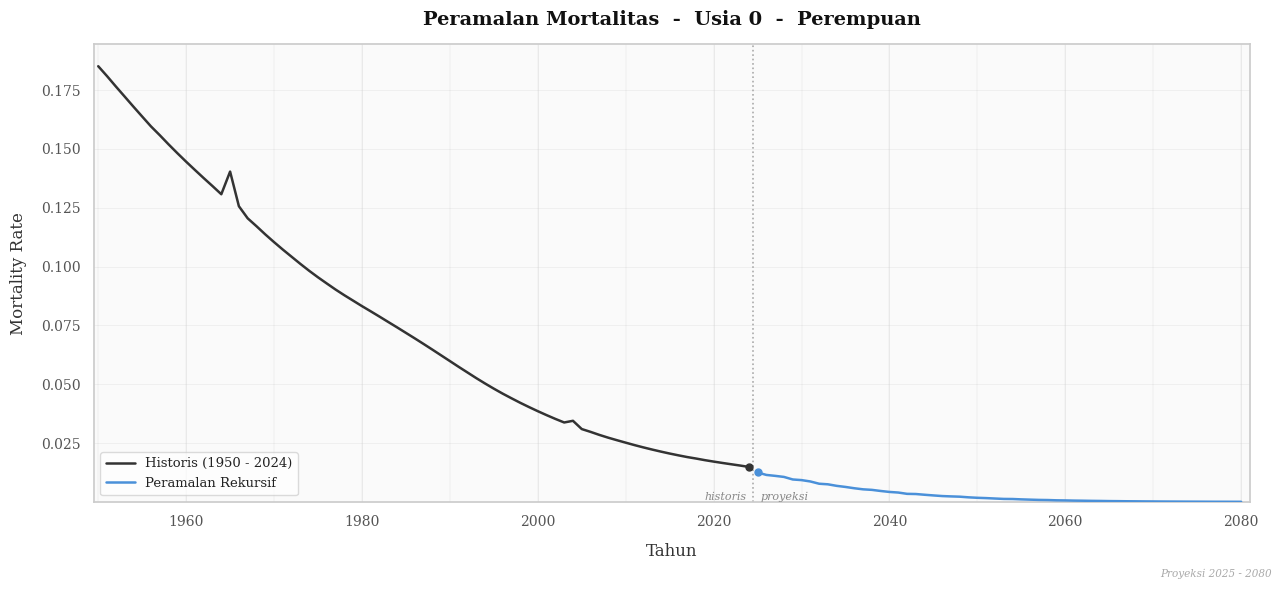

In [162]:
plot_mortality_single(
    age=0,
    gender=0,
    save_path=DOT_ENV.plots_dir / "peramalan_rekursif_perempuan_usia_0.png"
)

Plot disimpan ke: plots\peramalan_rekursif_perempuan_usia_50.png


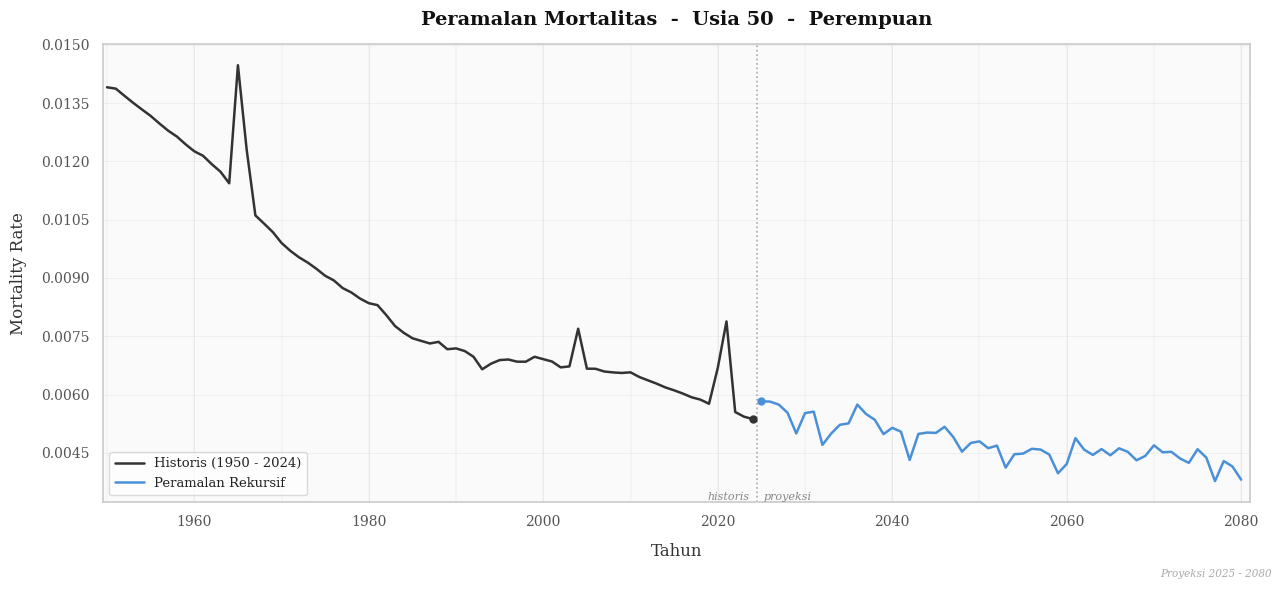

In [163]:
plot_mortality_single(
    age=50,
    gender=0,
    save_path=DOT_ENV.plots_dir / "peramalan_rekursif_perempuan_usia_50.png"
)

Plot disimpan ke: plots\peramalan_rekursif_perempuan_usia_100.png


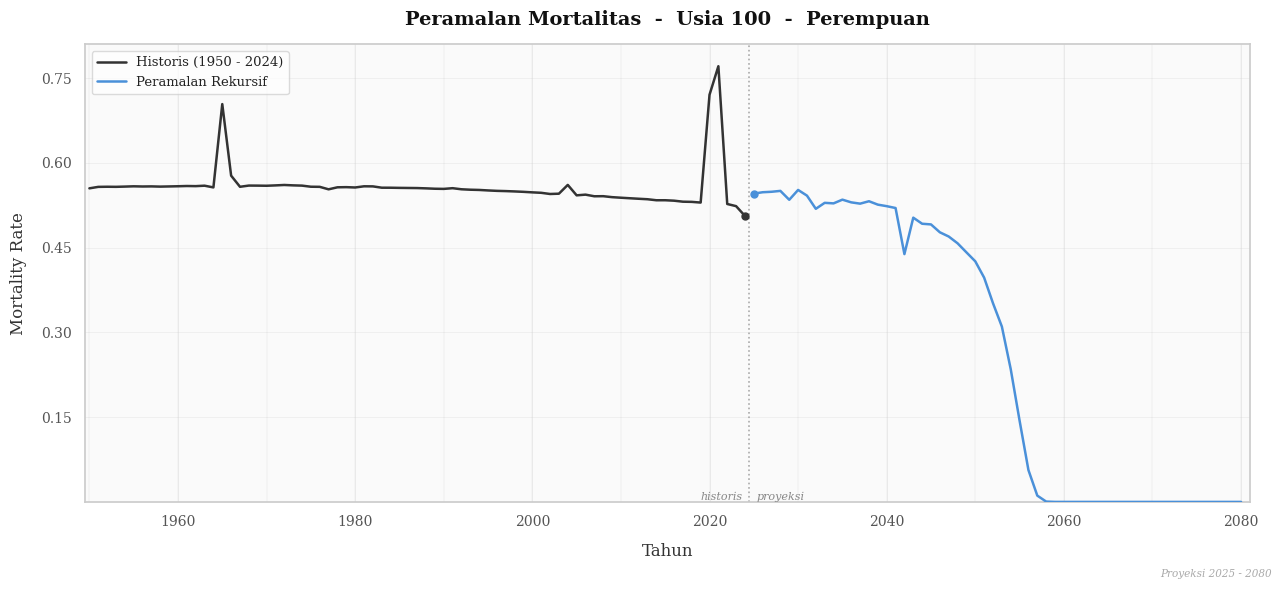

In [164]:
plot_mortality_single(
    age=100,
    gender=0,
    save_path=DOT_ENV.plots_dir / "peramalan_rekursif_perempuan_usia_100.png"
)

Plot disimpan ke: plots\peramalan_rekursif_laki-laki_usia_0.png


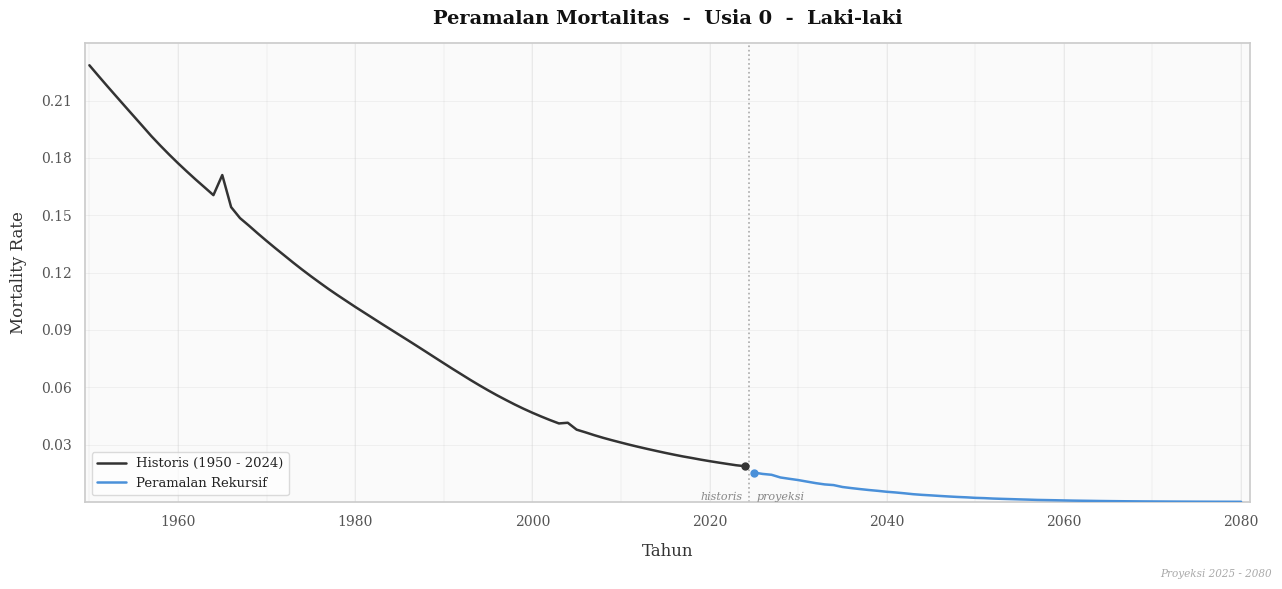

In [165]:
plot_mortality_single(
    age=0,
    gender=1,
    save_path=DOT_ENV.plots_dir / "peramalan_rekursif_laki-laki_usia_0.png"
)

Plot disimpan ke: plots\peramalan_rekursif_laki-laki_usia_50.png


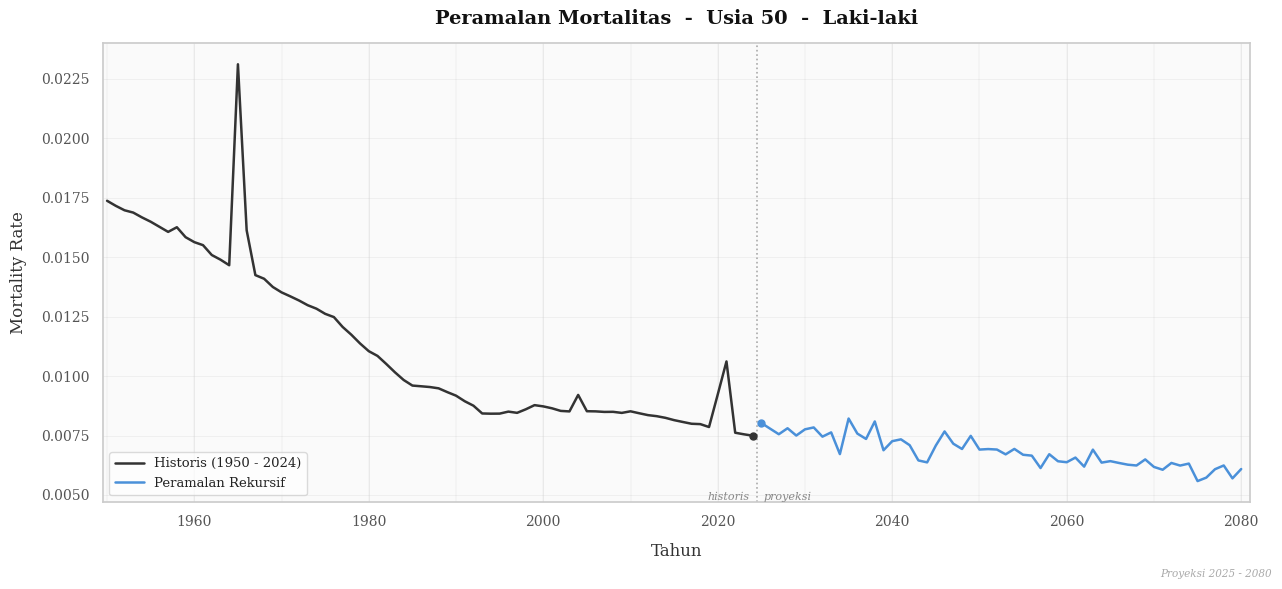

In [166]:
plot_mortality_single(
    age=50,
    gender=1,
    save_path=DOT_ENV.plots_dir / "peramalan_rekursif_laki-laki_usia_50.png"
)

Plot disimpan ke: plots\peramalan_rekursif_laki-laki_usia_100.png


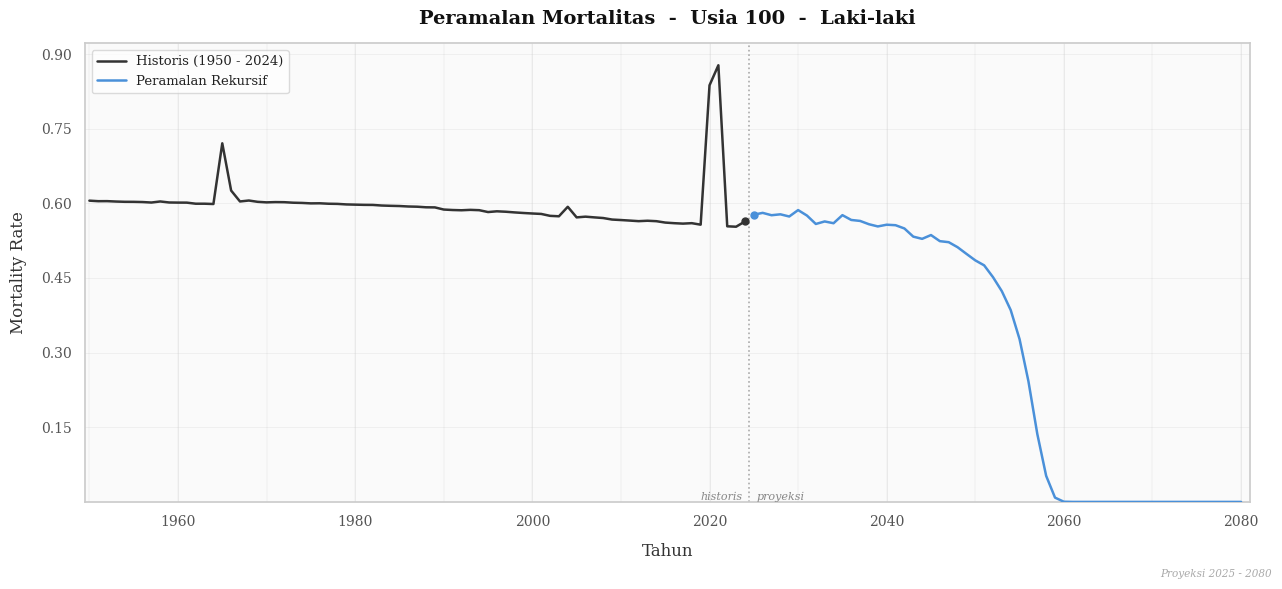

In [167]:
plot_mortality_single(
    age=100,
    gender=1,
    save_path=DOT_ENV.plots_dir / "peramalan_rekursif_laki-laki_usia_100.png"
)

## Deterministik (TMI IV)

In [168]:
tmi4_df = pd.read_csv("./data/tabel_mortalitas_indonesia_iv.csv", sep=";", decimal=",")
tmi4_df.tail()

,usia,laki-laki,perempuan
96,96,0.25715,0.19155
97,97,0.27419,0.20596
98,98,0.29249,0.22227
99,99,0.31215,0.23736
100,100,0.33331,0.25810


### Laki-laki

In [169]:
male_1qx_tmi4 = torch.from_numpy(tmi4_df.loc[:, "laki-laki"].to_numpy(copy=True, dtype=np.float32).reshape(1, -1)).to(
    DEVICE
)
male_1px_tmi4 = 1.0 - male_1qx_tmi4

In [170]:
male_1px_tmi4

tensor([[0.9948, 0.9995, 0.9996, 0.9997, 0.9997, 0.9997, 0.9998, 0.9998, 0.9998,
         0.9998, 0.9998, 0.9998, 0.9998, 0.9998, 0.9998, 0.9997, 0.9997, 0.9996,
         0.9996, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995,
         0.9994, 0.9994, 0.9993, 0.9992, 0.9992, 0.9991, 0.9991, 0.9990, 0.9989,
         0.9988, 0.9987, 0.9986, 0.9984, 0.9983, 0.9981, 0.9978, 0.9976, 0.9973,
         0.9970, 0.9966, 0.9962, 0.9958, 0.9954, 0.9949, 0.9944, 0.9939, 0.9933,
         0.9927, 0.9921, 0.9915, 0.9910, 0.9906, 0.9903, 0.9900, 0.9898, 0.9895,
         0.9893, 0.9890, 0.9885, 0.9880, 0.9874, 0.9867, 0.9859, 0.9851, 0.9843,
         0.9833, 0.9822, 0.9811, 0.9797, 0.9763, 0.9726, 0.9687, 0.9631, 0.9548,
         0.9447, 0.9327, 0.9177, 0.9052, 0.8953, 0.8847, 0.8730, 0.8605, 0.8473,
         0.8334, 0.8201, 0.8061, 0.7913, 0.7755, 0.7587, 0.7429, 0.7258, 0.7075,
         0.6878, 0.6667]], device='cuda:0')

In [171]:
from ta_module.actuarial import compute_kpx_table_from_xstart_static

male_kpx_45_100_tmi4 = compute_kpx_table_from_xstart_static(
    p=male_1px_tmi4,
    x_start=45,
    max_k=56,
)

### Perempuan

In [172]:
female_1qx_tmi4 = torch.from_numpy(tmi4_df.loc[:, "perempuan"].to_numpy(copy=True, dtype=np.float32).reshape(1, -1)).to(
    DEVICE
)
female_1px_tmi4 = 1.0 - female_1qx_tmi4

In [173]:
female_kpx_45_100_tmi4 = compute_kpx_table_from_xstart_static(
    p=female_1px_tmi4,
    x_start=45,
    max_k=56,
)

# Perhitungan longevity risk

## Persiapan

In [174]:
populasi_df.head()

,gender,age,value
0,Male,45,2013106
1,Male,46,1965078
2,Male,47,1918556
3,Male,48,1880902
4,Male,49,1836713


In [175]:
populasi_joint_dist_df = (
    populasi_df
    .groupby(['gender', 'age'])["value"]
    .sum()
    .div(populasi_df["value"].sum())
    .rename('prob')
    .reset_index()
)

populasi_joint_dist_df['cdf'] = (
    populasi_joint_dist_df
    .groupby('gender')['prob']
    .cumsum()
)

In [176]:
populasi_joint_dist_df.head()

,gender,age,prob,cdf
0,Female,45,0.036598,0.036598
1,Female,46,0.035845,0.072443
2,Female,47,0.035132,0.107575
3,Female,48,0.034585,0.142160
4,Female,49,0.033901,0.176061


In [177]:
male_age_populasi_prob = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Male"]["prob"]
male_age_populasi_prob = torch.from_numpy(male_age_populasi_prob.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

female_age_populasi_prob = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Female"]["prob"]
female_age_populasi_prob = torch.from_numpy(female_age_populasi_prob.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

In [178]:
male_age_populasi_cdf = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Male"]["cdf"]
male_age_populasi_cdf = torch.from_numpy(male_age_populasi_cdf.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

female_age_populasi_cdf = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Female"]["cdf"]
female_age_populasi_cdf = torch.from_numpy(female_age_populasi_cdf.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

In [179]:
gender_populasi_dist_df = (
    populasi_df.groupby('gender')['value']
    .sum()
    .div(populasi_df['value'].sum())
    .rename('prob')
    .reset_index()
)

gender_populasi_dist_df['cdf'] = gender_populasi_dist_df['prob'].cumsum()

In [180]:
male_populasi_prob = torch.tensor(
    gender_populasi_dist_df[gender_populasi_dist_df["gender"] == "Male"]["prob"].iloc[0], device=DEVICE,
    dtype=torch.float32
)

female_populasi_prob = torch.tensor(
    gender_populasi_dist_df[gender_populasi_dist_df["gender"] == "Female"]["prob"].iloc[0], device=DEVICE,
    dtype=torch.float32
)

gender_populasi_cdf = torch.from_numpy(gender_populasi_dist_df["cdf"].to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

In [181]:
age_populasi_given_male_cdf = male_age_populasi_cdf / male_populasi_prob
age_populasi_given_female_cdf = female_age_populasi_cdf / female_populasi_prob

In [182]:
bi_rate_df.head()

,date,bi_rate
0,2024-12-18,0.0600
1,2024-11-20,0.0600
2,2024-10-16,0.0600
3,2024-09-18,0.0600
4,2024-08-21,0.0625


In [183]:
suku_bunga_efektif_tahunan = torch.tensor(bi_rate_df["bi_rate"].mean(), device=DEVICE, dtype=torch.float32)
suku_bunga_efektif_tahunan

tensor(0.0474, device='cuda:0')

In [184]:
suku_bunga_nominal_bulanan = 12.0 * ((1.0 + suku_bunga_efektif_tahunan).pow(1.0 / 12.0) - 1.0)
suku_bunga_nominal_bulanan

tensor(0.0464, device='cuda:0')

In [185]:
from torch.distributions import LogNormal

premi_lognormal_rv = LogNormal(loc=5.926, scale=0.605)

In [186]:
start_age = 45
end_age = 60
m = 12

from ta_module.actuarial import compute_m_annuity_epv, compute_m_annuity_var, compute_m_annuity_epv2
from torch import Tensor


def wrapper_compute_m_annuity_epv(
    kpx: Tensor,
    gender_age_prob: Tensor
) -> Tensor:
    return compute_m_annuity_epv(
        start_age=start_age,
        end_age=end_age,
        m=m,
        i=suku_bunga_efektif_tahunan,
        kpx=kpx,
        gender_age_prob=gender_age_prob,
    )


def wrapper_compute_m_annuity_var(
    kpx: Tensor,
    gender_age_prob: Tensor
) -> Tensor:
    return compute_m_annuity_var(
        start_age=start_age,
        end_age=end_age,
        m=m,
        i=suku_bunga_efektif_tahunan,
        kpx=kpx,
        gender_age_prob=gender_age_prob,
    )


def wrapper_compute_m_annuity_epv2(
    kpx: Tensor,
    gender_age_prob: Tensor
) -> Tensor:
    return compute_m_annuity_epv2(
        start_age=start_age,
        end_age=end_age,
        m=m,
        i=suku_bunga_efektif_tahunan,
        kpx=kpx,
        gender_age_prob=gender_age_prob,
    )

In [187]:
N = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000]

## Kerangka deterministik

### EPV

In [188]:
male_tmi4_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_tmi4,
    gender_age_prob=male_age_populasi_prob
)

male_tmi4_epv

tensor(90.9883, device='cuda:0')

In [189]:
female_tmi4_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_tmi4,
    gender_age_prob=female_age_populasi_prob
)

female_tmi4_epv

tensor(95.1843, device='cuda:0')

In [190]:
tmi4_epv = male_tmi4_epv + female_tmi4_epv
tmi4_epv

tensor(186.1726, device='cuda:0')

In [191]:
expected_benefit_tmi4 = (premi_lognormal_rv.mean + 50) / tmi4_epv
print(f"Ekspektasi manfaat per bulan anuitas jiwa deterministik (dalam juta rupiah) = {expected_benefit_tmi4:.6f}")

Ekspektasi manfaat per bulan anuitas jiwa deterministik (dalam juta rupiah) = 2.685112


In [192]:
portfolio_tmi4_epv = {}
for n in N:
    portfolio_tmi4_epv[n] = n * expected_benefit_tmi4 * tmi4_epv
    print(f"N = {n}\nEPV portfolio deterministik = {portfolio_tmi4_epv[n]:.6f}\n")

N = 1
EPV portfolio deterministik = 499.894287

N = 10
EPV portfolio deterministik = 4998.943359

N = 100
EPV portfolio deterministik = 49989.425781

N = 1000
EPV portfolio deterministik = 499894.312500

N = 10000
EPV portfolio deterministik = 4998943.000000

N = 100000
EPV portfolio deterministik = 49989432.000000

N = 1000000
EPV portfolio deterministik = 499894304.000000



### Varians

In [193]:
male_tmi4_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_tmi4,
    gender_age_prob=male_age_populasi_prob
)

male_tmi4_var

tensor(2484.6086, device='cuda:0')

In [194]:
male_tmi4_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_tmi4,
    gender_age_prob=male_age_populasi_prob
)

male_tmi4_epv2

tensor(16659.9922, device='cuda:0')

In [195]:
female_tmi4_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_tmi4,
    gender_age_prob=female_age_populasi_prob
)

female_tmi4_var

tensor(2220.6826, device='cuda:0')

In [196]:

female_tmi4_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=female_kpx_45_100_tmi4,
    gender_age_prob=female_age_populasi_prob
)

female_tmi4_epv2

tensor(18058.8672, device='cuda:0')

In [197]:
tmi4_epv2 = male_tmi4_epv2 + female_tmi4_epv2
tmi4_var = male_tmi4_var + female_tmi4_var
tmi4_total_var = tmi4_var + tmi4_epv2 - tmi4_epv.pow(2)

In [198]:
portfolio_tmi4_var = {}

E_B = expected_benefit_tmi4
# VAR(B) = VAR(P / E(Y)) = VAR([P* + 50] / E(Y)) = 1 / E(Y)^2 * VAR(P*)
VAR_B = 1 / tmi4_epv.pow(2) * premi_lognormal_rv.variance
# VAR(B) = E(B^2) - E(B)^2 => E(B^2) = E(B)^2 + VAR(B)
E_B2 = E_B.pow(2) + VAR_B

E_Y = tmi4_epv
VAR_Y = tmi4_total_var
E_Y2 = E_Y.pow(2) + VAR_Y

for n in N:
    portfolio_tmi4_var[n] = n * (E_B2 * E_Y2 - (E_B * E_Y).pow(2))
    print(f"N = {n}\nVAR portfolio deterministik = {portfolio_tmi4_var[n]:.6f}\n")

N = 1
VAR portfolio deterministik = 136104.140625

N = 10
VAR portfolio deterministik = 1361041.375000

N = 100
VAR portfolio deterministik = 13610414.000000

N = 1000
VAR portfolio deterministik = 136104144.000000

N = 10000
VAR portfolio deterministik = 1361041408.000000

N = 100000
VAR portfolio deterministik = 13610414080.000000

N = 1000000
VAR portfolio deterministik = 136104140800.000000



### Koefisien variasi

In [199]:
portfolio_tmi4_koefisien_variasi = {}
for n in N:
    portfolio_tmi4_koefisien_variasi[n] = portfolio_tmi4_var[n].sqrt() / portfolio_tmi4_epv[n]
    print(f"N = {n}\nKoefisien variasi portfolio deterministik = {portfolio_tmi4_koefisien_variasi[n]:.6f}\n")

N = 1
Koefisien variasi portfolio deterministik = 0.738002

N = 10
Koefisien variasi portfolio deterministik = 0.233377

N = 100
Koefisien variasi portfolio deterministik = 0.073800

N = 1000
Koefisien variasi portfolio deterministik = 0.023338

N = 10000
Koefisien variasi portfolio deterministik = 0.007380

N = 100000
Koefisien variasi portfolio deterministik = 0.002334

N = 1000000
Koefisien variasi portfolio deterministik = 0.000738



In [200]:
portfolio_tmi4_epv.values()

dict_values([tensor(499.8943, device='cuda:0'), tensor(4998.9434, device='cuda:0'), tensor(49989.4258, device='cuda:0'), tensor(499894.3125, device='cuda:0'), tensor(4998943., device='cuda:0'), tensor(49989432., device='cuda:0'), tensor(4.9989e+08, device='cuda:0')])

In [201]:
tmi4_longevity_risk = {
    "epv"              : [v.item() for v in portfolio_tmi4_epv.values()],
    "var"              : [v.item() for v in portfolio_tmi4_var.values()],
    "koefisien_variasi": [v.item() for v in portfolio_tmi4_koefisien_variasi.values()]
}

pd.DataFrame(tmi4_longevity_risk, index=N).to_csv(DOT_ENV.results_dir / "tmi4_longevity_risk.csv", sep=";", decimal=",")

## Kerangka stokastik

### EPV

In [202]:
male_min_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_min,
    gender_age_prob=male_age_populasi_prob
)

male_min_epv

tensor(80.3114, device='cuda:0')

In [203]:
male_med_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_med,
    gender_age_prob=male_age_populasi_prob
)

male_med_epv

tensor(82.1263, device='cuda:0')

In [204]:
male_max_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_max,
    gender_age_prob=male_age_populasi_prob
)

male_max_epv

tensor(83.1278, device='cuda:0')

In [205]:
female_min_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_min,
    gender_age_prob=female_age_populasi_prob
)

female_min_epv

tensor(83.0046, device='cuda:0')

In [206]:
female_med_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_med,
    gender_age_prob=female_age_populasi_prob
)

female_med_epv

tensor(83.0544, device='cuda:0')

In [207]:
female_max_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_max,
    gender_age_prob=female_age_populasi_prob
)

female_max_epv

tensor(82.6881, device='cuda:0')

In [208]:
min_epv = male_min_epv + female_min_epv
med_epv = male_med_epv + female_med_epv
max_epv = male_max_epv + female_max_epv

In [209]:
r_min = 0.15
r_med = 0.70
r_max = 0.15

stokastik_epv = r_min * min_epv + r_med * med_epv + r_max * max_epv
print(f"EPV anuitas jiwa stokastik = {stokastik_epv:.6f}")

EPV anuitas jiwa stokastik = 164.996277


In [210]:
expected_benefit_min = (premi_lognormal_rv.mean + 50) / min_epv
expected_beneit_med = (premi_lognormal_rv.mean + 50) / med_epv
expected_beneit_max = (premi_lognormal_rv.mean + 50) / max_epv

expected_benefit_stokastik = (
        r_min * expected_benefit_min +
        r_med * expected_beneit_med +
        r_max * expected_beneit_max
)
print(f"Ekspektasi manfaat bulanan anuitas jiwa stokastik (dalam juta rupiah) = {expected_benefit_stokastik:.6f}")

Ekspektasi manfaat bulanan anuitas jiwa stokastik (dalam juta rupiah) = 3.029792


In [211]:
portfolio_stokastik_epv = {}
for n in N:
    portfolio_stokastik_epv[n] = n * expected_benefit_stokastik * stokastik_epv
    print(f"\nN = {n}\nEPV portfolio stokastik = {portfolio_stokastik_epv[n]:.6f}")


N = 1
EPV portfolio stokastik = 499.904449

N = 10
EPV portfolio stokastik = 4999.044434

N = 100
EPV portfolio stokastik = 49990.441406

N = 1000
EPV portfolio stokastik = 499904.437500

N = 10000
EPV portfolio stokastik = 4999044.500000

N = 100000
EPV portfolio stokastik = 49990444.000000

N = 1000000
EPV portfolio stokastik = 499904448.000000


### Varians

In [212]:
male_min_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_min,
    gender_age_prob=male_age_populasi_prob
)

male_med_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_med,
    gender_age_prob=male_age_populasi_prob
)

male_max_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_max,
    gender_age_prob=male_age_populasi_prob
)

In [213]:
female_min_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_min,
    gender_age_prob=female_age_populasi_prob
)

female_med_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_med,
    gender_age_prob=female_age_populasi_prob
)

female_max_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_max,
    gender_age_prob=female_age_populasi_prob
)

In [214]:
min_var = male_min_var + female_min_var
med_var = male_med_var + female_med_var
max_var = male_max_var + female_max_var

In [215]:
male_min_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_min,
    gender_age_prob=male_age_populasi_prob
)

male_med_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_med,
    gender_age_prob=male_age_populasi_prob
)

male_max_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_max,
    gender_age_prob=male_age_populasi_prob
)

In [216]:
female_min_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_min,
    gender_age_prob=female_age_populasi_prob
)

female_med_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=female_kpx_45_100_med,
    gender_age_prob=female_age_populasi_prob
)

female_max_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=female_kpx_45_100_max,
    gender_age_prob=female_age_populasi_prob
)

In [217]:
min_epv2 = male_min_epv2 + female_min_epv2
med_epv2 = male_med_epv2 + female_med_epv2
max_epv2 = male_max_epv2 + female_max_epv2

In [218]:
min_total_var = min_var + min_epv2 - min_epv.pow(2)
med_total_var = med_var + med_epv2 - med_epv.pow(2)
max_total_var = max_var + max_epv2 - max_epv.pow(2)

In [219]:
portfolio_stokastik_var = {}
portfolio_stokastik_E_VAR = {}
portfolio_stokastik_VAR_E = {}

N_bar = 0

E_B = expected_benefit_stokastik
VAR_B = 1 / stokastik_epv.pow(2) * premi_lognormal_rv.variance
E_B2 = VAR_B + E_B.pow(2)

E_Y_min = min_epv
E_Y_med = med_epv
E_Y_max = max_epv

E_Y2_min = min_total_var + min_epv.pow(2)
E_Y2_med = med_total_var + med_epv.pow(2)
E_Y2_max = max_total_var + max_epv.pow(2)

E_EB_EY_2 = (
        r_min * (E_B * E_Y_min).pow(2) +
        r_med * (E_B * E_Y_med).pow(2) +
        r_max * (E_B * E_Y_max).pow(2)
)

E_EB_EY = (
        r_min * (E_B * E_Y_min) +
        r_med * (E_B * E_Y_med) +
        r_max * (E_B * E_Y_max)
)

for n in N:
    E_VAR = (
            r_min * (E_B2 * E_Y2_min - (E_B * E_Y_min).pow(2)) +
            r_med * (E_B2 * E_Y2_med - (E_B * E_Y_med).pow(2)) +
            r_max * (E_B2 * E_Y2_max - (E_B * E_Y_max).pow(2))
    )
    VAR_E = (E_EB_EY_2 - E_EB_EY.pow(2))
    portfolio_stokastik_var[n] = n * E_VAR + (n ** 2) * VAR_E
    portfolio_stokastik_E_VAR[n] = n * E_VAR
    portfolio_stokastik_VAR_E[n] = (n ** 2) * VAR_E

    N_bar = E_VAR / VAR_E

    print(f"N = {n}")
    print(f"N_bar = {N_bar:.4f}")
    print(f"VAR portfolio stokastik = {portfolio_stokastik_var[n]:.6f}\n")

N = 1
N_bar = 33982.1602
VAR portfolio stokastik = 170977.781250

N = 10
N_bar = 33982.1602
VAR portfolio stokastik = 1710230.625000

N = 100
N_bar = 33982.1602
VAR portfolio stokastik = 17147588.000000

N = 1000
N_bar = 33982.1602
VAR portfolio stokastik = 176004000.000000

N = 10000
N_bar = 33982.1602
VAR portfolio stokastik = 2212852480.000000

N = 100000
N_bar = 33982.1602
VAR portfolio stokastik = 67409772544.000000

N = 1000000
N_bar = 33982.1602
VAR portfolio stokastik = 5202223038464.000000



### Koefisien variasi

In [220]:
portfolio_stokastik_koefisien_variasi = {}
for n in N:
    portfolio_stokastik_koefisien_variasi[n] = portfolio_stokastik_var[n].sqrt() / portfolio_stokastik_epv[n]
    print(f"N = {n}")
    print(f"N_bar = {N_bar:.4f}")
    print(f"Koefisien variasi portfolio stokastik = {portfolio_stokastik_koefisien_variasi[n]:.6f}\n")

N = 1
N_bar = 33982.1602
Koefisien variasi portfolio stokastik = 0.827147

N = 10
N_bar = 33982.1602
Koefisien variasi portfolio stokastik = 0.261602

N = 100
N_bar = 33982.1602
Koefisien variasi portfolio stokastik = 0.082835

N = 1000
N_bar = 33982.1602
Koefisien variasi portfolio stokastik = 0.026538

N = 10000
N_bar = 33982.1602
Koefisien variasi portfolio stokastik = 0.009410

N = 100000
N_bar = 33982.1602
Koefisien variasi portfolio stokastik = 0.005194

N = 1000000
N_bar = 33982.1602
Koefisien variasi portfolio stokastik = 0.004563



In [221]:
stokastik_longevity_risk = {
    "epv"              : [v.item() for v in portfolio_stokastik_epv.values()],
    "E_VAR"            : [v.item() for v in portfolio_stokastik_E_VAR.values()],
    "VAR_E"            : [v.item() for v in portfolio_stokastik_VAR_E.values()],
    "var"              : [v.item() for v in portfolio_stokastik_var.values()],
    "koefisien_variasi": [v.item() for v in portfolio_stokastik_koefisien_variasi.values()],
    "N_bar"            : N_bar.item()
}

pd.DataFrame(stokastik_longevity_risk, index=N).to_csv(
    DOT_ENV.results_dir / "stokastik_longevity_risk.csv", sep=";", decimal=","
)

# Perhitungan value at risk

In [263]:
# Reset seed state
seed_everything(seed=CONFIG.seed, workers=True)

Seed set to 42


42

In [264]:
from torch import Tensor

from ta_module.actuarial import create_fractional_m_cdf
from ta_module.utils import inverse_transform_sampling


def sampling_gender(
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    x = torch.arange(0, 2).expand(n_sims, n_samples, -1).contiguous().to(device)
    cdf = gender_populasi_cdf.expand(n_sims, n_samples, -1).contiguous()
    samples = inverse_transform_sampling(
        x=x,
        cdf=cdf,
    )

    return samples


def sampling_age(
    start_age: int,
    end_age: int,
    gender: Tensor,
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    x = torch.arange(start_age, end_age + 1).expand(n_sims, n_samples, -1).contiguous().to(device)
    cdf = torch.where(gender == 0, age_populasi_given_female_cdf, age_populasi_given_male_cdf).to(device)
    samples = inverse_transform_sampling(
        x=x,
        cdf=cdf,
    )

    return samples


def sampling_curtate_m_future_lifetime(
    fractional_m_cdf: Tensor,
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    x = torch.arange(0, fractional_m_cdf.shape[-1]).expand(n_sims, n_samples, -1).contiguous().to(device)
    cdf = fractional_m_cdf
    samples = inverse_transform_sampling(
        x=x,
        cdf=cdf,
    )

    return samples

## Kerangka deterministik

In [265]:
m = 12
def sampling_portfolio_value_deterministic(
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    gender_samples = sampling_gender(
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    age_samples = sampling_age(
        start_age=45,
        end_age=60,
        gender=gender_samples,
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    kpx = torch.stack([female_kpx_45_100_tmi4, male_kpx_45_100_tmi4])
    gender_idx = gender_samples.squeeze().long()
    age_idx = (age_samples - start_age).squeeze().long()
    fractional_m_cdf = create_fractional_m_cdf(kpx=kpx[gender_idx, age_idx], m=m).view(n_sims, n_samples, -1)

    premi_samples = 50 + premi_lognormal_rv.sample(sample_shape=(n_sims, n_samples, 1)).to(device)
    benefit_samples = premi_samples / tmi4_epv

    curtate_m_future_lifetime_samples = sampling_curtate_m_future_lifetime(
        fractional_m_cdf=fractional_m_cdf,
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    i_m = suku_bunga_nominal_bulanan
    v_m = 1 / (1 + i_m / m)
    d_m = (i_m / m) * v_m

    annuity_value = ((1 - v_m.pow(curtate_m_future_lifetime_samples + 1)) / d_m - 1).clamp(min=0)
    portfolio_value = (benefit_samples * annuity_value).sum(dim=1)

    return portfolio_value

In [266]:
n_simulations = 10_000
chunk_threshold = 100

portfolio_simulations_deterministik_file_path = DOT_ENV.results_dir / f"portfolio_simulations_deterministik.pt"
if not portfolio_simulations_deterministik_file_path.exists():
    print(55 * "=")
    print("Simulasi portolio value untuk kerangka deterministik:")
    print(55 * "=")
    portfolio_simulations_deterministik = torch.zeros(size=(len(N), n_simulations, 1), device=DEVICE)
    for i in range(len(N)):
        n = N[i]
        simulation_file_path = DOT_ENV.results_dir / f"portfolio_simulations_deterministik_n_{n}.pt"
        if not simulation_file_path.exists():
            print(f"Mulai simulasi portfolio N = {n}\n")
            chunk_size = n
            if n > chunk_threshold:
                chunk_size = chunk_threshold

            quotient, remainder = divmod(n, chunk_size)
            portfolio_simulation_value = torch.zeros(size=(n_simulations, 1), device=DEVICE)
            for j in range(quotient):
                print(f"Mulai simulasi untuk chunk ke {j + 1}/{quotient}...")
                portfolio_simulation_value += sampling_portfolio_value_deterministic(
                    n_sims=n_simulations,
                    n_samples=chunk_size,
                    device=DEVICE
                )

            if remainder > 0:
                print(f"Mulai simulasi untuk {remainder} sample sisanya...")
                portfolio_simulation_value += sampling_portfolio_value_deterministic(
                    n_sims=n_simulations,
                    n_samples=remainder,
                    device=DEVICE
                )

            print(f"\nMenyimpan ke {simulation_file_path}...")
            torch.save(obj=portfolio_simulation_value, f=simulation_file_path)
            portfolio_simulations_deterministik[i] = portfolio_simulation_value
        else:
            print(f"\nLoad {simulation_file_path}...")
            portfolio_simulations_deterministik[i] = torch.load(f=simulation_file_path, map_location=DEVICE)

        print(f"\nSimulasi portfolio N = {n} selesai")
        print(f"Hasil: {portfolio_simulations_deterministik[i][:5]}")
        print(55 * "=")

    print("\nSimulasi selesai!")
    print(f"Simpan hasil simulasi ke {portfolio_simulations_deterministik_file_path}")
    torch.save(obj=portfolio_simulations_deterministik, f=portfolio_simulations_deterministik_file_path)
    print("Selesai!")
else:
    print(f"Load {portfolio_simulations_deterministik_file_path}...")
    portfolio_simulations_deterministik = torch.load(
        f=portfolio_simulations_deterministik_file_path, map_location=DEVICE
    )

    print("Load selesai!")

Simulasi portolio value untuk kerangka deterministik:
Mulai simulasi portfolio N = 1

Mulai simulasi untuk chunk ke 1/1...

Menyimpan ke results\portfolio_simulations_deterministik_n_1.pt...

Simulasi portfolio N = 1 selesai
Hasil: tensor([[1099.8806],
        [ 668.5279],
        [ 314.2395],
        [ 545.4888],
        [ 167.3765]], device='cuda:0')
Mulai simulasi portfolio N = 10

Mulai simulasi untuk chunk ke 1/1...

Menyimpan ke results\portfolio_simulations_deterministik_n_10.pt...

Simulasi portfolio N = 10 selesai
Hasil: tensor([[5749.3623],
        [5214.2744],
        [4222.5474],
        [5677.1113],
        [4451.5083]], device='cuda:0')
Mulai simulasi portfolio N = 100

Mulai simulasi untuk chunk ke 1/1...

Menyimpan ke results\portfolio_simulations_deterministik_n_100.pt...

Simulasi portfolio N = 100 selesai
Hasil: tensor([[48630.0117],
        [48734.9648],
        [52170.1172],
        [53206.4492],
        [54572.6211]], device='cuda:0')
Mulai simulasi portfolio N = 

In [267]:
portfolio_simulations_deterministik[(portfolio_simulations_deterministik < 0)]

tensor([], device='cuda:0')

In [268]:
alphas = [0.5, 0.9, 0.95, 0.99]
var_deterministik = {}

for a in alphas:
    var_deterministik[a] = []
    for i in range(len(N)):
        n = N[i]
        portfolio_n = portfolio_simulations_deterministik[i].squeeze(-1)
        _, indices = torch.sort(portfolio_n, descending=False)
        var_deterministik[a].append(portfolio_n[indices[int(a * n_simulations)]].item())
print(var_deterministik)

{0.5: [425.3706970214844, 4914.40625, 50289.2265625, 503699.1875, 5038471.5, 50388944.0, 503891968.0], 0.9: [920.0840454101562, 6382.7705078125, 54689.9296875, 517581.3125, 5081979.0, 50522776.0, 504324896.0], 0.95: [1162.8426513671875, 6893.7890625, 55986.84375, 521418.5625, 5093671.5, 50561736.0, 504451648.0], 0.99: [1751.94580078125, 8047.86279296875, 58539.03125, 528701.25, 5118060.5, 50633948.0, 504676800.0]}


In [269]:
pd.DataFrame(var_deterministik, index=N).to_csv(DOT_ENV.results_dir / "var_deterministik.csv", decimal=",", sep=";")

## Kerangka stokastik

In [270]:
def sampling_mortality_trend(
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    x = torch.arange(0, 3).expand(n_sims, n_samples, -1).contiguous().to(device)
    cdf = torch.tensor([0.15, 0.85, 1.00], device=device).expand(n_sims, n_samples, -1).contiguous()
    samples = inverse_transform_sampling(
        x=x,
        cdf=cdf
    )

    return samples

In [271]:
def sampling_portfolio_value_stochastic(
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    gender_samples = sampling_gender(
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    age_samples = sampling_age(
        start_age=45,
        end_age=60,
        gender=gender_samples,
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    mortality_trend_samples = sampling_mortality_trend(
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    min_kpx = torch.stack([female_kpx_45_100_min, male_kpx_45_100_min]).to(DEVICE)
    med_kpx = torch.stack([female_kpx_45_100_med, male_kpx_45_100_med]).to(DEVICE)
    max_kpx = torch.stack([female_kpx_45_100_max, male_kpx_45_100_max]).to(DEVICE)
    kpx = torch.stack([min_kpx, med_kpx, max_kpx]).to(DEVICE)

    gender_idx = gender_samples.squeeze().long()
    age_idx = (age_samples - start_age).squeeze().long()
    mortality_trend_idx = mortality_trend_samples.squeeze().long()

    fractional_m_cdf = create_fractional_m_cdf(kpx=kpx[mortality_trend_idx, gender_idx, age_idx], m=m).view(
        n_sims, n_samples, -1
    )

    premi_samples = 50 + premi_lognormal_rv.sample(sample_shape=(n_sims, n_samples, 1)).to(device)
    benefit_samples = premi_samples / stokastik_epv

    curtate_m_future_lifetime_samples = sampling_curtate_m_future_lifetime(
        fractional_m_cdf=fractional_m_cdf,
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    i_m = suku_bunga_nominal_bulanan
    v_m = 1 / (1 + i_m / m)
    d_m = (i_m / m) * v_m

    annuity_value = ((1 - v_m.pow(curtate_m_future_lifetime_samples + 1)) / d_m - 1).clamp(min=0)
    portfolio_value = (benefit_samples * annuity_value).sum(dim=1)

    return portfolio_value

In [272]:
n_simulations = 10_000
chunk_threshold = 100

portfolio_simulations_stokastik_file_path = DOT_ENV.results_dir / f"portfolio_simulations_stokastik.pt"
if not portfolio_simulations_stokastik_file_path.exists():
    print(55 * "=")
    print("Simulasi portolio value untuk kerangka stokastik:")
    print(55 * "=")
    portfolio_simulations_stokastik = torch.zeros(size=(len(N), n_simulations, 1), device=DEVICE)
    for i in range(len(N)):
        n = N[i]
        simulation_file_path = DOT_ENV.results_dir / f"portfolio_simulations_stokastik_n_{n}.pt"
        if not simulation_file_path.exists():
            print(f"Mulai simulasi portfolio N = {n}\n")
            chunk_size = n
            if n > chunk_threshold:
                chunk_size = chunk_threshold

            quotient, remainder = divmod(n, chunk_size)
            portfolio_simulation_value = torch.zeros(size=(n_simulations, 1), device=DEVICE)
            for j in range(quotient):
                print(f"Mulai simulasi untuk chunk ke {j + 1}/{quotient}...")
                portfolio_simulation_value += sampling_portfolio_value_stochastic(
                    n_sims=n_simulations,
                    n_samples=chunk_size,
                    device=DEVICE
                )

            if remainder > 0:
                print(f"Mulai simulasi untuk {remainder} sample sisanya...")
                portfolio_simulation_value += sampling_portfolio_value_stochastic(
                    n_sims=n_simulations,
                    n_samples=remainder,
                    device=DEVICE
                )

            print(f"\nMenyimpan ke {simulation_file_path}...")
            torch.save(obj=portfolio_simulation_value, f=simulation_file_path)
            portfolio_simulations_stokastik[i] = portfolio_simulation_value
        else:
            print(f"\nLoad {simulation_file_path}...")
            portfolio_simulations_stokastik[i] = torch.load(f=simulation_file_path, map_location=DEVICE)

        print(f"\nSimulasi portfolio N = {n} selesai")
        print(f"Hasil: {portfolio_simulations_stokastik[i][:5]}")
        print(55 * "=")

    print("\nSimulasi selesai!")
    print(f"Simpan hasil simulasi ke {portfolio_simulations_stokastik_file_path}")
    torch.save(obj=portfolio_simulations_stokastik, f=portfolio_simulations_stokastik_file_path)
    print("Selesai!")
else:
    print(f"Load {portfolio_simulations_stokastik_file_path}...")
    portfolio_simulations_stokastik = torch.load(f=portfolio_simulations_stokastik_file_path, map_location=DEVICE)
    print("Load selesai!")

Simulasi portolio value untuk kerangka stokastik:
Mulai simulasi portfolio N = 1

Mulai simulasi untuk chunk ke 1/1...

Menyimpan ke results\portfolio_simulations_stokastik_n_1.pt...

Simulasi portfolio N = 1 selesai
Hasil: tensor([[590.7193],
        [194.2068],
        [414.1364],
        [229.9055],
        [226.1111]], device='cuda:0')
Mulai simulasi portfolio N = 10

Mulai simulasi untuk chunk ke 1/1...

Menyimpan ke results\portfolio_simulations_stokastik_n_10.pt...

Simulasi portfolio N = 10 selesai
Hasil: tensor([[4807.5176],
        [3857.6338],
        [4338.4160],
        [6759.8145],
        [5928.8047]], device='cuda:0')
Mulai simulasi portfolio N = 100

Mulai simulasi untuk chunk ke 1/1...

Menyimpan ke results\portfolio_simulations_stokastik_n_100.pt...

Simulasi portfolio N = 100 selesai
Hasil: tensor([[42466.6094],
        [47964.0938],
        [48145.9922],
        [43214.0078],
        [50123.6992]], device='cuda:0')
Mulai simulasi portfolio N = 1000

Mulai simulasi 

In [273]:
portfolio_simulations_stokastik[(portfolio_simulations_stokastik < 0)]

tensor([], device='cuda:0')

In [274]:
alphas = [0.5, 0.9, 0.95, 0.99]
var_stokastik = {}

for a in alphas:
    var_stokastik[a] = []
    for i in range(len(N)):
        n = N[i]
        portfolio_n = portfolio_simulations_stokastik[i].squeeze(-1)
        _, indices = torch.sort(portfolio_n, descending=False)
        var_stokastik[a].append(portfolio_n[indices[int(a * n_simulations)]].item())
print(var_stokastik)

{0.5: [398.6763610839844, 4648.314453125, 47606.5546875, 476854.75, 4768502.0, 47686232.0, 476859200.0], 0.9: [908.7454833984375, 6192.53125, 52179.609375, 491020.875, 4813219.0, 47826376.0, 477292640.0], 0.95: [1131.7596435546875, 6710.318359375, 53510.6171875, 495310.5625, 4826050.5, 47867196.0, 477414656.0], 0.99: [1758.5736083984375, 7920.75634765625, 56209.5625, 504109.8125, 4848982.0, 47940912.0, 477665184.0]}


In [275]:
pd.DataFrame(var_stokastik, index=N).to_csv(DOT_ENV.results_dir / "var_stokastik.csv", decimal=",", sep=";")